# 09 — Pre–post old/new viewing GLM

## Goal

This notebook tests whether images that were encountered during the island task show a stronger increase in image-evoked activity from pre-viewing to post-viewing than new control images.

During both pre-viewing and post-viewing, participants saw old and new images. Only old images were later encountered on the island. Therefore, an episodic-memory-related response should appear as a stronger post–pre increase for old images than for new images.

The main hypothesis is:

$$
(\text{post}_{old} - \text{pre}_{old})
>
(\text{post}_{new} - \text{pre}_{new})
$$

Equivalently, the main contrast is the pre–post by old–new interaction:

$$
C_{\text{old memory effect}}
=
(\beta_{\text{post,old}} - \beta_{\text{pre,old}})
-
(\beta_{\text{post,new}} - \beta_{\text{pre,new}})
$$

which expands to:

$$
C_{\text{old memory effect}}
=
\beta_{\text{post,old}}
-
\beta_{\text{pre,old}}
-
\beta_{\text{post,new}}
+
\beta_{\text{pre,new}}.
$$

The corresponding contrast weights are:

| Regressor | Weight |
|---|---:|
| `pre_old` | $$-1$$ |
| `pre_new` | $$+1$$ |
| `post_old` | $$+1$$ |
| `post_new` | $$-1$$ |

This contrast controls for image-level baseline visual salience because any pre-existing difference between old and new images is estimated already during pre-viewing.

In [1]:
# ============================================================
# 1. Imports and global settings
# ============================================================

from pathlib import Path
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from IPython.display import display, Markdown

from nilearn.glm.first_level import FirstLevelModel
from nilearn.glm.second_level import SecondLevelModel
from nilearn.interfaces.fmriprep import load_confounds
from nilearn.image import load_img, resample_to_img, mean_img, math_img
from nilearn.plotting import plot_design_matrix, plot_stat_map, view_img
from nilearn.reporting import get_clusters_table
from nilearn.glm import threshold_stats_img
from nilearn.datasets import load_mni152_template

from scipy import stats

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (10, 5)

print("Imports loaded.")

Imports loaded.


In [2]:
# ============================================================
# 2. Paths and analysis name
# ============================================================

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")

DATA_DIR = PROJECT_ROOT / "data"
BIDS_DIR = DATA_DIR / "bids_ackbar"
FMRIPREP_DIR = DATA_DIR / "fmriprep_output"

# Previous clean pre-post spatial-accuracy notebook output.
# We reuse its validated event backbone, but simplify the model to old/new only.
PREVIOUS_PRE_POST_ANALYSIS_NAME = "pre_post_spatial_accuracy_parametric"
PREVIOUS_PRE_POST_OUT_DIR = DATA_DIR / "processed" / "glm" / PREVIOUS_PRE_POST_ANALYSIS_NAME
PREVIOUS_PRE_POST_TABLE_DIR = PREVIOUS_PRE_POST_OUT_DIR / "tables"
PREVIOUS_PRE_POST_EVENTS_DIR = DATA_DIR / "preprocessed" / "relabeled_events_pre_post_spatial_accuracy"

# Current clean old/new analysis.
ANALYSIS_NAME = "pre_post_old_new_viewing_glm"

OUT_DIR = DATA_DIR / "processed" / "glm" / ANALYSIS_NAME
EVENTS_DIR = DATA_DIR / "preprocessed" / "relabeled_events_pre_post_old_new"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
QC_DIR = OUT_DIR / "qc"

for path in [
    OUT_DIR,
    EVENTS_DIR,
    FIG_DIR,
    TABLE_DIR,
    QC_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output directory:", OUT_DIR)
print("Events directory:", EVENTS_DIR)

Project root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
Output directory: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm
Events directory: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new


In [3]:
# ============================================================
# 3. Viewing sessions and fMRI settings
# ============================================================

PRE_SESSION = "ses-01"
POST_SESSION = "ses-05"

VIEWING_TASK = "viewing"
VIEWING_RUN = "01"

BOLD_SPACE = "MNI152NLin2009cAsym"

SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = "smoothed5mm"

FIRST_LEVEL_DIR = OUT_DIR / f"first_level_{SMOOTHING_LABEL}"
FIRST_LEVEL_MAPS_DIR = FIRST_LEVEL_DIR / "maps"
FIRST_LEVEL_DESIGN_DIR = FIRST_LEVEL_DIR / "design_matrices"
FIRST_LEVEL_FIG_DIR = FIRST_LEVEL_DIR / "figures"

SECOND_LEVEL_DIR = OUT_DIR / f"second_level_from_{SMOOTHING_LABEL}"
SECOND_LEVEL_MAPS_DIR = SECOND_LEVEL_DIR / "maps"
SECOND_LEVEL_FIG_DIR = SECOND_LEVEL_DIR / "figures"

for path in [
    FIRST_LEVEL_DIR,
    FIRST_LEVEL_MAPS_DIR,
    FIRST_LEVEL_DESIGN_DIR,
    FIRST_LEVEL_FIG_DIR,
    SECOND_LEVEL_DIR,
    SECOND_LEVEL_MAPS_DIR,
    SECOND_LEVEL_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("Pre session:", PRE_SESSION)
print("Post session:", POST_SESSION)
print("BOLD space:", BOLD_SPACE)
print("Smoothing:", SMOOTHING_FWHM, "mm")

Pre session: ses-01
Post session: ses-05
BOLD space: MNI152NLin2009cAsym
Smoothing: 5.0 mm


In [4]:
# ============================================================
# 4. Load validated pre-post event backbone and subject list
# ============================================================

# This file was created in notebook 08e after excluding sub-P37.
# It contains both actual-presentation rows and parametric-modulator rows.
# For the old/new GLM, we will keep only row_role == "actual_presentation".
pre_post_events_long_path = (
    PREVIOUS_PRE_POST_TABLE_DIR
    / "all_subjects_pre_post_spatial_accuracy_glm_events_long_excluding_sub-P37.csv"
)

# Fallback: depending on where the previous notebook saved it, it may be in EVENTS_DIR.
if not pre_post_events_long_path.exists():
    pre_post_events_long_path = (
        PREVIOUS_PRE_POST_EVENTS_DIR
        / "all_subjects_pre_post_spatial_accuracy_glm_events_long_excluding_sub-P37.csv"
    )

assert pre_post_events_long_path.exists(), f"Missing event backbone: {pre_post_events_long_path}"

events_long = pd.read_csv(pre_post_events_long_path)

print("Loaded:")
print(pre_post_events_long_path)
print("Shape:", events_long.shape)

display(events_long.head())

print("\nColumns:")
print(events_long.columns.tolist())

print("\nRow roles:")
display(events_long["row_role"].value_counts(dropna=False).reset_index())

print("\nTrial types:")
display(events_long["trial_type"].value_counts(dropna=False).reset_index())

Loaded:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/all_subjects_pre_post_spatial_accuracy_glm_events_long_excluding_sub-P37.csv
Shape: (32856, 10)


,onset,duration,image_file,phase,session,run,trial_type,modulation,row_role,subject
0,4.632,3.034,maya_3_e3_6_r_h_v1_old.jpg,post,ses-05,1,post_other_no_spatial_accuracy,1.000000,actual_presentation,sub-P10
1,10.815,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,post,ses-05,1,post_irrelevant_valid_main,1.000000,actual_presentation,sub-P10
2,10.815,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,post,ses-05,1,post_irrelevant_spatial_accuracy,-0.046390,parametric_modulator,sub-P10
3,17.065,3.017,pirate_6_e2_13_r_h_v1_old.jpg,post,ses-05,1,post_relevant_valid_main,1.000000,actual_presentation,sub-P10
4,17.065,3.017,pirate_6_e2_13_r_h_v1_old.jpg,post,ses-05,1,post_relevant_spatial_accuracy,0.264951,parametric_modulator,sub-P10



Columns:
['onset', 'duration', 'image_file', 'phase', 'session', 'run', 'trial_type', 'modulation', 'row_role', 'subject']

Row roles:


,row_role,count
0,actual_presentation,20736
1,parametric_modulator,12120



Trial types:


,trial_type,count
0,post_other_no_spatial_accuracy,4308
1,pre_other_no_spatial_accuracy,4308
2,pre_relevant_valid_main,3138
3,post_relevant_valid_main,3138
4,post_relevant_spatial_accuracy,3138
5,pre_relevant_spatial_accuracy,3138
6,post_irrelevant_valid_main,2922
7,post_irrelevant_spatial_accuracy,2922
8,pre_irrelevant_spatial_accuracy,2922
9,pre_irrelevant_valid_main,2922


In [5]:
# ============================================================
# 5. Define subject list and exclusions
# ============================================================

# The previous pre-post notebook already excluded sub-P37 because
# its pre/post image sets did not match cleanly.
EXCLUDED_SUBJECTS = ["sub-P37"]

subjects = sorted(events_long["subject"].unique().tolist())

assert "sub-P37" not in subjects, (
    "sub-P37 is still present in the event backbone. "
    "Make sure you loaded the excluding-sub-P37 file."
)

print("N subjects:", len(subjects))
print(subjects)

subject_table = pd.DataFrame({
    "subject": subjects,
    "included_pre_post_old_new": True,
})

subject_table_path = TABLE_DIR / "pre_post_old_new_subjects.csv"
subject_table.to_csv(subject_table_path, index=False)

display(subject_table)

print("Saved:", subject_table_path)

N subjects: 27
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']


,subject,included_pre_post_old_new
0,sub-P10,True
1,sub-P12,True
2,sub-P13,True
3,sub-P14,True
4,sub-P15,True
5,sub-P16,True
6,sub-P17,True
7,sub-P18,True
8,sub-P19,True
9,sub-P21,True


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_subjects.csv


In [6]:
# ============================================================
# 6. Helper functions for BOLD files and basic metadata
# ============================================================

def get_bold_file(subject, session, run=VIEWING_RUN, space=BOLD_SPACE):
    return (
        FMRIPREP_DIR
        / subject
        / session
        / "func"
        / f"{subject}_{session}_task-{VIEWING_TASK}_run-{run}_space-{space}_desc-preproc_bold.nii.gz"
    )


def infer_tr_from_bold(bold_path):
    img = nib.load(str(bold_path))
    return float(img.header.get_zooms()[3])


def load_basic_confounds_for_bold(bold_path):
    confounds, sample_mask = load_confounds(
        str(bold_path),
        strategy=["motion", "wm_csf", "high_pass"],
        motion="full",
        wm_csf="basic",
    )
    
    confounds = confounds.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    
    return confounds, sample_mask


def get_first_level_z_map_path(subject, contrast_name):
    return FIRST_LEVEL_MAPS_DIR / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_zmap.nii.gz"


def get_first_level_effect_map_path(subject, contrast_name):
    return FIRST_LEVEL_MAPS_DIR / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_effect.nii.gz"


def get_group_z_map_path(contrast_name):
    return SECOND_LEVEL_MAPS_DIR / f"group_pre_post_old_new_{contrast_name}_from_{SMOOTHING_LABEL}_zmap.nii.gz"


def get_group_effect_map_path(contrast_name):
    return SECOND_LEVEL_MAPS_DIR / f"group_pre_post_old_new_{contrast_name}_from_{SMOOTHING_LABEL}_effect.nii.gz"


file_qc_rows = []

for subject in subjects:
    pre_bold = get_bold_file(subject, PRE_SESSION)
    post_bold = get_bold_file(subject, POST_SESSION)
    
    file_qc_rows.append({
        "subject": subject,
        "pre_bold_exists": pre_bold.exists(),
        "post_bold_exists": post_bold.exists(),
        "pre_bold": str(pre_bold),
        "post_bold": str(post_bold),
    })

file_qc = pd.DataFrame(file_qc_rows)

display(file_qc)

assert file_qc["pre_bold_exists"].all(), "Some pre BOLD files are missing."
assert file_qc["post_bold_exists"].all(), "Some post BOLD files are missing."

file_qc_path = QC_DIR / "pre_post_old_new_bold_file_qc.csv"
file_qc.to_csv(file_qc_path, index=False)

print("Saved:", file_qc_path)

,subject,pre_bold_exists,post_bold_exists,pre_bold,post_bold
0,sub-P10,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P10/ses-01/func/sub-P10_ses-01_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P10/ses-05/func/sub-P10_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...
1,sub-P12,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P12/ses-01/func/sub-P12_ses-01_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P12/ses-05/func/sub-P12_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...
2,sub-P13,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P13/ses-01/func/sub-P13_ses-01_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P13/ses-05/func/sub-P13_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...
3,sub-P14,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P14/ses-01/func/sub-P14_ses-01_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P14/ses-05/func/sub-P14_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...
4,sub-P15,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P15/ses-01/func/sub-P15_ses-01_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P15/ses-05/func/sub-P15_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...
5,sub-P16,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P16/ses-01/func/sub-P16_ses-01_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P16/ses-05/func/sub-P16_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...
6,sub-P17,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P17/ses-01/func/sub-P17_ses-01_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P17/ses-05/func/sub-P17_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...
7,sub-P18,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P18/ses-01/func/sub-P18_ses-01_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P18/ses-05/func/sub-P18_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...
8,sub-P19,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P19/ses-01/func/sub-P19_ses-01_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P19/ses-05/func/sub-P19_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...
9,sub-P21,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P21/ses-01/func/sub-P21_ses-01_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P21/ses-05/func/sub-P21_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-pre...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/qc/pre_post_old_new_bold_file_qc.csv


In [7]:
# ============================================================
# 7. Build clean old/new GLM event files
# ============================================================

def classify_old_new_from_filename(image_file):
    """
    Classify images as old or new based on the filename.
    
    Expected examples:
    - maya_3_e3_6_r_h_v1_old.jpg -> old
    - viking_11_new.jpg -> new
    """
    image_file = str(image_file)
    
    if "_old." in image_file or image_file.endswith("_old.jpg") or image_file.endswith("_old.png"):
        return "old"
    
    if "_new." in image_file or image_file.endswith("_new.jpg") or image_file.endswith("_new.png"):
        return "new"
    
    return np.nan


def build_old_new_trial_type(row):
    """
    Create the four regressors of the old/new pre-post GLM:
    
    pre_old
    pre_new
    post_old
    post_new
    """
    return f"{row['phase']}_{row['old_new']}"


# ------------------------------------------------------------
# Keep only actual image presentations
# ------------------------------------------------------------

actual_events = events_long.loc[
    events_long["row_role"] == "actual_presentation"
].copy()

print("Original event rows:", len(events_long))
print("Actual-presentation rows:", len(actual_events))

# ------------------------------------------------------------
# Classify old/new from image filename
# ------------------------------------------------------------

actual_events["old_new"] = actual_events["image_file"].apply(classify_old_new_from_filename)

print("\nOld/new counts:")
display(
    actual_events["old_new"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "old_new", "old_new": "n_rows"})
)

missing_old_new = actual_events.loc[actual_events["old_new"].isna()].copy()

print("\nRows with missing old/new label:", len(missing_old_new))

if len(missing_old_new) > 0:
    display(missing_old_new[["subject", "phase", "image_file", "trial_type"]].head(20))

assert missing_old_new.empty, "Some image files could not be classified as old/new."

# ------------------------------------------------------------
# Create simple old/new trial type
# ------------------------------------------------------------

actual_events["trial_type_old_new"] = actual_events.apply(
    build_old_new_trial_type,
    axis=1,
)

# For this GLM, each actual image presentation has modulation 1.
actual_events["modulation_old_new"] = 1.0

print("\nOld/new GLM trial types:")
display(
    actual_events["trial_type_old_new"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "trial_type_old_new", "trial_type_old_new": "n_rows"})
)

expected_trial_types = {
    "pre_old",
    "pre_new",
    "post_old",
    "post_new",
}

observed_trial_types = set(actual_events["trial_type_old_new"].unique())

assert observed_trial_types == expected_trial_types, (
    f"Unexpected trial types. Observed: {observed_trial_types}"
)

# ------------------------------------------------------------
# Compact subject-level count QC
# ------------------------------------------------------------

old_new_count_qc = (
    actual_events
    .groupby(["subject", "phase", "old_new"])
    .size()
    .reset_index(name="n_presentations")
)

old_new_count_qc_wide = (
    old_new_count_qc
    .pivot_table(
        index="subject",
        columns=["phase", "old_new"],
        values="n_presentations",
        fill_value=0,
    )
)

old_new_count_qc_wide.columns = [
    f"{phase}_{old_new}_n"
    for phase, old_new in old_new_count_qc_wide.columns
]

old_new_count_qc_wide = old_new_count_qc_wide.reset_index()

display(old_new_count_qc_wide)

# Basic count sanity checks.
for col in ["pre_old_n", "pre_new_n", "post_old_n", "post_new_n"]:
    assert col in old_new_count_qc_wide.columns, f"Missing count column: {col}"

old_new_count_qc_wide["pre_post_old_count_match"] = (
    old_new_count_qc_wide["pre_old_n"] == old_new_count_qc_wide["post_old_n"]
)

old_new_count_qc_wide["pre_post_new_count_match"] = (
    old_new_count_qc_wide["pre_new_n"] == old_new_count_qc_wide["post_new_n"]
)

print("\nCount matching summary:")
display(
    old_new_count_qc_wide[
        [
            "subject",
            "pre_old_n",
            "post_old_n",
            "pre_new_n",
            "post_new_n",
            "pre_post_old_count_match",
            "pre_post_new_count_match",
        ]
    ]
)

assert old_new_count_qc_wide["pre_post_old_count_match"].all(), (
    "Some subjects have different pre/post old-image counts."
)

assert old_new_count_qc_wide["pre_post_new_count_match"].all(), (
    "Some subjects have different pre/post new-image counts."
)

# ------------------------------------------------------------
# Image identity matching QC
# ------------------------------------------------------------

image_matching_rows = []

for subject, subject_df in actual_events.groupby("subject"):
    pre_old_images = set(
        subject_df.loc[
            (subject_df["phase"] == "pre") & (subject_df["old_new"] == "old"),
            "image_file",
        ]
    )
    post_old_images = set(
        subject_df.loc[
            (subject_df["phase"] == "post") & (subject_df["old_new"] == "old"),
            "image_file",
        ]
    )
    
    pre_new_images = set(
        subject_df.loc[
            (subject_df["phase"] == "pre") & (subject_df["old_new"] == "new"),
            "image_file",
        ]
    )
    post_new_images = set(
        subject_df.loc[
            (subject_df["phase"] == "post") & (subject_df["old_new"] == "new"),
            "image_file",
        ]
    )
    
    image_matching_rows.append({
        "subject": subject,
        "n_pre_old_unique": len(pre_old_images),
        "n_post_old_unique": len(post_old_images),
        "n_pre_new_unique": len(pre_new_images),
        "n_post_new_unique": len(post_new_images),
        "same_old_image_set_pre_post": pre_old_images == post_old_images,
        "same_new_image_set_pre_post": pre_new_images == post_new_images,
        "n_old_pre_only": len(pre_old_images - post_old_images),
        "n_old_post_only": len(post_old_images - pre_old_images),
        "n_new_pre_only": len(pre_new_images - post_new_images),
        "n_new_post_only": len(post_new_images - pre_new_images),
    })

image_matching_qc = pd.DataFrame(image_matching_rows)

print("\nImage identity matching QC:")
display(image_matching_qc)

assert image_matching_qc["same_old_image_set_pre_post"].all(), (
    "Some subjects have mismatched old-image sets between pre and post."
)

assert image_matching_qc["same_new_image_set_pre_post"].all(), (
    "Some subjects have mismatched new-image sets between pre and post."
)

# ------------------------------------------------------------
# Save one clean GLM events file per subject
# ------------------------------------------------------------

subject_event_qc_rows = []

for subject, subject_df in actual_events.groupby("subject"):
    subject_df = subject_df.copy()
    
    glm_events = subject_df[
        [
            "onset",
            "duration",
            "trial_type_old_new",
            "modulation_old_new",
            "image_file",
            "phase",
            "session",
            "run",
            "old_new",
            "subject",
        ]
    ].copy()
    
    glm_events = glm_events.rename(
        columns={
            "trial_type_old_new": "trial_type",
            "modulation_old_new": "modulation",
        }
    )
    
    glm_events = glm_events.sort_values(["phase", "onset", "trial_type"]).reset_index(drop=True)
    
    out_path = EVENTS_DIR / f"{subject}_task-{VIEWING_TASK}_pre_post_old_new_events.tsv"
    glm_events.to_csv(out_path, sep="\t", index=False)
    
    subject_event_qc_rows.append({
        "subject": subject,
        "n_rows": len(glm_events),
        "n_pre_rows": int((glm_events["phase"] == "pre").sum()),
        "n_post_rows": int((glm_events["phase"] == "post").sum()),
        "n_pre_old": int((glm_events["trial_type"] == "pre_old").sum()),
        "n_pre_new": int((glm_events["trial_type"] == "pre_new").sum()),
        "n_post_old": int((glm_events["trial_type"] == "post_old").sum()),
        "n_post_new": int((glm_events["trial_type"] == "post_new").sum()),
        "events_path": str(out_path),
    })

old_new_event_qc = pd.DataFrame(subject_event_qc_rows)

print("\nSaved subject-level old/new GLM event files:")
display(old_new_event_qc)

# ------------------------------------------------------------
# Save QC tables
# ------------------------------------------------------------

actual_events_path = TABLE_DIR / "all_subjects_pre_post_old_new_actual_events.csv"
count_qc_path = QC_DIR / "pre_post_old_new_count_qc.csv"
image_matching_qc_path = QC_DIR / "pre_post_old_new_image_matching_qc.csv"
event_qc_path = QC_DIR / "pre_post_old_new_event_file_qc.csv"

actual_events.to_csv(actual_events_path, index=False)
old_new_count_qc_wide.to_csv(count_qc_path, index=False)
image_matching_qc.to_csv(image_matching_qc_path, index=False)
old_new_event_qc.to_csv(event_qc_path, index=False)

print("\nSaved:")
print(actual_events_path)
print(count_qc_path)
print(image_matching_qc_path)
print(event_qc_path)

Original event rows: 32856
Actual-presentation rows: 20736

Old/new counts:


,n_rows,count
0,old,15552
1,new,5184



Rows with missing old/new label: 0

Old/new GLM trial types:


,n_rows,count
0,post_old,7776
1,pre_old,7776
2,post_new,2592
3,pre_new,2592


,subject,post_new_n,post_old_n,pre_new_n,pre_old_n
0,sub-P10,96.0,288.0,96.0,288.0
1,sub-P12,96.0,288.0,96.0,288.0
2,sub-P13,96.0,288.0,96.0,288.0
3,sub-P14,96.0,288.0,96.0,288.0
4,sub-P15,96.0,288.0,96.0,288.0
5,sub-P16,96.0,288.0,96.0,288.0
6,sub-P17,96.0,288.0,96.0,288.0
7,sub-P18,96.0,288.0,96.0,288.0
8,sub-P19,96.0,288.0,96.0,288.0
9,sub-P21,96.0,288.0,96.0,288.0



Count matching summary:


,subject,pre_old_n,post_old_n,pre_new_n,post_new_n,pre_post_old_count_match,pre_post_new_count_match
0,sub-P10,288.0,288.0,96.0,96.0,True,True
1,sub-P12,288.0,288.0,96.0,96.0,True,True
2,sub-P13,288.0,288.0,96.0,96.0,True,True
3,sub-P14,288.0,288.0,96.0,96.0,True,True
4,sub-P15,288.0,288.0,96.0,96.0,True,True
5,sub-P16,288.0,288.0,96.0,96.0,True,True
6,sub-P17,288.0,288.0,96.0,96.0,True,True
7,sub-P18,288.0,288.0,96.0,96.0,True,True
8,sub-P19,288.0,288.0,96.0,96.0,True,True
9,sub-P21,288.0,288.0,96.0,96.0,True,True



Image identity matching QC:


,subject,n_pre_old_unique,n_post_old_unique,n_pre_new_unique,n_post_new_unique,same_old_image_set_pre_post,same_new_image_set_pre_post,n_old_pre_only,n_old_post_only,n_new_pre_only,n_new_post_only
0,sub-P10,48,48,16,16,True,True,0,0,0,0
1,sub-P12,48,48,16,16,True,True,0,0,0,0
2,sub-P13,48,48,16,16,True,True,0,0,0,0
3,sub-P14,48,48,16,16,True,True,0,0,0,0
4,sub-P15,48,48,16,16,True,True,0,0,0,0
5,sub-P16,48,48,16,16,True,True,0,0,0,0
6,sub-P17,48,48,16,16,True,True,0,0,0,0
7,sub-P18,48,48,16,16,True,True,0,0,0,0
8,sub-P19,48,48,16,16,True,True,0,0,0,0
9,sub-P21,48,48,16,16,True,True,0,0,0,0



Saved subject-level old/new GLM event files:


,subject,n_rows,n_pre_rows,n_post_rows,n_pre_old,n_pre_new,n_post_old,n_post_new,events_path
0,sub-P10,768,384,384,288,96,288,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new/sub-P10_task-viewing_pre_post_old_new_events.tsv
1,sub-P12,768,384,384,288,96,288,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new/sub-P12_task-viewing_pre_post_old_new_events.tsv
2,sub-P13,768,384,384,288,96,288,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new/sub-P13_task-viewing_pre_post_old_new_events.tsv
3,sub-P14,768,384,384,288,96,288,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new/sub-P14_task-viewing_pre_post_old_new_events.tsv
4,sub-P15,768,384,384,288,96,288,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new/sub-P15_task-viewing_pre_post_old_new_events.tsv
5,sub-P16,768,384,384,288,96,288,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new/sub-P16_task-viewing_pre_post_old_new_events.tsv
6,sub-P17,768,384,384,288,96,288,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new/sub-P17_task-viewing_pre_post_old_new_events.tsv
7,sub-P18,768,384,384,288,96,288,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new/sub-P18_task-viewing_pre_post_old_new_events.tsv
8,sub-P19,768,384,384,288,96,288,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new/sub-P19_task-viewing_pre_post_old_new_events.tsv
9,sub-P21,768,384,384,288,96,288,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_old_new/sub-P21_task-viewing_pre_post_old_new_events.tsv



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/all_subjects_pre_post_old_new_actual_events.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/qc/pre_post_old_new_count_qc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/qc/pre_post_old_new_image_matching_qc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/qc/pre_post_old_new_event_file_qc.csv


In [8]:
# ============================================================
# 8. Explicit design matrix and contrast definitions
# ============================================================

# ------------------------------------------------------------
# Human-readable design definition
# ------------------------------------------------------------

DESIGN_DESCRIPTION = """
First-level GLM design
======================

Each subject is modeled with two runs:

Run 1: pre-viewing  (ses-01)
Run 2: post-viewing (ses-05)

Task regressors:

Run 1:
    pre_old
    pre_new

Run 2:
    post_old
    post_new

Nuisance regressors in each run:
    - motion parameters
    - motion derivatives
    - squared motion parameters
    - squared motion derivatives
    - white matter
    - CSF
    - high-pass cosine regressors
    - constant

Model equation, conceptually:

Y = β_pre_old  * X_pre_old
  + β_pre_new  * X_pre_new
  + β_post_old * X_post_old
  + β_post_new * X_post_new
  + nuisance regressors
  + ε
"""

print(DESIGN_DESCRIPTION)


# ------------------------------------------------------------
# Contrast definitions
# ------------------------------------------------------------
# Each contrast is written in terms of the four task regressors.
# Missing regressors in a run are expected:
# - pre regressors exist only in run 1
# - post regressors exist only in run 2

OLD_NEW_CONTRASTS = {
    # Main hypothesis:
    # (post_old - pre_old) - (post_new - pre_new)
    "old_gt_new_post_gt_pre": {
        "pre_old": -1.0,
        "pre_new": +1.0,
        "post_old": +1.0,
        "post_new": -1.0,
    },
    
    # Old images only: post > pre
    "old_post_gt_pre": {
        "pre_old": -1.0,
        "post_old": +1.0,
    },
    
    # New images only: post > pre
    "new_post_gt_pre": {
        "pre_new": -1.0,
        "post_new": +1.0,
    },
    
    # Post-viewing old > new
    "post_old_gt_new": {
        "post_old": +1.0,
        "post_new": -1.0,
    },
    
    # Pre-viewing old > new
    # This is a baseline sanity check.
    "pre_old_gt_new": {
        "pre_old": +1.0,
        "pre_new": -1.0,
    },
    
    # General post > pre response across old and new images.
    "all_post_gt_pre": {
        "pre_old": -0.5,
        "pre_new": -0.5,
        "post_old": +0.5,
        "post_new": +0.5,
    },
}


CONTRAST_PRIORITY = {
    "old_gt_new_post_gt_pre": "primary",
    "old_post_gt_pre": "secondary_old_only",
    "new_post_gt_pre": "control_new_only",
    "post_old_gt_new": "descriptive_post_only",
    "pre_old_gt_new": "baseline_pre_only",
    "all_post_gt_pre": "descriptive_general_post_pre",
}


CONTRAST_FORMULAS = {
    "old_gt_new_post_gt_pre": r"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",
    "old_post_gt_pre": r"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",
    "new_post_gt_pre": r"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",
    "post_old_gt_new": r"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",
    "pre_old_gt_new": r"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",
    "all_post_gt_pre": r"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",
}


CONTRAST_INTERPRETATION = {
    "old_gt_new_post_gt_pre": (
        "Main episodic-memory contrast. Tests whether old images show a stronger post-pre increase "
        "than new images."
    ),
    "old_post_gt_pre": (
        "Tests whether old images alone evoke stronger activity after island exposure than before."
    ),
    "new_post_gt_pre": (
        "Control contrast. Tests whether new images also show a post-pre increase."
    ),
    "post_old_gt_new": (
        "Post-only old-new difference. Descriptive because it does not control for pre-existing image differences."
    ),
    "pre_old_gt_new": (
        "Pre-only old-new baseline check. Ideally weak or absent."
    ),
    "all_post_gt_pre": (
        "General post-viewing versus pre-viewing response across all images."
    ),
}


# ------------------------------------------------------------
# Build contrast table for readability
# ------------------------------------------------------------

contrast_rows = []

for contrast_name, weights in OLD_NEW_CONTRASTS.items():
    row = {
        "contrast": contrast_name,
        "priority": CONTRAST_PRIORITY[contrast_name],
        "formula": CONTRAST_FORMULAS[contrast_name],
        "interpretation": CONTRAST_INTERPRETATION[contrast_name],
        "pre_old": weights.get("pre_old", 0.0),
        "pre_new": weights.get("pre_new", 0.0),
        "post_old": weights.get("post_old", 0.0),
        "post_new": weights.get("post_new", 0.0),
    }
    
    contrast_rows.append(row)

contrast_table = pd.DataFrame(contrast_rows)

contrast_table = contrast_table[
    [
        "contrast",
        "priority",
        "formula",
        "pre_old",
        "pre_new",
        "post_old",
        "post_new",
        "interpretation",
    ]
]

display(contrast_table)

contrast_table_path = TABLE_DIR / "pre_post_old_new_contrast_definitions.csv"
contrast_table.to_csv(contrast_table_path, index=False)

print("Saved:", contrast_table_path)


# ------------------------------------------------------------
# Also save a markdown-readable version of the model definition
# ------------------------------------------------------------

model_definition_markdown = r"""
# Pre-post old/new GLM design

Each subject is modeled with two runs:

- Run 1: pre-viewing, `ses-01`
- Run 2: post-viewing, `ses-05`

The four task regressors are:

$$
X_{\mathrm{pre,old}},\quad
X_{\mathrm{pre,new}},\quad
X_{\mathrm{post,old}},\quad
X_{\mathrm{post,new}}.
$$

The first-level model is:

$$
Y =
\beta_{\mathrm{pre,old}}X_{\mathrm{pre,old}}
+
\beta_{\mathrm{pre,new}}X_{\mathrm{pre,new}}
+
\beta_{\mathrm{post,old}}X_{\mathrm{post,old}}
+
\beta_{\mathrm{post,new}}X_{\mathrm{post,new}}
+
\mathrm{confounds}
+
\epsilon.
$$

The main contrast is:

$$
C_{\mathrm{old>new,\ post>pre}}
=
(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

Expanded:

$$
C_{\mathrm{old>new,\ post>pre}}
=
\beta_{\mathrm{post,old}}
-
\beta_{\mathrm{pre,old}}
-
\beta_{\mathrm{post,new}}
+
\beta_{\mathrm{pre,new}}.
$$

Contrast weights:

| Regressor | Weight |
|---|---:|
| `pre_old` | -1 |
| `pre_new` | +1 |
| `post_old` | +1 |
| `post_new` | -1 |
"""

model_definition_path = TABLE_DIR / "pre_post_old_new_model_definition.md"

with open(model_definition_path, "w") as f:
    f.write(model_definition_markdown)

print("Saved:", model_definition_path)


First-level GLM design

Each subject is modeled with two runs:

Run 1: pre-viewing  (ses-01)
Run 2: post-viewing (ses-05)

Task regressors:

Run 1:
    pre_old
    pre_new

Run 2:
    post_old
    post_new

Nuisance regressors in each run:
    - motion parameters
    - motion derivatives
    - squared motion parameters
    - squared motion derivatives
    - white matter
    - CSF
    - high-pass cosine regressors
    - constant

Model equation, conceptually:

Y = β_pre_old  * X_pre_old
  + β_pre_new  * X_pre_new
  + β_post_old * X_post_old
  + β_post_new * X_post_new
  + nuisance regressors
  + ε



,contrast,priority,formula,pre_old,pre_new,post_old,post_new,interpretation
0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",-1.0,1.0,1.0,-1.0,Main episodic-memory contrast. Tests whether old images show a stronger post-pre increase than new images.
1,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",-1.0,0.0,1.0,0.0,Tests whether old images alone evoke stronger activity after island exposure than before.
2,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",0.0,-1.0,0.0,1.0,Control contrast. Tests whether new images also show a post-pre increase.
3,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",0.0,0.0,1.0,-1.0,Post-only old-new difference. Descriptive because it does not control for pre-existing image differences.
4,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",1.0,-1.0,0.0,0.0,Pre-only old-new baseline check. Ideally weak or absent.
5,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",-0.5,-0.5,0.5,0.5,General post-viewing versus pre-viewing response across all images.


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_contrast_definitions.csv
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_model_definition.md


[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Design preview subject: sub-P15

Preview QC:


,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,pre_event_types,post_event_types,n_pre_confounds,n_post_confounds,pre_sample_mask_is_none,post_sample_mask_is_none,n_design_columns_run_1,n_design_columns_run_2
0,sub-P15,1.3,1986,1995,384,384,pre_new;pre_old,post_new;post_old,65,65,True,True,68,68



Pre events:


,onset,duration,trial_type,modulation
0,4.631,3.033,pre_old,1.0
1,11.214,3.016,pre_old,1.0
2,17.397,3.017,pre_old,1.0
3,24.047,3.017,pre_old,1.0
4,30.314,3.016,pre_old,1.0



Post events:


,onset,duration,trial_type,modulation
0,4.622,3.016,post_old,1.0
1,10.806,3.016,post_old,1.0
2,17.055,3.017,post_old,1.0
3,23.588,3.017,post_old,1.0
4,29.588,3.017,post_old,1.0



Pre event counts:


,trial_type,count
0,pre_old,288
1,pre_new,96



Post event counts:


,trial_type,count
0,post_old,288
1,post_new,96



Task-regressor presence in design matrices:


,subject,run,regressor,present_in_design
0,sub-P15,1,pre_old,True
1,sub-P15,1,pre_new,True
2,sub-P15,1,post_old,False
3,sub-P15,1,post_new,False
4,sub-P15,2,pre_old,False
5,sub-P15,2,pre_new,False
6,sub-P15,2,post_old,True
7,sub-P15,2,post_new,True



Design-matrix task regressors are exactly as expected.

Run 1 design matrix columns:
['pre_new', 'pre_old', 'cosine00', 'cosine01', 'cosine02', 'cosine03', 'cosine04', 'cosine05', 'cosine06', 'cosine07', 'cosine08', 'cosine09', 'cosine10', 'cosine11', 'cosine12', 'cosine13', 'cosine14', 'cosine15', 'cosine16', 'cosine17', 'cosine18', 'cosine19', 'cosine20', 'cosine21', 'cosine22', 'cosine23', 'cosine24', 'cosine25', 'cosine26', 'cosine27', 'cosine28', 'cosine29', 'cosine30', 'cosine31', 'cosine32', 'cosine33', 'cosine34', 'cosine35', 'cosine36', 'cosine37', 'cosine38', 'csf', 'rot_x', 'rot_x_derivative1', 'rot_x_derivative1_power2', 'rot_x_power2', 'rot_y', 'rot_y_derivative1', 'rot_y_derivative1_power2', 'rot_y_power2', 'rot_z', 'rot_z_derivative1', 'rot_z_derivative1_power2', 'rot_z_power2', 'trans_x', 'trans_x_derivative1', 'trans_x_derivative1_power2', 'trans_x_power2', 'trans_y', 'trans_y_derivative1', 'trans_y_derivative1_power2', 'trans_y_power2', 'trans_z', 'trans_z_derivative

/tmp/ipykernel_3020207/2979194889.py:247: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


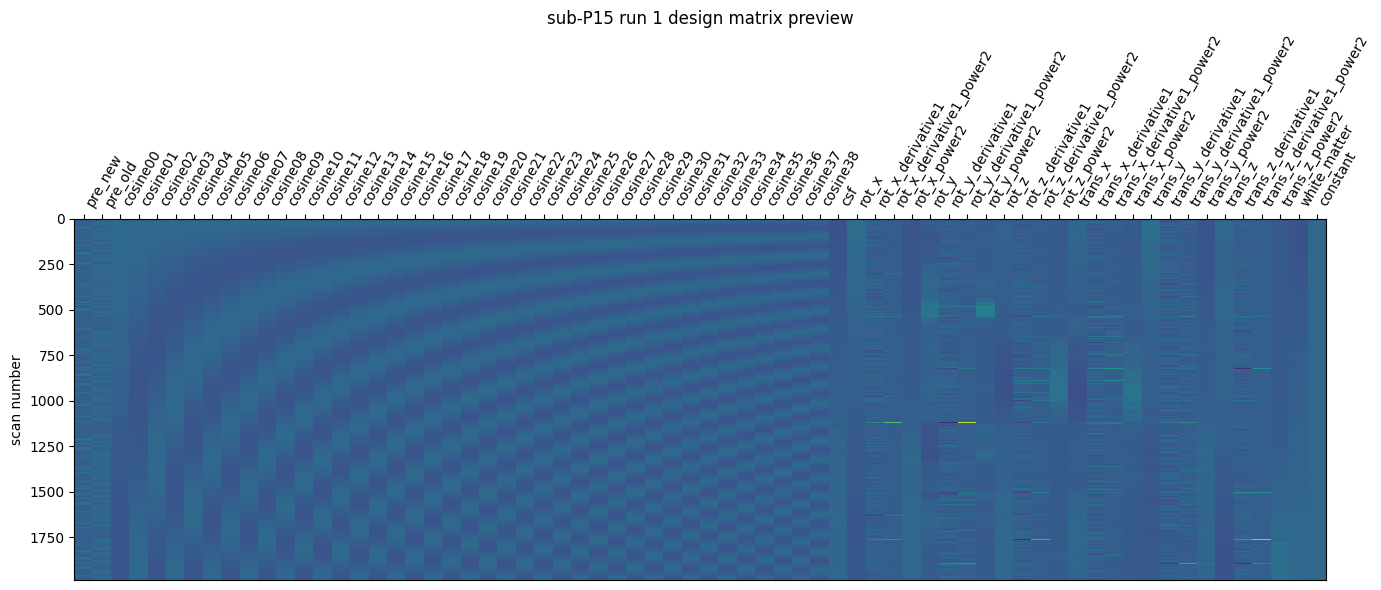

Saved figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/figures/sub-P15_run-1_design_matrix_preview_smoothed5mm.png

Run 2 design matrix columns:
['post_new', 'post_old', 'cosine00', 'cosine01', 'cosine02', 'cosine03', 'cosine04', 'cosine05', 'cosine06', 'cosine07', 'cosine08', 'cosine09', 'cosine10', 'cosine11', 'cosine12', 'cosine13', 'cosine14', 'cosine15', 'cosine16', 'cosine17', 'cosine18', 'cosine19', 'cosine20', 'cosine21', 'cosine22', 'cosine23', 'cosine24', 'cosine25', 'cosine26', 'cosine27', 'cosine28', 'cosine29', 'cosine30', 'cosine31', 'cosine32', 'cosine33', 'cosine34', 'cosine35', 'cosine36', 'cosine37', 'cosine38', 'csf', 'rot_x', 'rot_x_derivative1', 'rot_x_derivative1_power2', 'rot_x_power2', 'rot_y', 'rot_y_derivative1', 'rot_y_derivative1_power2', 'rot_y_power2', 'rot_z', 'rot_z_derivative1', 'rot_z_derivative1_power2', 'rot_z_power2', 'trans_x', 'trans_x_derivative1', 't

/tmp/ipykernel_3020207/2979194889.py:247: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


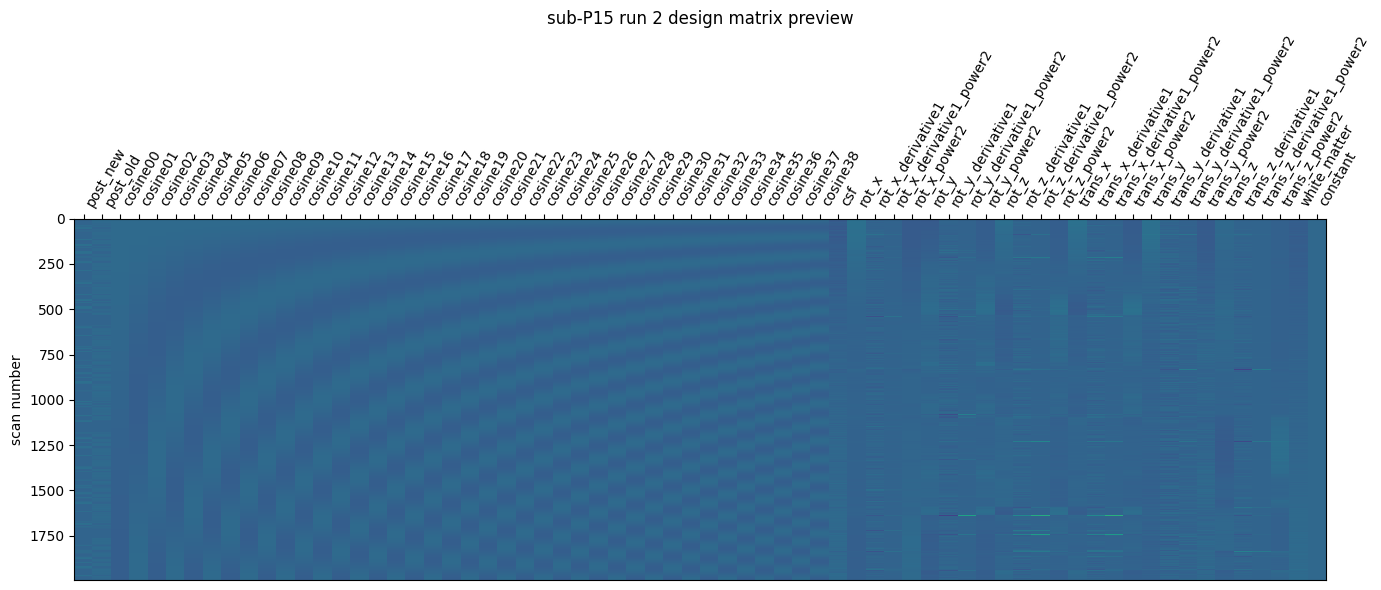

Saved figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/figures/sub-P15_run-2_design_matrix_preview_smoothed5mm.png


In [9]:
# ============================================================
# 9. Single-subject design-matrix preview
# ============================================================

def get_old_new_events_path(subject):
    return EVENTS_DIR / f"{subject}_task-{VIEWING_TASK}_pre_post_old_new_events.tsv"


def load_pre_post_old_new_events_for_glm(subject):
    """
    Load the simplified old/new event file for one subject and split it into:
    - pre-viewing events
    - post-viewing events
    
    Each returned dataframe contains only the columns needed by Nilearn:
    onset, duration, trial_type, modulation
    """
    events_path = get_old_new_events_path(subject)
    assert events_path.exists(), f"Missing old/new event file: {events_path}"
    
    events = pd.read_csv(events_path, sep="\t")
    
    required_columns = [
        "onset",
        "duration",
        "trial_type",
        "modulation",
        "phase",
        "image_file",
        "old_new",
    ]
    
    missing_columns = [col for col in required_columns if col not in events.columns]
    assert len(missing_columns) == 0, f"Missing columns in {events_path}: {missing_columns}"
    
    pre_events = events.loc[events["phase"] == "pre"].copy()
    post_events = events.loc[events["phase"] == "post"].copy()
    
    pre_events = pre_events[
        ["onset", "duration", "trial_type", "modulation"]
    ].sort_values("onset").reset_index(drop=True)
    
    post_events = post_events[
        ["onset", "duration", "trial_type", "modulation"]
    ].sort_values("onset").reset_index(drop=True)
    
    return pre_events, post_events


def prepare_sample_masks_for_two_runs(pre_bold, post_bold, pre_sample_mask, post_sample_mask):
    """
    Robust sample-mask handling for Nilearn.
    
    Nilearn accepts:
    - sample_masks=None when neither run has a sample mask
    - [array, array] when at least one run has a sample mask
    
    It does not accept [None, array].
    Therefore, if one run has None and the other has an array,
    we replace None with a full index vector for that run.
    """
    n_pre_scans = nib.load(str(pre_bold)).shape[-1]
    n_post_scans = nib.load(str(post_bold)).shape[-1]
    
    if pre_sample_mask is None and post_sample_mask is None:
        return None
    
    if pre_sample_mask is None:
        pre_sample_mask = np.arange(n_pre_scans, dtype=int)
    
    if post_sample_mask is None:
        post_sample_mask = np.arange(n_post_scans, dtype=int)
    
    return [pre_sample_mask, post_sample_mask]


def fit_design_preview_subject(subject):
    """
    Fit a first-level model for one subject only, mainly to inspect:
    - pre/post events
    - confounds
    - design matrices
    """
    pre_bold = get_bold_file(subject, PRE_SESSION)
    post_bold = get_bold_file(subject, POST_SESSION)
    
    assert pre_bold.exists(), f"Missing pre BOLD: {pre_bold}"
    assert post_bold.exists(), f"Missing post BOLD: {post_bold}"
    
    pre_events, post_events = load_pre_post_old_new_events_for_glm(subject)
    
    pre_confounds, pre_sample_mask = load_basic_confounds_for_bold(pre_bold)
    post_confounds, post_sample_mask = load_basic_confounds_for_bold(post_bold)
    
    tr_pre = infer_tr_from_bold(pre_bold)
    tr_post = infer_tr_from_bold(post_bold)
    
    assert np.isclose(tr_pre, tr_post), (
        f"{subject}: pre/post TR mismatch: {tr_pre}, {tr_post}"
    )
    
    sample_masks_for_fit = prepare_sample_masks_for_two_runs(
        pre_bold=pre_bold,
        post_bold=post_bold,
        pre_sample_mask=pre_sample_mask,
        post_sample_mask=post_sample_mask,
    )
    
    model = FirstLevelModel(
        t_r=tr_pre,
        hrf_model="spm",
        drift_model=None,  # high-pass regressors are already included from fMRIPrep
        noise_model="ar1",
        standardize=False,
        signal_scaling=0,
        smoothing_fwhm=SMOOTHING_FWHM,
        minimize_memory=False,
    )
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = model.fit(
            run_imgs=[str(pre_bold), str(post_bold)],
            events=[pre_events, post_events],
            confounds=[pre_confounds, post_confounds],
            sample_masks=sample_masks_for_fit,
        )
    
    design_matrices = model.design_matrices_
    
    preview_qc = {
        "subject": subject,
        "tr": tr_pre,
        "n_pre_scans": nib.load(str(pre_bold)).shape[-1],
        "n_post_scans": nib.load(str(post_bold)).shape[-1],
        "n_pre_events": len(pre_events),
        "n_post_events": len(post_events),
        "pre_event_types": ";".join(sorted(pre_events["trial_type"].unique())),
        "post_event_types": ";".join(sorted(post_events["trial_type"].unique())),
        "n_pre_confounds": pre_confounds.shape[1],
        "n_post_confounds": post_confounds.shape[1],
        "pre_sample_mask_is_none": pre_sample_mask is None,
        "post_sample_mask_is_none": post_sample_mask is None,
        "n_design_columns_run_1": design_matrices[0].shape[1],
        "n_design_columns_run_2": design_matrices[1].shape[1],
    }
    
    return model, design_matrices, pre_events, post_events, preview_qc


# ------------------------------------------------------------
# Run design preview for one subject
# ------------------------------------------------------------

test_subject = "sub-P15"

model_preview, design_matrices_preview, pre_events_preview, post_events_preview, preview_qc = (
    fit_design_preview_subject(test_subject)
)

print("Design preview subject:", test_subject)

print("\nPreview QC:")
display(pd.DataFrame([preview_qc]))

print("\nPre events:")
display(pre_events_preview.head())

print("\nPost events:")
display(post_events_preview.head())

print("\nPre event counts:")
display(pre_events_preview["trial_type"].value_counts().reset_index())

print("\nPost event counts:")
display(post_events_preview["trial_type"].value_counts().reset_index())


# ------------------------------------------------------------
# Explicitly show task regressors in each design matrix
# ------------------------------------------------------------

task_regressors = ["pre_old", "pre_new", "post_old", "post_new"]

design_task_presence_rows = []

for run_idx, design_matrix in enumerate(design_matrices_preview, start=1):
    for regressor in task_regressors:
        design_task_presence_rows.append({
            "subject": test_subject,
            "run": run_idx,
            "regressor": regressor,
            "present_in_design": regressor in design_matrix.columns,
        })

design_task_presence = pd.DataFrame(design_task_presence_rows)

print("\nTask-regressor presence in design matrices:")
display(design_task_presence)

expected_presence = {
    1: {
        "pre_old": True,
        "pre_new": True,
        "post_old": False,
        "post_new": False,
    },
    2: {
        "pre_old": False,
        "pre_new": False,
        "post_old": True,
        "post_new": True,
    },
}

for _, row in design_task_presence.iterrows():
    expected = expected_presence[row["run"]][row["regressor"]]
    assert row["present_in_design"] == expected, (
        f"Unexpected design presence for run {row['run']}, "
        f"regressor {row['regressor']}"
    )

print("\nDesign-matrix task regressors are exactly as expected.")


# ------------------------------------------------------------
# Save and plot design matrices for the preview subject
# ------------------------------------------------------------

for run_idx, design_matrix in enumerate(design_matrices_preview, start=1):
    design_path = (
        FIRST_LEVEL_DESIGN_DIR
        / f"{test_subject}_run-{run_idx}_design_matrix_preview_{SMOOTHING_LABEL}.csv"
    )
    
    design_matrix.to_csv(design_path)
    
    print(f"\nRun {run_idx} design matrix columns:")
    print(design_matrix.columns.tolist())
    print("Saved:", design_path)
    
    plot_design_matrix(design_matrix)
    fig = plt.gcf()
    fig.set_size_inches(14, 6)
    
    plt.title(f"{test_subject} run {run_idx} design matrix preview")
    plt.tight_layout()
    
    fig_path = (
        FIRST_LEVEL_FIG_DIR
        / f"{test_subject}_run-{run_idx}_design_matrix_preview_{SMOOTHING_LABEL}.png"
    )
    
    fig.savefig(fig_path, dpi=250, bbox_inches="tight")
    plt.show()
    
    print("Saved figure:", fig_path)

Although pre and post are modeled as separate runs, the contrast is defined across both run-specific design matrices. Pre regressors receive their weights in the pre run, post regressors receive their weights in the post run, and Nilearn combines these run-level contrast estimates into one subject-level contrast map.

In [10]:
# ============================================================
# 10. Build run-specific contrast vectors
# ============================================================

def build_contrast_vector_from_design(design_columns, contrast_weights):
    """
    Build a numeric contrast vector for one run-specific design matrix.
    
    Parameters
    ----------
    design_columns : list-like
        Column names of one run-specific design matrix.
    
    contrast_weights : dict
        Dictionary mapping task-regressor names to contrast weights.
        Example:
            {
                "pre_old": -1,
                "pre_new": +1,
                "post_old": +1,
                "post_new": -1,
            }
    
    Returns
    -------
    contrast_vector : np.ndarray
        Numeric contrast vector aligned with design_columns.
    
    missing_regressors : list
        Regressors from contrast_weights that are not present in this run.
        This is expected because pre regressors are only in run 1 and
        post regressors are only in run 2.
    """
    contrast_vector = np.zeros(len(design_columns))
    missing_regressors = []
    
    for regressor_name, weight in contrast_weights.items():
        if regressor_name in design_columns:
            idx = list(design_columns).index(regressor_name)
            contrast_vector[idx] = weight
        else:
            missing_regressors.append(regressor_name)
    
    return contrast_vector, missing_regressors


def build_two_run_contrast_vectors(design_matrices, contrast_weights):
    """
    Build one contrast vector per run.
    
    For this analysis:
    - run 1 = pre-viewing
    - run 2 = post-viewing
    
    A contrast such as:
    
        old_gt_new_post_gt_pre
    
    is defined globally as:
    
        pre_old  = -1
        pre_new  = +1
        post_old = +1
        post_new = -1
    
    But since pre and post regressors live in different runs,
    this becomes:
    
        run 1 vector: pre_old = -1, pre_new = +1
        run 2 vector: post_old = +1, post_new = -1
    """
    run_contrast_vectors = []
    run_qc_rows = []
    
    for run_idx, design_matrix in enumerate(design_matrices, start=1):
        contrast_vector, missing_regressors = build_contrast_vector_from_design(
            design_columns=design_matrix.columns,
            contrast_weights=contrast_weights,
        )
        
        nonzero_regressors = [
            design_matrix.columns[i]
            for i, weight in enumerate(contrast_vector)
            if not np.isclose(weight, 0)
        ]
        
        nonzero_weights = [
            float(weight)
            for weight in contrast_vector
            if not np.isclose(weight, 0)
        ]
        
        run_contrast_vectors.append(contrast_vector)
        
        run_qc_rows.append({
            "run": run_idx,
            "n_design_columns": len(design_matrix.columns),
            "n_nonzero_weights": len(nonzero_regressors),
            "nonzero_regressors": ";".join(nonzero_regressors),
            "nonzero_weights": ";".join([str(w) for w in nonzero_weights]),
            "missing_regressors_expected": ";".join(missing_regressors),
            "is_null_vector": bool(np.allclose(contrast_vector, 0)),
        })
    
    return run_contrast_vectors, pd.DataFrame(run_qc_rows)


# ------------------------------------------------------------
# Test all contrasts on the preview subject's design matrices
# ------------------------------------------------------------

contrast_vector_qc_tables = []

for contrast_name, contrast_weights in OLD_NEW_CONTRASTS.items():
    run_vectors, run_qc = build_two_run_contrast_vectors(
        design_matrices=design_matrices_preview,
        contrast_weights=contrast_weights,
    )
    
    run_qc.insert(0, "contrast", contrast_name)
    run_qc.insert(1, "priority", CONTRAST_PRIORITY[contrast_name])
    
    contrast_vector_qc_tables.append(run_qc)

contrast_vector_qc = pd.concat(contrast_vector_qc_tables, ignore_index=True)

display(contrast_vector_qc)

contrast_vector_qc_path = TABLE_DIR / "pre_post_old_new_contrast_vector_preview_qc.csv"
contrast_vector_qc.to_csv(contrast_vector_qc_path, index=False)

print("Saved:", contrast_vector_qc_path)


# ------------------------------------------------------------
# Human-readable check for the main contrast
# ------------------------------------------------------------

MAIN_CONTRAST = "old_gt_new_post_gt_pre"

main_run_vectors, main_run_qc = build_two_run_contrast_vectors(
    design_matrices=design_matrices_preview,
    contrast_weights=OLD_NEW_CONTRASTS[MAIN_CONTRAST],
)

print("\nMain contrast:")
print(MAIN_CONTRAST)

display(
    contrast_table.loc[
        contrast_table["contrast"] == MAIN_CONTRAST,
        [
            "contrast",
            "formula",
            "pre_old",
            "pre_new",
            "post_old",
            "post_new",
            "interpretation",
        ],
    ]
)

print("\nRun-specific implementation of the main contrast:")
display(main_run_qc)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

# Main contrast should use pre_old/pre_new in run 1 and post_old/post_new in run 2.
main_qc = main_run_qc.set_index("run")

assert main_qc.loc[1, "nonzero_regressors"] == "pre_new;pre_old" or main_qc.loc[1, "nonzero_regressors"] == "pre_old;pre_new"
assert main_qc.loc[2, "nonzero_regressors"] == "post_new;post_old" or main_qc.loc[2, "nonzero_regressors"] == "post_old;post_new"

# No contrast should be completely null across both runs.
for contrast_name, contrast_weights in OLD_NEW_CONTRASTS.items():
    run_vectors, run_qc = build_two_run_contrast_vectors(
        design_matrices=design_matrices_preview,
        contrast_weights=contrast_weights,
    )
    
    assert not all(run_qc["is_null_vector"]), (
        f"Contrast is null in both runs: {contrast_name}"
    )

print("\nAll contrast vectors are valid.")

,contrast,priority,run,n_design_columns,n_nonzero_weights,nonzero_regressors,nonzero_weights,missing_regressors_expected,is_null_vector
0,old_gt_new_post_gt_pre,primary,1,68,2,pre_new;pre_old,1.0;-1.0,post_old;post_new,False
1,old_gt_new_post_gt_pre,primary,2,68,2,post_new;post_old,-1.0;1.0,pre_old;pre_new,False
2,old_post_gt_pre,secondary_old_only,1,68,1,pre_old,-1.0,post_old,False
3,old_post_gt_pre,secondary_old_only,2,68,1,post_old,1.0,pre_old,False
4,new_post_gt_pre,control_new_only,1,68,1,pre_new,-1.0,post_new,False
5,new_post_gt_pre,control_new_only,2,68,1,post_new,1.0,pre_new,False
6,post_old_gt_new,descriptive_post_only,1,68,0,,,post_old;post_new,True
7,post_old_gt_new,descriptive_post_only,2,68,2,post_new;post_old,-1.0;1.0,,False
8,pre_old_gt_new,baseline_pre_only,1,68,2,pre_new;pre_old,-1.0;1.0,,False
9,pre_old_gt_new,baseline_pre_only,2,68,0,,,pre_old;pre_new,True


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_contrast_vector_preview_qc.csv

Main contrast:
old_gt_new_post_gt_pre


,contrast,formula,pre_old,pre_new,post_old,post_new,interpretation
0,old_gt_new_post_gt_pre,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",-1.0,1.0,1.0,-1.0,Main episodic-memory contrast. Tests whether old images show a stronger post-pre increase than new images.



Run-specific implementation of the main contrast:


,run,n_design_columns,n_nonzero_weights,nonzero_regressors,nonzero_weights,missing_regressors_expected,is_null_vector
0,1,68,2,pre_new;pre_old,1.0;-1.0,post_old;post_new,False
1,2,68,2,post_new;post_old,-1.0;1.0,pre_old;pre_new,False



All contrast vectors are valid.


In [11]:
# ============================================================
# 11. Run first-level GLM for all subjects
# ============================================================

def fit_old_new_first_level_subject(subject, save_outputs=True, make_design_plot=False):
    """
    Fit the two-run old/new pre-post first-level GLM for one subject.
    
    Run 1 = pre-viewing
    Run 2 = post-viewing
    
    Task regressors:
        pre_old, pre_new, post_old, post_new
    
    Contrasts are implemented as one run-specific vector per run.
    """
    pre_bold = get_bold_file(subject, PRE_SESSION)
    post_bold = get_bold_file(subject, POST_SESSION)
    
    assert pre_bold.exists(), f"Missing pre BOLD: {pre_bold}"
    assert post_bold.exists(), f"Missing post BOLD: {post_bold}"
    
    pre_events, post_events = load_pre_post_old_new_events_for_glm(subject)
    
    pre_confounds, pre_sample_mask = load_basic_confounds_for_bold(pre_bold)
    post_confounds, post_sample_mask = load_basic_confounds_for_bold(post_bold)
    
    tr_pre = infer_tr_from_bold(pre_bold)
    tr_post = infer_tr_from_bold(post_bold)
    
    assert np.isclose(tr_pre, tr_post), (
        f"{subject}: pre/post TR mismatch: {tr_pre}, {tr_post}"
    )
    
    sample_masks_for_fit = prepare_sample_masks_for_two_runs(
        pre_bold=pre_bold,
        post_bold=post_bold,
        pre_sample_mask=pre_sample_mask,
        post_sample_mask=post_sample_mask,
    )
    
    model = FirstLevelModel(
        t_r=tr_pre,
        hrf_model="spm",
        drift_model=None,
        noise_model="ar1",
        standardize=False,
        signal_scaling=0,
        smoothing_fwhm=SMOOTHING_FWHM,
        minimize_memory=False,
    )
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = model.fit(
            run_imgs=[str(pre_bold), str(post_bold)],
            events=[pre_events, post_events],
            confounds=[pre_confounds, post_confounds],
            sample_masks=sample_masks_for_fit,
        )
    
    design_matrices = model.design_matrices_
    
    contrast_qc_rows = []
    
    for contrast_name, contrast_weights in OLD_NEW_CONTRASTS.items():
        run_contrast_vectors, run_qc = build_two_run_contrast_vectors(
            design_matrices=design_matrices,
            contrast_weights=contrast_weights,
        )
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            z_map = model.compute_contrast(
                run_contrast_vectors,
                output_type="z_score",
            )
            
            effect_map = model.compute_contrast(
                run_contrast_vectors,
                output_type="effect_size",
            )
        
        if save_outputs:
            z_path = get_first_level_z_map_path(subject, contrast_name)
            effect_path = get_first_level_effect_map_path(subject, contrast_name)
            
            z_map.to_filename(str(z_path))
            effect_map.to_filename(str(effect_path))
        else:
            z_path = None
            effect_path = None
        
        run_1_qc = run_qc.loc[run_qc["run"] == 1].iloc[0]
        run_2_qc = run_qc.loc[run_qc["run"] == 2].iloc[0]
        
        contrast_qc_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "priority": CONTRAST_PRIORITY[contrast_name],
            "formula": CONTRAST_FORMULAS[contrast_name],
            "run_1_nonzero_regressors": run_1_qc["nonzero_regressors"],
            "run_1_nonzero_weights": run_1_qc["nonzero_weights"],
            "run_1_missing_regressors_expected": run_1_qc["missing_regressors_expected"],
            "run_1_is_null_vector": run_1_qc["is_null_vector"],
            "run_2_nonzero_regressors": run_2_qc["nonzero_regressors"],
            "run_2_nonzero_weights": run_2_qc["nonzero_weights"],
            "run_2_missing_regressors_expected": run_2_qc["missing_regressors_expected"],
            "run_2_is_null_vector": run_2_qc["is_null_vector"],
            "z_map_saved": save_outputs,
            "effect_map_saved": save_outputs,
            "z_map_path": str(z_path) if z_path is not None else "",
            "effect_map_path": str(effect_path) if effect_path is not None else "",
        })
    
    if save_outputs:
        for run_idx, design_matrix in enumerate(design_matrices, start=1):
            design_path = (
                FIRST_LEVEL_DESIGN_DIR
                / f"{subject}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.csv"
            )
            
            design_matrix.to_csv(design_path)
            
            if make_design_plot:
                plot_design_matrix(design_matrix)
                fig = plt.gcf()
                fig.set_size_inches(14, 6)
                
                plt.title(f"{subject} run {run_idx} design matrix")
                plt.tight_layout()
                
                fig_path = (
                    FIRST_LEVEL_FIG_DIR
                    / f"{subject}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.png"
                )
                
                fig.savefig(fig_path, dpi=250, bbox_inches="tight")
                plt.show()
                
                print("Saved design figure:", fig_path)
    
    subject_qc = {
        "subject": subject,
        "tr": tr_pre,
        "n_pre_scans": nib.load(str(pre_bold)).shape[-1],
        "n_post_scans": nib.load(str(post_bold)).shape[-1],
        "n_pre_events": len(pre_events),
        "n_post_events": len(post_events),
        "pre_event_types": ";".join(sorted(pre_events["trial_type"].unique())),
        "post_event_types": ";".join(sorted(post_events["trial_type"].unique())),
        "n_pre_confounds": pre_confounds.shape[1],
        "n_post_confounds": post_confounds.shape[1],
        "pre_sample_mask_originally_none": pre_sample_mask is None,
        "post_sample_mask_originally_none": post_sample_mask is None,
        "n_design_columns_run_1": design_matrices[0].shape[1],
        "n_design_columns_run_2": design_matrices[1].shape[1],
        "design_columns_run_1": ";".join(design_matrices[0].columns),
        "design_columns_run_2": ";".join(design_matrices[1].columns),
    }
    
    return model, pd.DataFrame(contrast_qc_rows), subject_qc


# ------------------------------------------------------------
# Run all subjects
# ------------------------------------------------------------

all_first_level_qc_rows = []
all_contrast_qc_rows = []
failed_subjects = []

for subject in subjects:
    print("\n" + "=" * 80)
    print("Running old/new first-level GLM:", subject)
    
    try:
        model, contrast_qc, subject_qc = fit_old_new_first_level_subject(
            subject,
            save_outputs=True,
            make_design_plot=False,
        )
        
        all_first_level_qc_rows.append(subject_qc)
        all_contrast_qc_rows.append(contrast_qc)
        
        print("Finished:", subject)
    
    except Exception as e:
        print("FAILED:", subject)
        print(type(e).__name__, e)
        
        failed_subjects.append({
            "subject": subject,
            "error_type": type(e).__name__,
            "error_message": str(e),
        })

first_level_qc = pd.DataFrame(all_first_level_qc_rows)

if len(all_contrast_qc_rows) > 0:
    first_level_contrast_qc = pd.concat(all_contrast_qc_rows, ignore_index=True)
else:
    first_level_contrast_qc = pd.DataFrame()

failed_subjects_df = pd.DataFrame(failed_subjects)

print("\nFirst-level QC:")
display(first_level_qc)

print("\nContrast QC:")
display(first_level_contrast_qc)

print("\nFailed subjects:")
display(failed_subjects_df)

first_level_qc_path = TABLE_DIR / f"pre_post_old_new_first_level_qc_{SMOOTHING_LABEL}.csv"
contrast_qc_path = TABLE_DIR / f"pre_post_old_new_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"
failed_subjects_path = TABLE_DIR / f"pre_post_old_new_first_level_failed_subjects_{SMOOTHING_LABEL}.csv"

first_level_qc.to_csv(first_level_qc_path, index=False)
first_level_contrast_qc.to_csv(contrast_qc_path, index=False)
failed_subjects_df.to_csv(failed_subjects_path, index=False)

print("\nSaved:")
print(first_level_qc_path)
print(contrast_qc_path)
print(failed_subjects_path)

assert len(failed_subjects_df) == 0, "Some subjects failed. Inspect failed_subjects_df."
assert len(first_level_qc) == len(subjects), "Unexpected number of successful subjects."


Running old/new first-level GLM: sub-P10
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P10

Running old/new first-level GLM: sub-P12
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P12

Running old/new first-level GLM: sub-P13
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P13

Running old/new first-level GLM: sub-P14
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P14

Running old/new first-l

,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,pre_event_types,post_event_types,n_pre_confounds,n_post_confounds,pre_sample_mask_originally_none,post_sample_mask_originally_none,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2
0,sub-P10,1.3,2026,1994,384,384,pre_new;pre_old,post_new;post_old,66,65,True,True,69,68,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosine1...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosin...
1,sub-P12,1.3,1996,1954,384,384,pre_new;pre_old,post_new;post_old,65,64,True,True,68,67,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosine1...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosin...
2,sub-P13,1.3,1952,1957,384,384,pre_new;pre_old,post_new;post_old,64,64,True,True,67,67,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosine1...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosin...
3,sub-P14,1.3,1967,1922,384,384,pre_new;pre_old,post_new;post_old,64,64,True,True,67,67,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosine1...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosin...
4,sub-P15,1.3,1986,1995,384,384,pre_new;pre_old,post_new;post_old,65,65,True,True,68,68,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosine1...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosin...
5,sub-P16,1.3,2024,1955,384,384,pre_new;pre_old,post_new;post_old,66,64,True,True,69,67,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosine1...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosin...
6,sub-P17,1.3,1906,1946,384,384,pre_new;pre_old,post_new;post_old,63,64,True,True,66,67,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosine1...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosin...
7,sub-P18,1.3,1979,1993,384,384,pre_new;pre_old,post_new;post_old,65,65,True,True,68,68,pre_new;pre_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosine1...,post_new;post_old;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cosine16;cosin...
8,sub-P19,1.3,1939,1945,384,384,pre_new;pre_old,post_new;post_old,64,64,True,True,67,67,pre_new;pre_old;cosine00;cosine01;cosine02;co


Contrast QC:


,subject,contrast,priority,formula,run_1_nonzero_regressors,run_1_nonzero_weights,run_1_missing_regressors_expected,run_1_is_null_vector,run_2_nonzero_regressors,run_2_nonzero_weights,run_2_missing_regressors_expected,run_2_is_null_vector,z_map_saved,effect_map_saved,z_map_path,effect_map_path
0,sub-P10,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",pre_new;pre_old,1.0;-1.0,post_old;post_new,False,post_new;post_old,-1.0;1.0,pre_old;pre_new,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_old_gt_new_post_gt_pre_sm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_old_gt_new_post_gt_pre_sm...
1,sub-P10,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",pre_old,-1.0,post_old,False,post_old,1.0,pre_old,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_old_post_gt_pre_smoothed5...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_old_post_gt_pre_smoothed5...
2,sub-P10,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",pre_new,-1.0,post_new,False,post_new,1.0,pre_new,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_new_post_gt_pre_smoothed5...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_new_post_gt_pre_smoothed5...
3,sub-P10,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",,,post_old;post_new,True,post_new;post_old,-1.0;1.0,,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_post_old_gt_new_smoothed5...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_post_old_gt_new_smoothed5...
4,sub-P10,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",pre_new;pre_old,-1.0;1.0,,False,,,pre_old;pre_new,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_pre_old_gt_new_smoothed5m...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_pre_old_gt_new_smoothed5m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,sub-P51,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",pre_old,-1.0,post_old,False,post_old,1.0,pre_old,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P51_old_post_gt_pre_smoothed5...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P51_old_post_gt_pre_smoothed5...
158,sub-P51,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",pre_new,-1.0,post_new,False,post_new,1.0,pre_new,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P51_new_post_gt_pre_smoothed5...,/media/RCPNAS/Data3/Alison_island/kroczak/i


Failed subjects:


""



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_first_level_qc_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_first_level_contrast_qc_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_first_level_failed_subjects_smoothed5mm.csv


In [12]:
# ============================================================
# 12. Verify first-level map availability
# ============================================================

first_level_map_qc_rows = []

for contrast_name in OLD_NEW_CONTRASTS.keys():
    for subject in subjects:
        z_path = get_first_level_z_map_path(subject, contrast_name)
        effect_path = get_first_level_effect_map_path(subject, contrast_name)
        
        first_level_map_qc_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "priority": CONTRAST_PRIORITY[contrast_name],
            "z_map_exists": z_path.exists(),
            "effect_map_exists": effect_path.exists(),
            "z_map_path": str(z_path),
            "effect_map_path": str(effect_path),
        })

first_level_map_qc = pd.DataFrame(first_level_map_qc_rows)

map_summary = (
    first_level_map_qc
    .groupby(["contrast", "priority"])
    .agg(
        n_subjects=("subject", "nunique"),
        n_z_maps=("z_map_exists", "sum"),
        n_effect_maps=("effect_map_exists", "sum"),
    )
    .reset_index()
)

display(map_summary)

missing_maps = first_level_map_qc.loc[
    (~first_level_map_qc["z_map_exists"])
    | (~first_level_map_qc["effect_map_exists"])
].copy()

print("\nMissing maps:")
display(missing_maps)

first_level_map_qc_path = TABLE_DIR / f"pre_post_old_new_first_level_map_qc_{SMOOTHING_LABEL}.csv"
first_level_map_qc.to_csv(first_level_map_qc_path, index=False)

print("Saved:", first_level_map_qc_path)

assert missing_maps.empty, "Some first-level maps are missing."

,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,all_post_gt_pre,descriptive_general_post_pre,27,27,27
1,new_post_gt_pre,control_new_only,27,27,27
2,old_gt_new_post_gt_pre,primary,27,27,27
3,old_post_gt_pre,secondary_old_only,27,27,27
4,post_old_gt_new,descriptive_post_only,27,27,27
5,pre_old_gt_new,baseline_pre_only,27,27,27



Missing maps:


,subject,contrast,priority,z_map_exists,effect_map_exists,z_map_path,effect_map_path


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_first_level_map_qc_smoothed5mm.csv


In [13]:
# ============================================================
# 13. Second-level group GLM
# One-sample test across subjects using first-level effect maps
# ============================================================

second_level_qc_rows = []

for contrast_name in OLD_NEW_CONTRASTS.keys():
    print("\n" + "=" * 80)
    print("Second-level contrast:", contrast_name)
    print("Formula:", CONTRAST_FORMULAS[contrast_name])
    
    effect_maps = [
        str(get_first_level_effect_map_path(subject, contrast_name))
        for subject in subjects
    ]
    
    assert all(Path(path).exists() for path in effect_maps), (
        f"Missing first-level effect map for {contrast_name}"
    )
    
    design_matrix = pd.DataFrame(
        np.ones((len(effect_maps), 1)),
        columns=["intercept"],
    )
    
    second_level_model = SecondLevelModel(
        smoothing_fwhm=None,
        minimize_memory=False,
    )
    
    second_level_model = second_level_model.fit(
        effect_maps,
        design_matrix=design_matrix,
    )
    
    group_z_map = second_level_model.compute_contrast(
        "intercept",
        output_type="z_score",
    )
    
    group_effect_map = second_level_model.compute_contrast(
        "intercept",
        output_type="effect_size",
    )
    
    z_path = get_group_z_map_path(contrast_name)
    effect_path = get_group_effect_map_path(contrast_name)
    
    group_z_map.to_filename(str(z_path))
    group_effect_map.to_filename(str(effect_path))
    
    second_level_qc_rows.append({
        "contrast": contrast_name,
        "priority": CONTRAST_PRIORITY[contrast_name],
        "formula": CONTRAST_FORMULAS[contrast_name],
        "n_subjects": len(effect_maps),
        "z_map_path": str(z_path),
        "effect_map_path": str(effect_path),
        "z_map_exists": z_path.exists(),
        "effect_map_exists": effect_path.exists(),
    })
    
    print("Saved z-map:", z_path)
    print("Saved effect map:", effect_path)

second_level_qc = pd.DataFrame(second_level_qc_rows)

display(second_level_qc)

second_level_qc_path = TABLE_DIR / f"pre_post_old_new_second_level_qc_from_{SMOOTHING_LABEL}.csv"
second_level_qc.to_csv(second_level_qc_path, index=False)

print("Saved:", second_level_qc_path)

assert second_level_qc["z_map_exists"].all()
assert second_level_qc["effect_map_exists"].all()


Second-level contrast: old_gt_new_post_gt_pre
Formula: $(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$
Saved z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_old_gt_new_post_gt_pre_from_smoothed5mm_zmap.nii.gz
Saved effect map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_old_gt_new_post_gt_pre_from_smoothed5mm_effect.nii.gz

Second-level contrast: old_post_gt_pre
Formula: $\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$
Saved z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_old_post_gt_pre_from_smoothed5mm_zmap.nii.gz
Saved effect map: /medi

,contrast,priority,formula,n_subjects,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_old_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_old_...,True,True
1,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_old_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_old_...,True,True
2,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_new_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_new_...,True,True
3,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_post...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_post...,True,True
4,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_pre_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_pre_...,True,True
5,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_all_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_all_...,True,True


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_second_level_qc_from_smoothed5mm.csv


In [14]:
# ============================================================
# 14. Whole-brain thresholding summary
# ============================================================

THRESHOLD_DIR = SECOND_LEVEL_DIR / "thresholded_maps"
THRESHOLD_DIR.mkdir(parents=True, exist_ok=True)

threshold_specs = {
    "uncorrected_p001_one_sided": {
        "alpha": 0.001,
        "height_control": None,
        "two_sided": False,
    },
    "fdr_q05_one_sided": {
        "alpha": 0.05,
        "height_control": "fdr",
        "two_sided": False,
    },
    "fdr_q10_one_sided": {
        "alpha": 0.10,
        "height_control": "fdr",
        "two_sided": False,
    },
    "bonferroni_p05_one_sided": {
        "alpha": 0.05,
        "height_control": "bonferroni",
        "two_sided": False,
    },
}

threshold_rows = []

for contrast_name in OLD_NEW_CONTRASTS.keys():
    print("\n" + "=" * 80)
    print("Thresholding contrast:", contrast_name)
    print("Formula:", CONTRAST_FORMULAS[contrast_name])
    
    z_map_path = get_group_z_map_path(contrast_name)
    z_img = load_img(str(z_map_path))
    
    for threshold_label, spec in threshold_specs.items():
        thresholded_img, threshold = threshold_stats_img(
            z_img,
            alpha=spec["alpha"],
            height_control=spec["height_control"],
            cluster_threshold=0,
            two_sided=spec["two_sided"],
        )
        
        thresholded_path = (
            THRESHOLD_DIR
            / f"group_pre_post_old_new_{contrast_name}_{threshold_label}_from_{SMOOTHING_LABEL}.nii.gz"
        )
        
        thresholded_img.to_filename(str(thresholded_path))
        
        data = thresholded_img.get_fdata()
        nonzero = data[data != 0]
        
        threshold_rows.append({
            "contrast": contrast_name,
            "priority": CONTRAST_PRIORITY[contrast_name],
            "formula": CONTRAST_FORMULAS[contrast_name],
            "threshold_label": threshold_label,
            "height_control": spec["height_control"] if spec["height_control"] is not None else "uncorrected",
            "alpha": spec["alpha"],
            "two_sided": spec["two_sided"],
            "z_threshold": float(threshold) if np.isfinite(threshold) else np.inf,
            "n_nonzero_voxels": int(np.sum(data != 0)),
            "max_z": float(np.max(nonzero)) if len(nonzero) > 0 else np.nan,
            "thresholded_map_path": str(thresholded_path),
        })

threshold_summary = pd.DataFrame(threshold_rows)

threshold_summary = threshold_summary.sort_values(
    ["priority", "contrast", "threshold_label"]
).reset_index(drop=True)

display(threshold_summary)

threshold_summary_path = TABLE_DIR / f"pre_post_old_new_whole_brain_threshold_summary_from_{SMOOTHING_LABEL}.csv"
threshold_summary.to_csv(threshold_summary_path, index=False)

print("Saved:", threshold_summary_path)


Thresholding contrast: old_gt_new_post_gt_pre
Formula: $(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$


/tmp/ipykernel_3020207/2941174104.py:42: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.004920482635498. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.004920482635498. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.004920482635498. But, you have given threshold=4.943085175231748.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, threshold = threshold_stats_img(



Thresholding contrast: old_post_gt_pre
Formula: $\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$


/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.411365509033203. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.411365509033203. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.411365509033203. But, you have given threshold=4.943085175231748.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, threshold = threshold_stats_img(



Thresholding contrast: new_post_gt_pre
Formula: $\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$


/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.127366065979004. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.127366065979004. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.127366065979004. But, you have given threshold=4.943085175231748.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, threshold = threshold_stats_img(



Thresholding contrast: post_old_gt_new
Formula: $\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$


/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.265937328338623. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.265937328338623. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.265937328338623. But, you have given threshold=4.943085175231748.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, threshold = threshold_stats_img(



Thresholding contrast: pre_old_gt_new
Formula: $\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$


/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.421069145202637. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.421069145202637. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.421069145202637. But, you have given threshold=4.943085175231748.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, threshold = threshold_stats_img(



Thresholding contrast: all_post_gt_pre
Formula: $\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$


/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.244024753570557. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.244024753570557. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_3020207/2941174104.py:42: UserWarning: The given float value must not exceed 4.244024753570557. But, you have given threshold=4.943085175231748.
  thresholded_img, threshold = threshold_stats_img(


,contrast,priority,formula,threshold_label,height_control,alpha,two_sided,z_threshold,n_nonzero_voxels,max_z,thresholded_map_path
0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_pre_post_...
1,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_pre_post_...
2,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_pre_post_...
3,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,220,4.421069,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_pre_post_...
4,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_pre_post_...
5,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_pre_post_...
6,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_pre_post_...
7,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,101,4.127366,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_pre_post_...
8,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_pre_post_...
9,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_pre_post_...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_whole_brain_threshold_summary_from_smoothed5mm.csv


In [15]:
# ============================================================
# 15. Compact correction outcome
# ============================================================

compact_threshold_summary = threshold_summary[
    [
        "contrast",
        "priority",
        "threshold_label",
        "height_control",
        "alpha",
        "z_threshold",
        "n_nonzero_voxels",
        "max_z",
    ]
].copy()

display(
    compact_threshold_summary.sort_values(
        ["priority", "contrast", "threshold_label"]
    )
)

compact_threshold_path = TABLE_DIR / f"pre_post_old_new_compact_threshold_summary_from_{SMOOTHING_LABEL}.csv"
compact_threshold_summary.to_csv(compact_threshold_path, index=False)

print("Saved:", compact_threshold_path)

# Quick readable statement for the primary contrast
primary_threshold = compact_threshold_summary.loc[
    compact_threshold_summary["contrast"] == "old_gt_new_post_gt_pre"
].copy()

print("\nPrimary contrast thresholding:")
display(primary_threshold)

,contrast,priority,threshold_label,height_control,alpha,z_threshold,n_nonzero_voxels,max_z
0,pre_old_gt_new,baseline_pre_only,bonferroni_p05_one_sided,bonferroni,0.050,4.943085,0,NaN
1,pre_old_gt_new,baseline_pre_only,fdr_q05_one_sided,fdr,0.050,inf,0,NaN
2,pre_old_gt_new,baseline_pre_only,fdr_q10_one_sided,fdr,0.100,inf,0,NaN
3,pre_old_gt_new,baseline_pre_only,uncorrected_p001_one_sided,uncorrected,0.001,3.000000,220,4.421069
4,new_post_gt_pre,control_new_only,bonferroni_p05_one_sided,bonferroni,0.050,4.943085,0,NaN
5,new_post_gt_pre,control_new_only,fdr_q05_one_sided,fdr,0.050,inf,0,NaN
6,new_post_gt_pre,control_new_only,fdr_q10_one_sided,fdr,0.100,inf,0,NaN
7,new_post_gt_pre,control_new_only,uncorrected_p001_one_sided,uncorrected,0.001,3.000000,101,4.127366
8,all_post_gt_pre,descriptive_general_post_pre,bonferroni_p05_one_sided,bonferroni,0.050,4.943085,0,NaN
9,all_post_gt_pre,descriptive_general_post_pre,fdr_q05_one_sided,fdr,0.050,inf,0,NaN


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_compact_threshold_summary_from_smoothed5mm.csv

Primary contrast thresholding:


,contrast,priority,threshold_label,height_control,alpha,z_threshold,n_nonzero_voxels,max_z
16,old_gt_new_post_gt_pre,primary,bonferroni_p05_one_sided,bonferroni,0.050,4.943085,0,NaN
17,old_gt_new_post_gt_pre,primary,fdr_q05_one_sided,fdr,0.050,inf,0,NaN
18,old_gt_new_post_gt_pre,primary,fdr_q10_one_sided,fdr,0.100,inf,0,NaN
19,old_gt_new_post_gt_pre,primary,uncorrected_p001_one_sided,uncorrected,0.001,3.000000,108,4.00492


In [16]:
# ============================================================
# 16. Cluster tables for old/new whole-brain maps
# ============================================================

CLUSTER_TABLE_DIR = TABLE_DIR / "cluster_tables"
CLUSTER_TABLE_DIR.mkdir(parents=True, exist_ok=True)

cluster_specs = {
    "z_gt_2.33": {
        "stat_threshold": 2.33,
        "cluster_threshold": 10,
    },
    "z_gt_3.00": {
        "stat_threshold": 3.00,
        "cluster_threshold": 10,
    },
}

cluster_summary_rows = []

for contrast_name in OLD_NEW_CONTRASTS.keys():
    z_map_path = get_group_z_map_path(contrast_name)
    z_img = load_img(str(z_map_path))
    
    for threshold_label, spec in cluster_specs.items():
        print("\n" + "=" * 80)
        print("Contrast:", contrast_name)
        print("Formula:", CONTRAST_FORMULAS[contrast_name])
        print("Threshold:", threshold_label)
        
        clusters = get_clusters_table(
            z_img,
            stat_threshold=spec["stat_threshold"],
            cluster_threshold=spec["cluster_threshold"],
            two_sided=False,
        )
        
        clusters = clusters.copy()
        
        clusters["contrast"] = contrast_name
        clusters["priority"] = CONTRAST_PRIORITY[contrast_name]
        clusters["formula"] = CONTRAST_FORMULAS[contrast_name]
        clusters["threshold_label"] = threshold_label
        clusters["stat_threshold"] = spec["stat_threshold"]
        clusters["cluster_threshold_voxels"] = spec["cluster_threshold"]
        
        # Robust numeric conversion because subpeaks can create mixed dtypes.
        if "Peak Stat" in clusters.columns:
            clusters["Peak Stat"] = pd.to_numeric(
                clusters["Peak Stat"],
                errors="coerce",
            )
        
        if "Cluster Size (mm3)" in clusters.columns:
            clusters["Cluster Size (mm3)"] = pd.to_numeric(
                clusters["Cluster Size (mm3)"],
                errors="coerce",
            )
        
        if len(clusters) > 0:
            display(clusters)
        else:
            print("No clusters.")
        
        out_path = (
            CLUSTER_TABLE_DIR
            / f"clusters_pre_post_old_new_{contrast_name}_{threshold_label}_from_{SMOOTHING_LABEL}.csv"
        )
        
        clusters.to_csv(out_path, index=False)
        
        cluster_summary_rows.append({
            "contrast": contrast_name,
            "priority": CONTRAST_PRIORITY[contrast_name],
            "formula": CONTRAST_FORMULAS[contrast_name],
            "threshold_label": threshold_label,
            "stat_threshold": spec["stat_threshold"],
            "cluster_threshold_voxels": spec["cluster_threshold"],
            "n_clusters": len(clusters),
            "max_peak_stat": (
                clusters["Peak Stat"].max()
                if len(clusters) > 0 and "Peak Stat" in clusters.columns
                else np.nan
            ),
            "largest_cluster_mm3": (
                clusters["Cluster Size (mm3)"].max()
                if len(clusters) > 0 and "Cluster Size (mm3)" in clusters.columns
                else np.nan
            ),
            "cluster_table_path": str(out_path),
        })

cluster_summary = pd.DataFrame(cluster_summary_rows)

cluster_summary = cluster_summary.sort_values(
    ["priority", "contrast", "threshold_label"]
).reset_index(drop=True)

display(cluster_summary)

cluster_summary_path = TABLE_DIR / f"pre_post_old_new_cluster_summary_from_{SMOOTHING_LABEL}.csv"
cluster_summary.to_csv(cluster_summary_path, index=False)

print("Saved:", cluster_summary_path)


Contrast: old_gt_new_post_gt_pre
Formula: $(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$
Threshold: z_gt_2.33


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,4.0,-19.5,-18.0,3.954613,734.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
1,1a,9.0,-9.5,-13.0,3.098608,NaN,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
2,1b,6.5,-2.0,-18.0,3.044019,NaN,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
3,2,14.0,48.0,-8.0,3.852938,281.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
4,3,-43.5,8.0,-25.5,3.761171,500.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
5,3a,-41.0,13.0,-15.5,3.672583,NaN,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
6,3b,-46.0,13.0,-23.0,2.979279,NaN,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
7,4,-33.5,23.0,32.0,3.698254,156.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
8,5,6.5,33.0,32.0,3.653512,906.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
9,6,9.0,-34.5,-43.0,3.588115,234.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10



Contrast: old_gt_new_post_gt_pre
Formula: $(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$
Threshold: z_gt_3.00


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,4.0,-19.5,-18.0,3.954613,281,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_3.00,3.0,10
1,2,6.5,33.0,32.0,3.653512,312,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_3.00,3.0,10



Contrast: old_post_gt_pre
Formula: $\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$
Threshold: z_gt_2.33


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,14.0,-37.0,12.0,4.411366,203.0,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",z_gt_2.33,2.33,10
1,2,19.0,-69.5,-35.5,4.026677,515.0,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",z_gt_2.33,2.33,10
2,3,-13.5,-52.0,12.0,3.967155,1343.0,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",z_gt_2.33,2.33,10
3,3a,-18.5,-59.5,14.5,3.146835,NaN,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",z_gt_2.33,2.33,10
4,3b,-11.0,-59.5,19.5,2.648993,NaN,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",z_gt_2.33,2.33,10
5,4,4.0,-62.0,42.0,3.716778,1843.0,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",z_gt_2.33,2.33,10
6,4a,-6.0,-57.0,47.0,3.021019,NaN,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",z_gt_2.33,2.33,10
7,4b,-6.0,-62.0,59.5,2.787193,NaN,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",z_gt_2.33,2.33,10
8,4c,-6.0,-62.0,42.0,2.770802,NaN,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",z_gt_2.33,2.33,10
9,5,39.0,-72.0,2.0,3.715046,734.0,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",z_gt_2.33,2.33,10



Contrast: old_post_gt_pre
Formula: $\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$
Threshold: z_gt_3.00


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,19.0,-69.5,-35.5,4.026677,156,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",z_gt_3.00,3.0,10
1,2,4.0,-62.0,42.0,3.716778,218,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",z_gt_3.00,3.0,10



Contrast: new_post_gt_pre
Formula: $\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$
Threshold: z_gt_2.33


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,-13.5,-52.0,12.0,4.127366,875.0,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
1,1a,-21.0,-59.5,14.5,3.195120,NaN,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
2,2,29.0,-52.0,4.5,4.100984,250.0,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
3,3,31.5,-42.0,-3.0,3.925143,437.0,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
4,3a,21.5,-42.0,4.5,3.373899,NaN,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
5,4,21.5,-72.0,-33.0,3.866645,2125.0,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
6,4a,39.0,-79.5,-30.5,3.151725,NaN,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
7,4b,14.0,-84.5,-38.0,3.024870,NaN,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
8,4c,24.0,-82.0,-45.5,2.927060,NaN,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
9,5,34.0,-67.0,9.5,3.712912,468.0,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10



Contrast: new_post_gt_pre
Formula: $\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$
Threshold: z_gt_3.00


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,21.5,-72.0,-33.0,3.866645,234,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_3.00,3.0,10
1,2,34.0,-67.0,9.5,3.712912,187,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_3.00,3.0,10



Contrast: post_old_gt_new
Formula: $\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$
Threshold: z_gt_2.33


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,-18.5,-74.5,44.5,4.265937,328.0,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",z_gt_2.33,2.33,10
1,2,-23.5,0.5,62.0,4.051173,359.0,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",z_gt_2.33,2.33,10
2,3,-16.0,-29.5,-10.5,3.944470,734.0,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",z_gt_2.33,2.33,10
3,4,6.5,-14.5,-18.0,3.832649,390.0,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",z_gt_2.33,2.33,10
4,5,41.5,5.5,-10.5,3.646398,218.0,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",z_gt_2.33,2.33,10
5,5a,34.0,8.0,-5.5,2.661220,NaN,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",z_gt_2.33,2.33,10
6,6,9.0,-34.5,-38.0,3.436084,843.0,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",z_gt_2.33,2.33,10
7,6a,11.5,-42.0,-48.0,3.198322,NaN,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",z_gt_2.33,2.33,10
8,6b,19.0,-32.0,-38.0,2.959816,NaN,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",z_gt_2.33,2.33,10
9,7,24.0,18.0,47.0,3.416262,390.0,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",z_gt_2.33,2.33,10



Contrast: post_old_gt_new
Formula: $\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$
Threshold: z_gt_3.00
No clusters.

Contrast: pre_old_gt_new
Formula: $\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$
Threshold: z_gt_2.33


/tmp/ipykernel_3020207/2714178413.py:31: UserWarning: No clusters found with stat higher than 3.0
  clusters = get_clusters_table(


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,-26.0,-49.5,-45.5,4.421069,250.0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
1,2,-21.0,-72.0,47.0,4.094216,812.0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
2,3,34.0,-19.5,29.5,4.020093,171.0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
3,4,9.0,-77.0,7.0,4.000437,5953.0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
4,4a,6.5,-77.0,-3.0,3.872715,NaN,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
5,4b,4.0,-87.0,-3.0,3.709706,NaN,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
6,4c,6.5,-62.0,2.0,3.343361,NaN,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
7,5,21.5,-87.0,17.0,3.841862,1109.0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
8,5a,29.0,-92.0,22.0,3.176479,NaN,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10
9,5b,36.5,-89.5,19.5,2.820731,NaN,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10



Contrast: pre_old_gt_new
Formula: $\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$
Threshold: z_gt_3.00


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,-21.0,-72.0,47.0,4.094216,234.0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_3.00,3.0,10
1,2,9.0,-77.0,7.0,4.000437,515.0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_3.00,3.0,10
2,3,6.5,-77.0,-3.0,3.872715,531.0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_3.00,3.0,10
3,3a,4.0,-87.0,-3.0,3.709706,NaN,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_3.00,3.0,10
4,4,-6.0,-94.5,27.0,3.737819,406.0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_3.00,3.0,10
5,4a,-11.0,-97.0,19.5,3.379685,NaN,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_3.00,3.0,10



Contrast: all_post_gt_pre
Formula: $\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$
Threshold: z_gt_2.33


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,-13.5,-52.0,12.0,4.244025,1296.0,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
1,1a,-21.0,-59.5,14.5,3.250011,NaN,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
2,1b,-11.0,-59.5,19.5,2.663764,NaN,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
3,1c,-8.5,-57.0,9.5,2.551230,NaN,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
4,2,14.0,-37.0,12.0,3.972420,203.0,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
5,3,21.5,-72.0,-33.0,3.892670,671.0,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
6,4,31.5,-42.0,-3.0,3.732289,265.0,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
7,5,29.0,-52.0,4.5,3.599069,468.0,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
8,5a,39.0,-54.5,4.5,3.299120,NaN,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
9,6,34.0,-67.0,9.5,3.575132,515.0,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10



Contrast: all_post_gt_pre
Formula: $\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$
Threshold: z_gt_3.00


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,21.5,-72.0,-33.0,3.892670,203,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_3.00,3.0,10
1,2,34.0,-67.0,9.5,3.575132,171,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_3.00,3.0,10
2,3,4.0,-59.5,37.0,3.455371,171,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_3.00,3.0,10


,contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels,n_clusters,max_peak_stat,largest_cluster_mm3,cluster_table_path
0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10,39,4.421069,5953.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/cluster_tables/clusters_pre_post_old_new_pre_old_gt_new...
1,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",z_gt_3.00,3.00,10,6,4.094216,531.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/cluster_tables/clusters_pre_post_old_new_pre_old_gt_new...
2,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_2.33,2.33,10,20,4.127366,2125.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/cluster_tables/clusters_pre_post_old_new_new_post_gt_pr...
3,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",z_gt_3.00,3.00,10,2,3.866645,234.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/cluster_tables/clusters_pre_post_old_new_new_post_gt_pr...
4,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10,25,4.244025,1375.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/cluster_tables/clusters_pre_post_old_new_all_post_gt_pr...
5,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",z_gt_3.00,3.00,10,3,3.892670,203.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/cluster_tables/clusters_pre_post_old_new_all_post_gt_pr...
6,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",z_gt_2.33,2.33,10,23,4.265937,843.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/cluster_tables/clusters_pre_post_old_new_post_old_gt_ne...
7,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/cluster_tables/clusters_pre_post_old_new_post_old_gt_ne...
8,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10,25,3.954613,1125.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/cluster_tables/clusters_pre_post_old_new_old_gt_new_pos...
9,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_3.00,3.00,10,2,3.954613,312.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/cluster_tables/clusters_pre_post_old_new_old_gt_new_pos...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_cluster_summary_from_smoothed5mm.csv


In [17]:
# ============================================================
# 17. Compact table of top exploratory clusters
# ============================================================

cluster_tables = []

for contrast_name in OLD_NEW_CONTRASTS.keys():
    for threshold_label in ["z_gt_2.33", "z_gt_3.00"]:
        table_path = (
            CLUSTER_TABLE_DIR
            / f"clusters_pre_post_old_new_{contrast_name}_{threshold_label}_from_{SMOOTHING_LABEL}.csv"
        )
        
        if table_path.exists():
            table = pd.read_csv(table_path)
            
            if len(table) > 0:
                table["contrast"] = contrast_name
                table["priority"] = CONTRAST_PRIORITY[contrast_name]
                table["threshold_label"] = threshold_label
                cluster_tables.append(table)

if len(cluster_tables) > 0:
    cluster_details = pd.concat(cluster_tables, ignore_index=True)
    
    if "Peak Stat" in cluster_details.columns:
        cluster_details["Peak Stat"] = pd.to_numeric(
            cluster_details["Peak Stat"],
            errors="coerce",
        )
    
    if "Cluster Size (mm3)" in cluster_details.columns:
        cluster_details["Cluster Size (mm3)"] = pd.to_numeric(
            cluster_details["Cluster Size (mm3)"],
            errors="coerce",
        )
    
    cols_to_show = [
        "contrast",
        "priority",
        "threshold_label",
        "Cluster ID",
        "X",
        "Y",
        "Z",
        "Peak Stat",
        "Cluster Size (mm3)",
    ]
    
    existing_cols = [col for col in cols_to_show if col in cluster_details.columns]
    
    cluster_details = cluster_details.sort_values(
        ["priority", "contrast", "threshold_label", "Peak Stat"],
        ascending=[True, True, True, False],
    ).reset_index(drop=True)
    
    display(cluster_details[existing_cols])
    
    cluster_details_path = (
        TABLE_DIR
        / f"pre_post_old_new_cluster_details_z233_z300_from_{SMOOTHING_LABEL}.csv"
    )
    
    cluster_details.to_csv(cluster_details_path, index=False)
    print("Saved:", cluster_details_path)

else:
    print("No clusters found at the requested exploratory thresholds.")

,contrast,priority,threshold_label,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,pre_old_gt_new,baseline_pre_only,z_gt_2.33,1,-26.0,-49.5,-45.5,4.421069,250.0
1,pre_old_gt_new,baseline_pre_only,z_gt_2.33,2,-21.0,-72.0,47.0,4.094216,812.0
2,pre_old_gt_new,baseline_pre_only,z_gt_2.33,3,34.0,-19.5,29.5,4.020093,171.0
3,pre_old_gt_new,baseline_pre_only,z_gt_2.33,4,9.0,-77.0,7.0,4.000437,5953.0
4,pre_old_gt_new,baseline_pre_only,z_gt_2.33,4a,6.5,-77.0,-3.0,3.872715,NaN
...,...,...,...,...,...,...,...,...,...
164,old_post_gt_pre,secondary_old_only,z_gt_2.33,5c,29.0,-67.0,19.5,2.785296,NaN
165,old_post_gt_pre,secondary_old_only,z_gt_2.33,4c,-6.0,-62.0,42.0,2.770802,NaN
166,old_post_gt_pre,secondary_old_only,z_gt_2.33,3b,-11.0,-59.5,19.5,2.648992,NaN
167,old_post_gt_pre,secondary_old_only,z_gt_3.00,1,19.0,-69.5,-35.5,4.026677,156.0


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_cluster_details_z233_z300_from_smoothed5mm.csv



Interactive viewer: old_gt_new_post_gt_pre
Formula: $(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_pre_post_old_new_old_gt_new_post_gt_pre_smoothed5mm_zgt233.html

Interactive viewer: old_post_gt_pre
Formula: $\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_pre_post_old_new_old_post_gt_pre_smoothed5mm_zgt233.html

Interactive viewer: new_post_gt_pre
Formula: $\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_pre_post_old_new_new_post_gt_pre_smoothed5mm_zgt233.html

Interactive viewer: post_old_gt_new
Formula: $\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_pre_post_old_new_post_old_gt_new_smoothed5mm_zgt233.html

Interactive viewer: pre_old_gt_new
Formula: $\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_pre_post_old_new_pre_old_gt_new_smoothed5mm_zgt233.html

Interactive viewer: all_post_gt_pre
Formula: $\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_pre_post_old_new_all_post_gt_pre_smoothed5mm_zgt233.html


,contrast,priority,formula,html_path
0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_pre_post_old_new_old_g...
1,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_pre_post_old_new_old_p...
2,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_pre_post_old_new_new_p...
3,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_pre_post_old_new_post_...
4,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_pre_post_old_new_pre_o...
5,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_pre_post_old_new_all_p...


Saved table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_interactive_viewers_smoothed5mm.csv


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



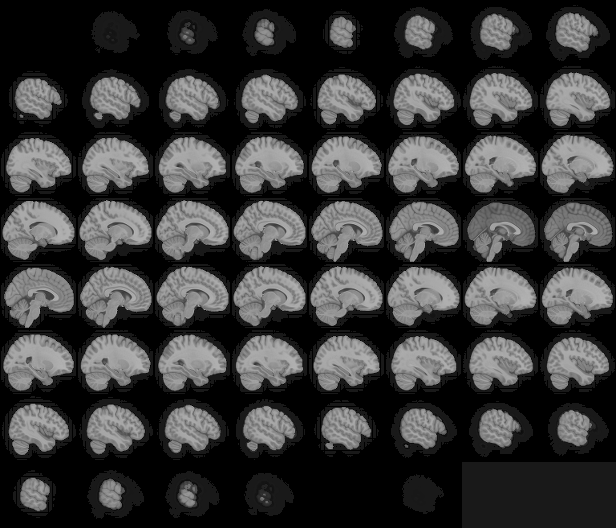
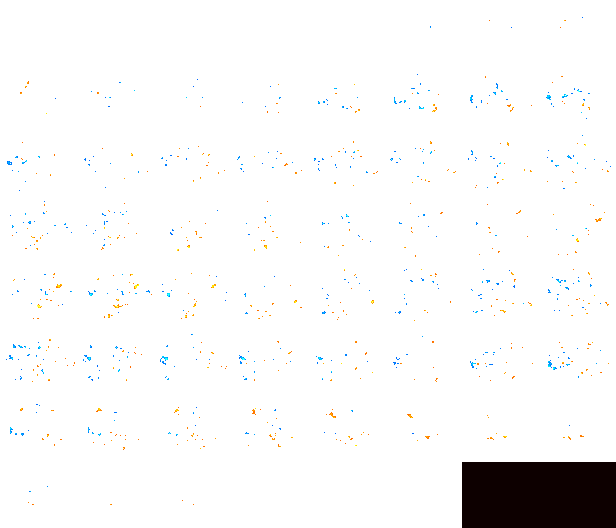

In [18]:
# ============================================================
# 18. Interactive viewers for old/new contrasts
# ============================================================

from nilearn.plotting import view_img
from nilearn.datasets import load_mni152_template
from nilearn.image import resample_to_img

INTERACTIVE_DIR = FIG_DIR / "interactive_viewers"
INTERACTIVE_DIR.mkdir(parents=True, exist_ok=True)

# Use MNI anatomical background
mni_template = load_mni152_template(resolution=2)

# Contrasts worth inspecting interactively
INTERACTIVE_CONTRASTS = [
    "old_gt_new_post_gt_pre",  # primary
    "old_post_gt_pre",        # old images alone
    "new_post_gt_pre",        # new-image control
    "post_old_gt_new",        # descriptive post-only old > new
    "pre_old_gt_new",         # baseline sanity check
    "all_post_gt_pre",        # general post > pre response
]

interactive_view_paths = []

for contrast_name in INTERACTIVE_CONTRASTS:
    print("\n" + "=" * 80)
    print("Interactive viewer:", contrast_name)
    print("Formula:", CONTRAST_FORMULAS[contrast_name])
    
    z_img = load_img(str(get_group_z_map_path(contrast_name)))
    
    mni_template_resampled = resample_to_img(
        mni_template,
        z_img,
        interpolation="continuous",
        force_resample=True,
        copy_header=True,
    )
    
    # z > 2.33 is exploratory. Corrected maps were empty.
    viewer = view_img(
        z_img,
        bg_img=mni_template_resampled,
        threshold=2.33,
        vmax=4.5,
        symmetric_cmap=True,
        cmap="cold_hot",
        title=(
            f"{contrast_name} | {CONTRAST_PRIORITY[contrast_name]} | "
            "exploratory z > 2.33"
        ),
    )
    
    html_path = (
        INTERACTIVE_DIR
        / f"INTERACTIVE_pre_post_old_new_{contrast_name}_{SMOOTHING_LABEL}_zgt233.html"
    )
    
    viewer.save_as_html(str(html_path))
    
    interactive_view_paths.append({
        "contrast": contrast_name,
        "priority": CONTRAST_PRIORITY[contrast_name],
        "formula": CONTRAST_FORMULAS[contrast_name],
        "html_path": str(html_path),
    })
    
    print("Saved:", html_path)

interactive_view_table = pd.DataFrame(interactive_view_paths)

display(interactive_view_table)

interactive_view_table_path = (
    TABLE_DIR
    / f"pre_post_old_new_interactive_viewers_{SMOOTHING_LABEL}.csv"
)

interactive_view_table.to_csv(interactive_view_table_path, index=False)

print("Saved table:", interactive_view_table_path)

# Display the primary contrast directly in the notebook
primary_viewer = view_img(
    load_img(str(get_group_z_map_path("old_gt_new_post_gt_pre"))),
    bg_img=resample_to_img(
        mni_template,
        load_img(str(get_group_z_map_path("old_gt_new_post_gt_pre"))),
        interpolation="continuous",
        force_resample=True,
        copy_header=True,
    ),
    threshold=2.33,
    vmax=4.5,
    symmetric_cmap=True,
    cmap="cold_hot",
    title="Primary contrast: old > new, post > pre | exploratory z > 2.33",
)

primary_viewer


Static figure: old_gt_new_post_gt_pre
Formula: $(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$
Strongest cluster ID: 1
Peak coordinate: [4.0, -19.5, -18.0]
Peak z: 3.9546134
Cluster size mm3: 734.0


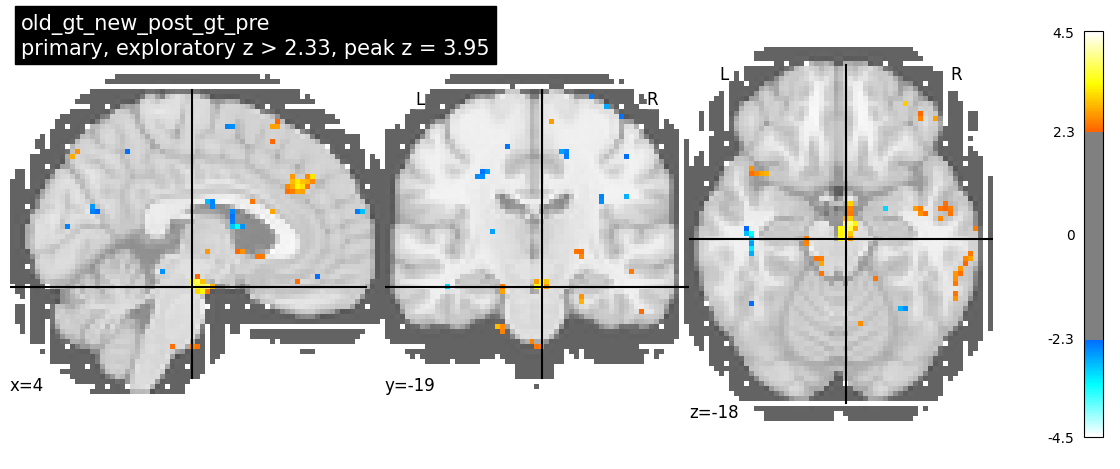

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/static_cluster_figures/STATIC_pre_post_old_new_old_gt_new_post_gt_pre_strongest_cluster_smoothed5mm_zgt233.png

Static figure: old_post_gt_pre
Formula: $\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$
Strongest cluster ID: 1
Peak coordinate: [14.0, -37.0, 12.0]
Peak z: 4.4113655
Cluster size mm3: 203.0


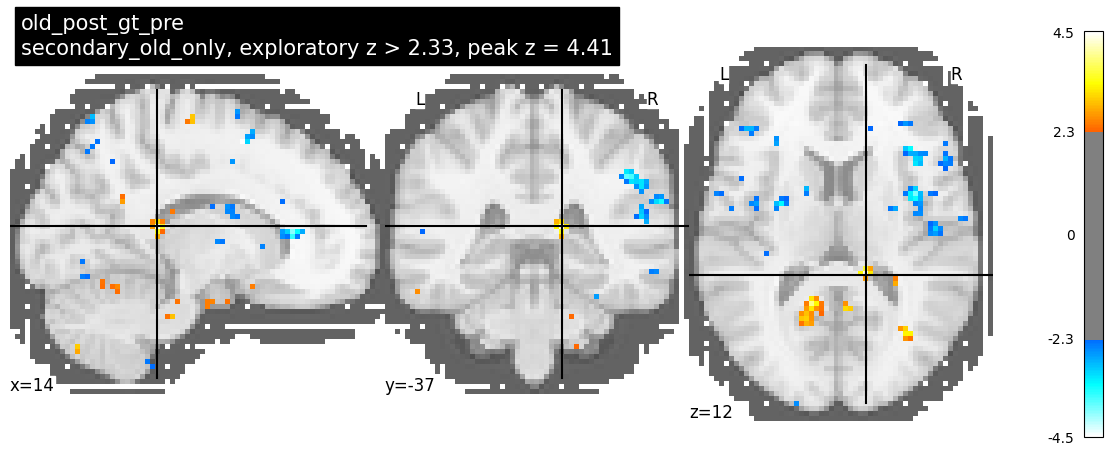

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/static_cluster_figures/STATIC_pre_post_old_new_old_post_gt_pre_strongest_cluster_smoothed5mm_zgt233.png

Static figure: new_post_gt_pre
Formula: $\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$
Strongest cluster ID: 1
Peak coordinate: [-13.5, -52.0, 12.0]
Peak z: 4.127366
Cluster size mm3: 875.0


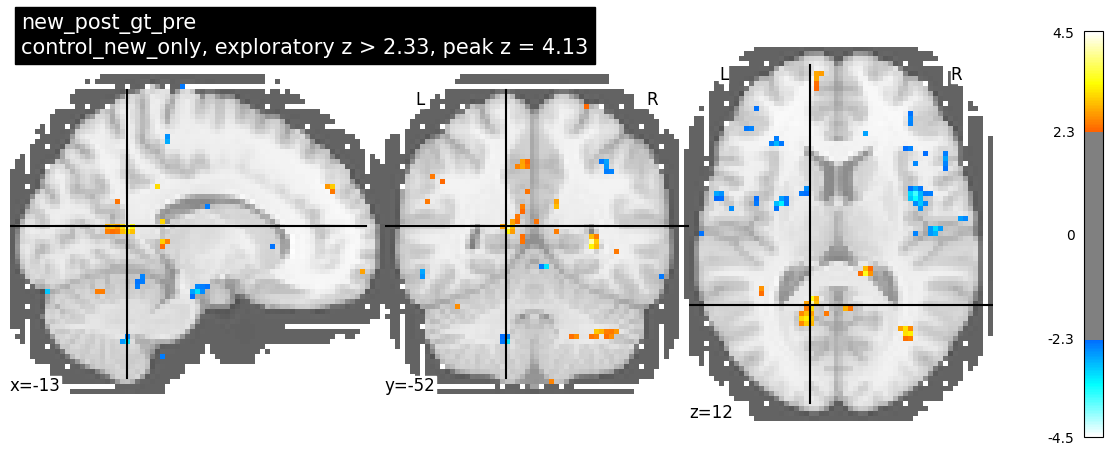

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/static_cluster_figures/STATIC_pre_post_old_new_new_post_gt_pre_strongest_cluster_smoothed5mm_zgt233.png

Static figure: post_old_gt_new
Formula: $\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$
Strongest cluster ID: 1
Peak coordinate: [-18.5, -74.5, 44.5]
Peak z: 4.2659373
Cluster size mm3: 328.0


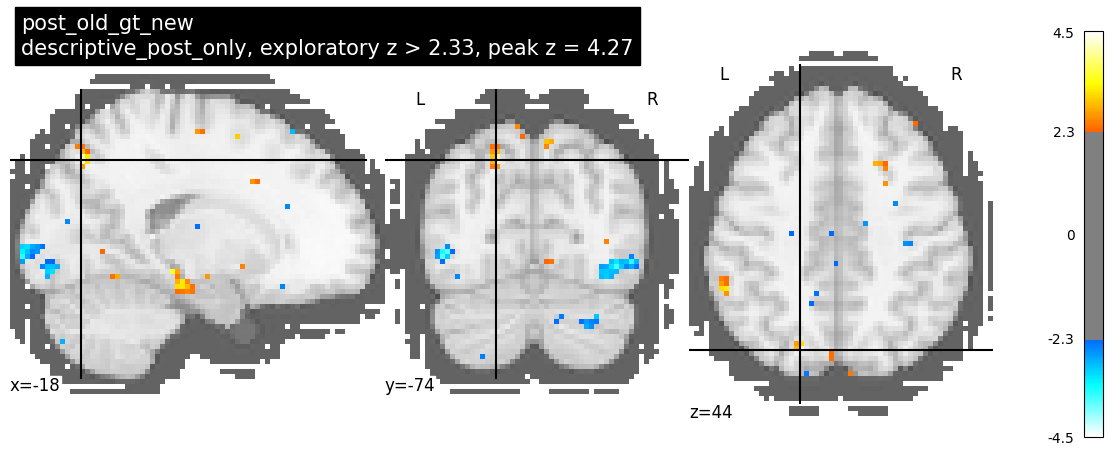

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/static_cluster_figures/STATIC_pre_post_old_new_post_old_gt_new_strongest_cluster_smoothed5mm_zgt233.png

Static figure: pre_old_gt_new
Formula: $\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$
Strongest cluster ID: 1
Peak coordinate: [-26.0, -49.5, -45.5]
Peak z: 4.421069
Cluster size mm3: 250.0


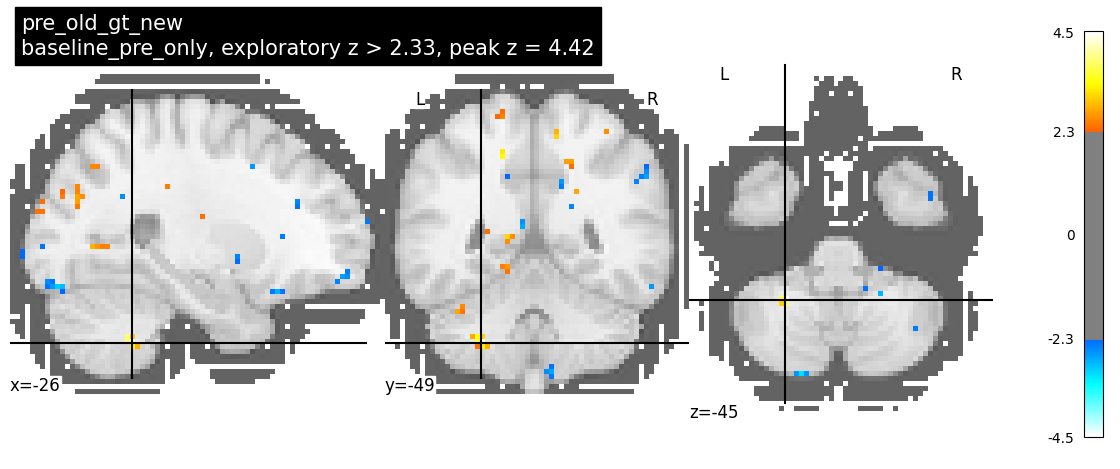

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/static_cluster_figures/STATIC_pre_post_old_new_pre_old_gt_new_strongest_cluster_smoothed5mm_zgt233.png


,contrast,priority,formula,cluster_id,x,y,z,peak_stat,cluster_size_mm3,figure_path
0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",1,4.0,-19.5,-18.0,3.954613,734.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/static_cluster_figures/STATIC_pre_post_old_new_old_gt_...
1,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",1,14.0,-37.0,12.0,4.411365,203.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/static_cluster_figures/STATIC_pre_post_old_new_old_pos...
2,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",1,-13.5,-52.0,12.0,4.127366,875.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/static_cluster_figures/STATIC_pre_post_old_new_new_pos...
3,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",1,-18.5,-74.5,44.5,4.265937,328.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/static_cluster_figures/STATIC_pre_post_old_new_post_ol...
4,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",1,-26.0,-49.5,-45.5,4.421069,250.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/static_cluster_figures/STATIC_pre_post_old_new_pre_old...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/pre_post_old_new_static_strongest_cluster_figures_smoothed5mm.csv


In [19]:
# ============================================================
# 19. Static figures centered on strongest exploratory clusters
# ============================================================

from nilearn.plotting import plot_stat_map

STATIC_CLUSTER_DIR = FIG_DIR / "static_cluster_figures"
STATIC_CLUSTER_DIR.mkdir(parents=True, exist_ok=True)

# Load cluster details saved by Cell 17
cluster_details_path = (
    TABLE_DIR
    / f"pre_post_old_new_cluster_details_z233_z300_from_{SMOOTHING_LABEL}.csv"
)

assert cluster_details_path.exists(), f"Missing cluster details file: {cluster_details_path}"

cluster_details_for_plot = pd.read_csv(cluster_details_path)

cluster_details_for_plot["Peak Stat"] = pd.to_numeric(
    cluster_details_for_plot["Peak Stat"],
    errors="coerce",
)

cluster_details_for_plot["Cluster Size (mm3)"] = pd.to_numeric(
    cluster_details_for_plot["Cluster Size (mm3)"],
    errors="coerce",
)

# Main contrasts to summarize visually.
STATIC_CONTRASTS = [
    "old_gt_new_post_gt_pre",  # primary hypothesis
    "old_post_gt_pre",        # old post > pre
    "new_post_gt_pre",        # control
    "post_old_gt_new",        # post-only descriptive
    "pre_old_gt_new",         # baseline check
]

static_figure_rows = []

for contrast_name in STATIC_CONTRASTS:
    print("\n" + "=" * 80)
    print("Static figure:", contrast_name)
    print("Formula:", CONTRAST_FORMULAS[contrast_name])
    
    contrast_clusters = cluster_details_for_plot.loc[
        (cluster_details_for_plot["contrast"] == contrast_name)
        & (cluster_details_for_plot["threshold_label"] == "z_gt_2.33")
        & (cluster_details_for_plot["Peak Stat"].notna())
    ].copy()
    
    assert len(contrast_clusters) > 0, f"No clusters found for {contrast_name}"
    
    # Use strongest peak at z > 2.33
    strongest_cluster = contrast_clusters.sort_values(
        "Peak Stat",
        ascending=False,
    ).iloc[0]
    
    peak_coord = [
        float(strongest_cluster["X"]),
        float(strongest_cluster["Y"]),
        float(strongest_cluster["Z"]),
    ]
    
    peak_stat = float(strongest_cluster["Peak Stat"])
    cluster_id = strongest_cluster["Cluster ID"]
    cluster_size = strongest_cluster["Cluster Size (mm3)"]
    
    print("Strongest cluster ID:", cluster_id)
    print("Peak coordinate:", peak_coord)
    print("Peak z:", peak_stat)
    print("Cluster size mm3:", cluster_size)
    
    z_img = load_img(str(get_group_z_map_path(contrast_name)))
    
    mni_template_resampled = resample_to_img(
        mni_template,
        z_img,
        interpolation="continuous",
        force_resample=True,
        copy_header=True,
    )
    
    fig = plt.figure(figsize=(11, 4.5))
    
    display_obj = plot_stat_map(
        z_img,
        bg_img=mni_template_resampled,
        display_mode="ortho",
        cut_coords=peak_coord,
        threshold=2.33,
        vmax=4.5,
        cmap="cold_hot",
        black_bg=False,
        title=(
            f"{contrast_name}\n"
            f"{CONTRAST_PRIORITY[contrast_name]}, exploratory z > 2.33, "
            f"peak z = {peak_stat:.2f}"
        ),
        figure=fig,
    )
    
    figure_path = (
        STATIC_CLUSTER_DIR
        / f"STATIC_pre_post_old_new_{contrast_name}_strongest_cluster_{SMOOTHING_LABEL}_zgt233.png"
    )
    
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved:", figure_path)
    
    static_figure_rows.append({
        "contrast": contrast_name,
        "priority": CONTRAST_PRIORITY[contrast_name],
        "formula": CONTRAST_FORMULAS[contrast_name],
        "cluster_id": cluster_id,
        "x": peak_coord[0],
        "y": peak_coord[1],
        "z": peak_coord[2],
        "peak_stat": peak_stat,
        "cluster_size_mm3": cluster_size,
        "figure_path": str(figure_path),
    })

static_figure_table = pd.DataFrame(static_figure_rows)

display(static_figure_table)

static_figure_table_path = (
    TABLE_DIR
    / f"pre_post_old_new_static_strongest_cluster_figures_{SMOOTHING_LABEL}.csv"
)

static_figure_table.to_csv(static_figure_table_path, index=False)

print("Saved:", static_figure_table_path)

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels
118,1,4.0,-19.5,-18.0,3.954613,734.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
119,2,14.0,48.0,-8.0,3.852938,281.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
120,3,-43.5,8.0,-25.5,3.761171,500.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
121,4,-33.5,23.0,32.0,3.698254,156.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
122,3a,-41.0,13.0,-15.5,3.672583,NaN,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
123,5,6.5,33.0,32.0,3.653512,906.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
124,6,9.0,-34.5,-43.0,3.588115,234.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
125,7,-18.5,3.0,57.0,3.564976,265.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
126,8,-8.5,-27.0,-33.0,3.507062,281.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10
127,9,59.0,-4.5,-13.0,3.333862,734.0,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",z_gt_2.33,2.33,10


Primary contrast strongest peak:
Coordinate: [4.0, -19.5, -18.0]
Peak z: 3.9546134
Cluster size: 734.0


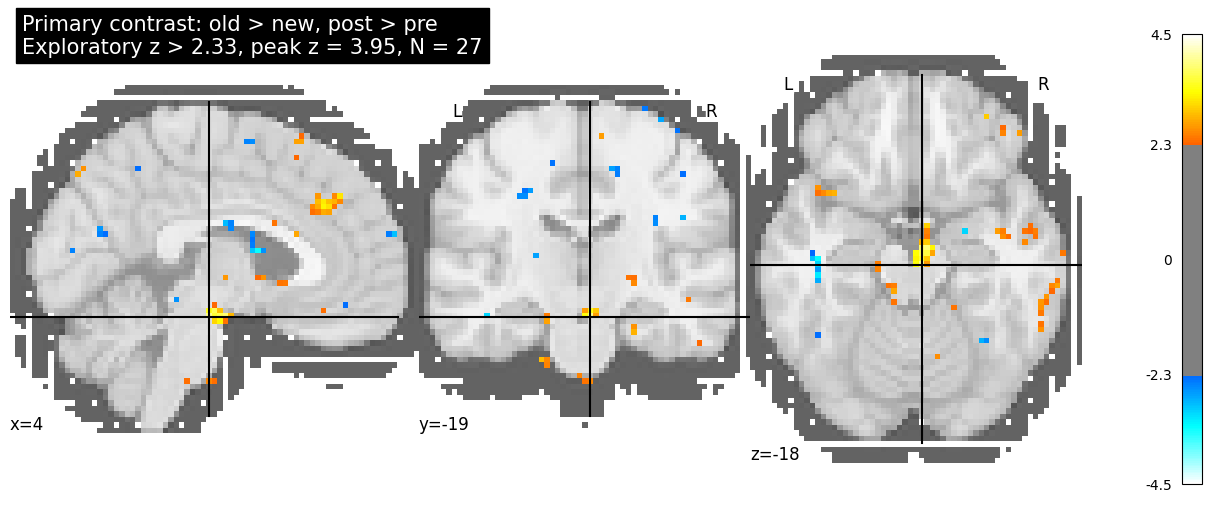

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/static_cluster_figures/SUPERVISOR_primary_old_gt_new_post_gt_pre_strongest_cluster_smoothed5mm_zgt233.png


In [20]:
# ============================================================
# 20. Clean primary-contrast figure for supervisor
# ============================================================

PRIMARY_CONTRAST = "old_gt_new_post_gt_pre"

primary_clusters = cluster_details_for_plot.loc[
    (cluster_details_for_plot["contrast"] == PRIMARY_CONTRAST)
    & (cluster_details_for_plot["threshold_label"] == "z_gt_2.33")
    & (cluster_details_for_plot["Peak Stat"].notna())
].copy()

primary_clusters = primary_clusters.sort_values("Peak Stat", ascending=False)

display(primary_clusters.head(10))

primary_peak = primary_clusters.iloc[0]

primary_peak_coord = [
    float(primary_peak["X"]),
    float(primary_peak["Y"]),
    float(primary_peak["Z"]),
]

primary_peak_stat = float(primary_peak["Peak Stat"])
primary_cluster_size = primary_peak["Cluster Size (mm3)"]

print("Primary contrast strongest peak:")
print("Coordinate:", primary_peak_coord)
print("Peak z:", primary_peak_stat)
print("Cluster size:", primary_cluster_size)

primary_z_img = load_img(str(get_group_z_map_path(PRIMARY_CONTRAST)))

mni_template_resampled = resample_to_img(
    mni_template,
    primary_z_img,
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

fig = plt.figure(figsize=(12, 5))

display_obj = plot_stat_map(
    primary_z_img,
    bg_img=mni_template_resampled,
    display_mode="ortho",
    cut_coords=primary_peak_coord,
    threshold=2.33,
    vmax=4.5,
    cmap="cold_hot",
    black_bg=False,
    title=(
        "Primary contrast: old > new, post > pre\n"
        f"Exploratory z > 2.33, peak z = {primary_peak_stat:.2f}, "
        f"N = {len(subjects)}"
    ),
    figure=fig,
)

primary_supervisor_fig_path = (
    STATIC_CLUSTER_DIR
    / f"SUPERVISOR_primary_old_gt_new_post_gt_pre_strongest_cluster_{SMOOTHING_LABEL}_zgt233.png"
)

fig.savefig(primary_supervisor_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", primary_supervisor_fig_path)

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/interactive_viewers/INTERACTIVE_primary_old_gt_new_post_gt_pre_smoothed5mm_zgt300.html



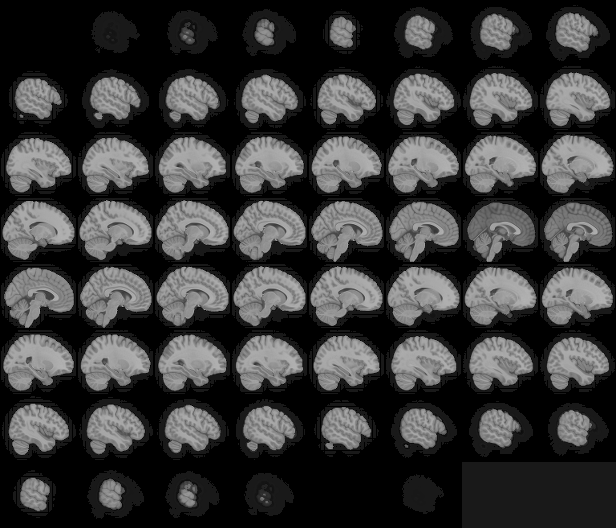
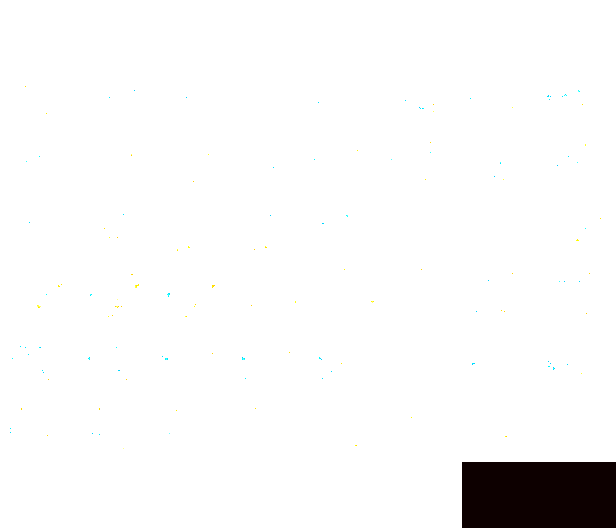

In [21]:
# ============================================================
# 21. Interactive primary contrast at stricter z > 3.0
# ============================================================

PRIMARY_CONTRAST = "old_gt_new_post_gt_pre"

primary_z_img = load_img(str(get_group_z_map_path(PRIMARY_CONTRAST)))

mni_template_resampled = resample_to_img(
    mni_template,
    primary_z_img,
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

primary_viewer_z3 = view_img(
    primary_z_img,
    bg_img=mni_template_resampled,
    threshold=3.0,
    vmax=4.5,
    symmetric_cmap=True,
    cmap="cold_hot",
    title=(
        "Primary contrast: old > new, post > pre "
        "| exploratory z > 3.0"
    ),
)

primary_viewer_z3_path = (
    INTERACTIVE_DIR
    / f"INTERACTIVE_primary_old_gt_new_post_gt_pre_{SMOOTHING_LABEL}_zgt300.html"
)

primary_viewer_z3.save_as_html(str(primary_viewer_z3_path))

print("Saved:", primary_viewer_z3_path)

primary_viewer_z3

In [22]:
# ============================================================
# 22. Primary contrast cluster table
# ============================================================

PRIMARY_CONTRAST = "old_gt_new_post_gt_pre"

primary_cluster_table_path = (
    CLUSTER_TABLE_DIR
    / f"clusters_pre_post_old_new_{PRIMARY_CONTRAST}_z_gt_2.33_from_{SMOOTHING_LABEL}.csv"
)

assert primary_cluster_table_path.exists(), f"Missing: {primary_cluster_table_path}"

primary_clusters = pd.read_csv(primary_cluster_table_path)

primary_clusters["Peak Stat"] = pd.to_numeric(
    primary_clusters["Peak Stat"],
    errors="coerce",
)

primary_clusters["Cluster Size (mm3)"] = pd.to_numeric(
    primary_clusters["Cluster Size (mm3)"],
    errors="coerce",
)

# Keep only main cluster peaks, not subpeaks such as 1a, 1b, etc.
# Subpeaks have NaN cluster size in Nilearn tables.
primary_cluster_peaks = primary_clusters.loc[
    primary_clusters["Cluster Size (mm3)"].notna()
].copy()

primary_cluster_peaks = primary_cluster_peaks.sort_values(
    "Peak Stat",
    ascending=False,
).reset_index(drop=True)

cols_to_show = [
    "Cluster ID",
    "X",
    "Y",
    "Z",
    "Peak Stat",
    "Cluster Size (mm3)",
    "contrast",
    "priority",
    "threshold_label",
]

display(primary_cluster_peaks[cols_to_show])

primary_cluster_peaks_path = (
    TABLE_DIR
    / f"primary_old_gt_new_post_gt_pre_cluster_peaks_{SMOOTHING_LABEL}.csv"
)

primary_cluster_peaks.to_csv(primary_cluster_peaks_path, index=False)

print("Saved:", primary_cluster_peaks_path)

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,threshold_label
0,1,4.0,-19.5,-18.0,3.954613,734.0,old_gt_new_post_gt_pre,primary,z_gt_2.33
1,2,14.0,48.0,-8.0,3.852938,281.0,old_gt_new_post_gt_pre,primary,z_gt_2.33
2,3,-43.5,8.0,-25.5,3.761171,500.0,old_gt_new_post_gt_pre,primary,z_gt_2.33
3,4,-33.5,23.0,32.0,3.698254,156.0,old_gt_new_post_gt_pre,primary,z_gt_2.33
4,5,6.5,33.0,32.0,3.653512,906.0,old_gt_new_post_gt_pre,primary,z_gt_2.33
5,6,9.0,-34.5,-43.0,3.588115,234.0,old_gt_new_post_gt_pre,primary,z_gt_2.33
6,7,-18.5,3.0,57.0,3.564976,265.0,old_gt_new_post_gt_pre,primary,z_gt_2.33
7,8,-8.5,-27.0,-33.0,3.507062,281.0,old_gt_new_post_gt_pre,primary,z_gt_2.33
8,9,59.0,-4.5,-13.0,3.333862,734.0,old_gt_new_post_gt_pre,primary,z_gt_2.33
9,10,56.5,-47.0,34.5,3.333428,1125.0,old_gt_new_post_gt_pre,primary,z_gt_2.33


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/primary_old_gt_new_post_gt_pre_cluster_peaks_smoothed5mm.csv


In [25]:
# ============================================================
# 23b. Corrected atlas labeling of primary contrast cluster peaks
# Handles Nilearn versions where atlas.maps is already a Nifti1Image
# ============================================================

from nilearn import datasets
from nilearn.image import load_img
from nilearn.image.resampling import coord_transform


def ensure_img(img_or_path):
    """
    Return a nibabel image whether input is already an image or a filepath.
    """
    if hasattr(img_or_path, "get_fdata"):
        return img_or_path
    return load_img(str(img_or_path))


def load_harvard_oxford_atlases():
    """
    Load cortical and subcortical Harvard-Oxford maximum-probability atlases.
    """
    cortical = datasets.fetch_atlas_harvard_oxford(
        "cort-maxprob-thr25-2mm"
    )
    
    subcortical = datasets.fetch_atlas_harvard_oxford(
        "sub-maxprob-thr25-2mm"
    )
    
    return cortical, subcortical


def label_coordinate_from_atlas(coord, atlas_img, labels):
    """
    Label one MNI coordinate using a discrete atlas image.
    
    Parameters
    ----------
    coord : list or tuple
        MNI coordinate [x, y, z].
    atlas_img : nibabel image
        Discrete atlas image.
    labels : list
        Atlas labels.
    """
    x, y, z = coord
    
    i, j, k = coord_transform(
        x,
        y,
        z,
        np.linalg.inv(atlas_img.affine),
    )
    
    i, j, k = int(round(i)), int(round(j)), int(round(k))
    
    data = atlas_img.get_fdata()
    
    if (
        i < 0 or i >= data.shape[0]
        or j < 0 or j >= data.shape[1]
        or k < 0 or k >= data.shape[2]
    ):
        return "outside_atlas", np.nan
    
    atlas_value = int(data[i, j, k])
    
    if atlas_value < 0 or atlas_value >= len(labels):
        return "unknown_label_index", atlas_value
    
    return labels[atlas_value], atlas_value


ho_cortical, ho_subcortical = load_harvard_oxford_atlases()

ho_cortical_img = ensure_img(ho_cortical.maps)
ho_subcortical_img = ensure_img(ho_subcortical.maps)

atlas_rows = []

for _, row in primary_cluster_peaks.iterrows():
    coord = [
        float(row["X"]),
        float(row["Y"]),
        float(row["Z"]),
    ]
    
    cortical_label, cortical_value = label_coordinate_from_atlas(
        coord,
        ho_cortical_img,
        ho_cortical.labels,
    )
    
    subcortical_label, subcortical_value = label_coordinate_from_atlas(
        coord,
        ho_subcortical_img,
        ho_subcortical.labels,
    )
    
    atlas_rows.append({
        "cluster_id": row["Cluster ID"],
        "x": coord[0],
        "y": coord[1],
        "z": coord[2],
        "peak_z": row["Peak Stat"],
        "cluster_size_mm3": row["Cluster Size (mm3)"],
        "harvard_oxford_cortical_label": cortical_label,
        "harvard_oxford_cortical_value": cortical_value,
        "harvard_oxford_subcortical_label": subcortical_label,
        "harvard_oxford_subcortical_value": subcortical_value,
    })

primary_cluster_atlas_labels = pd.DataFrame(atlas_rows)

display(primary_cluster_atlas_labels)

atlas_labels_path = (
    TABLE_DIR
    / f"primary_old_gt_new_post_gt_pre_cluster_atlas_labels_{SMOOTHING_LABEL}.csv"
)

primary_cluster_atlas_labels.to_csv(atlas_labels_path, index=False)

print("Saved:", atlas_labels_path)

[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl


,cluster_id,x,y,z,peak_z,cluster_size_mm3,harvard_oxford_cortical_label,harvard_oxford_cortical_value,harvard_oxford_subcortical_label,harvard_oxford_subcortical_value
0,1,4.0,-19.5,-18.0,3.954613,734.0,Background,0,Brain-Stem,8
1,2,14.0,48.0,-8.0,3.852938,281.0,Background,0,Right Cerebral White Matter,12
2,3,-43.5,8.0,-25.5,3.761171,500.0,Background,0,Left Cerebral White Matter,1
3,4,-33.5,23.0,32.0,3.698254,156.0,Background,0,Left Cerebral White Matter,1
4,5,6.5,33.0,32.0,3.653512,906.0,Paracingulate Gyrus,28,Right Cerebral Cortex,13
5,6,9.0,-34.5,-43.0,3.588115,234.0,Background,0,Brain-Stem,8
6,7,-18.5,3.0,57.0,3.564976,265.0,Superior Frontal Gyrus,3,Left Cerebral White Matter,1
7,8,-8.5,-27.0,-33.0,3.507062,281.0,Background,0,Brain-Stem,8
8,9,59.0,-4.5,-13.0,3.333862,734.0,"Superior Temporal Gyrus, anterior division",9,Right Cerebral Cortex,13
9,10,56.5,-47.0,34.5,3.333428,1125.0,Angular Gyrus,21,Right Cerebral Cortex,13


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/primary_old_gt_new_post_gt_pre_cluster_atlas_labels_smoothed5mm.csv


In [26]:
# ============================================================
# 26. Clean grey-matter peak table for primary contrast
# Exclude background, white matter, and brainstem labels
# ============================================================

primary_labels = primary_cluster_atlas_labels.copy()

def is_probably_non_grey_matter(row):
    cortical_label = str(row["harvard_oxford_cortical_label"])
    subcortical_label = str(row["harvard_oxford_subcortical_label"])
    
    bad_terms = [
        "Background",
        "White Matter",
        "Brain-Stem",
        "Ventricle",
        "CSF",
    ]
    
    combined = cortical_label + " " + subcortical_label
    
    return any(term in combined for term in bad_terms) and cortical_label == "Background"


primary_labels["probably_non_grey_matter_peak"] = primary_labels.apply(
    is_probably_non_grey_matter,
    axis=1,
)

primary_grey_matter_peaks = primary_labels.loc[
    ~primary_labels["probably_non_grey_matter_peak"]
].copy()

primary_grey_matter_peaks = primary_grey_matter_peaks.sort_values(
    "peak_z",
    ascending=False,
).reset_index(drop=True)

display(primary_grey_matter_peaks)

primary_grey_matter_peaks_path = (
    TABLE_DIR
    / f"primary_old_gt_new_post_gt_pre_grey_matter_peaks_{SMOOTHING_LABEL}.csv"
)

primary_grey_matter_peaks.to_csv(primary_grey_matter_peaks_path, index=False)

print("Saved:", primary_grey_matter_peaks_path)

,cluster_id,x,y,z,peak_z,cluster_size_mm3,harvard_oxford_cortical_label,harvard_oxford_cortical_value,harvard_oxford_subcortical_label,harvard_oxford_subcortical_value,probably_non_grey_matter_peak
0,5,6.5,33.0,32.0,3.653512,906.0,Paracingulate Gyrus,28,Right Cerebral Cortex,13,False
1,7,-18.5,3.0,57.0,3.564976,265.0,Superior Frontal Gyrus,3,Left Cerebral White Matter,1,False
2,9,59.0,-4.5,-13.0,3.333862,734.0,"Superior Temporal Gyrus, anterior division",9,Right Cerebral Cortex,13,False
3,10,56.5,-47.0,34.5,3.333428,1125.0,Angular Gyrus,21,Right Cerebral Cortex,13,False
4,11,19.0,-14.5,-28.0,3.148191,171.0,"Parahippocampal Gyrus, anterior division",34,Right Cerebral Cortex,13,False
5,12,31.5,33.0,32.0,3.122716,218.0,Middle Frontal Gyrus,4,Right Cerebral Cortex,13,False
6,13,21.5,13.0,64.5,3.091164,250.0,Superior Frontal Gyrus,3,Right Cerebral Cortex,13,False
7,14,-43.5,8.0,-8.0,3.033542,171.0,Insular Cortex,2,Left Cerebral Cortex,2,False
8,15,61.5,-39.5,-13.0,2.887852,187.0,"Middle Temporal Gyrus, temporooccipital part",13,Right Cerebral Cortex,13,False
9,16,-1.0,33.0,54.5,2.879575,171.0,Superior Frontal Gyrus,3,Left Cerebral Cortex,2,False


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/primary_old_gt_new_post_gt_pre_grey_matter_peaks_smoothed5mm.csv


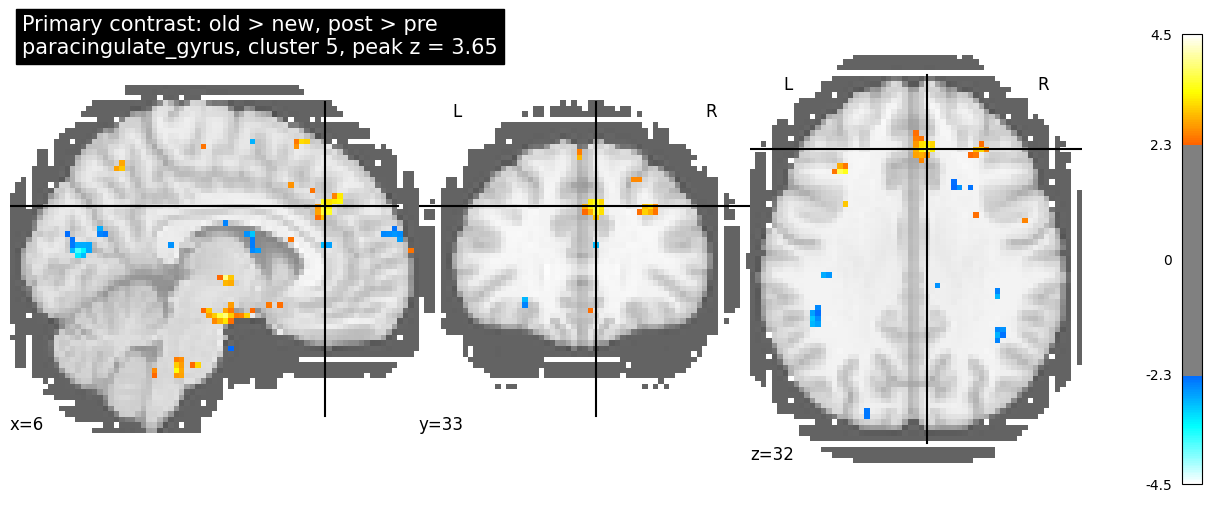

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/primary_selected_interpretable_peaks/primary_old_gt_new_post_gt_pre_paracingulate_gyrus_smoothed5mm_zgt233.png


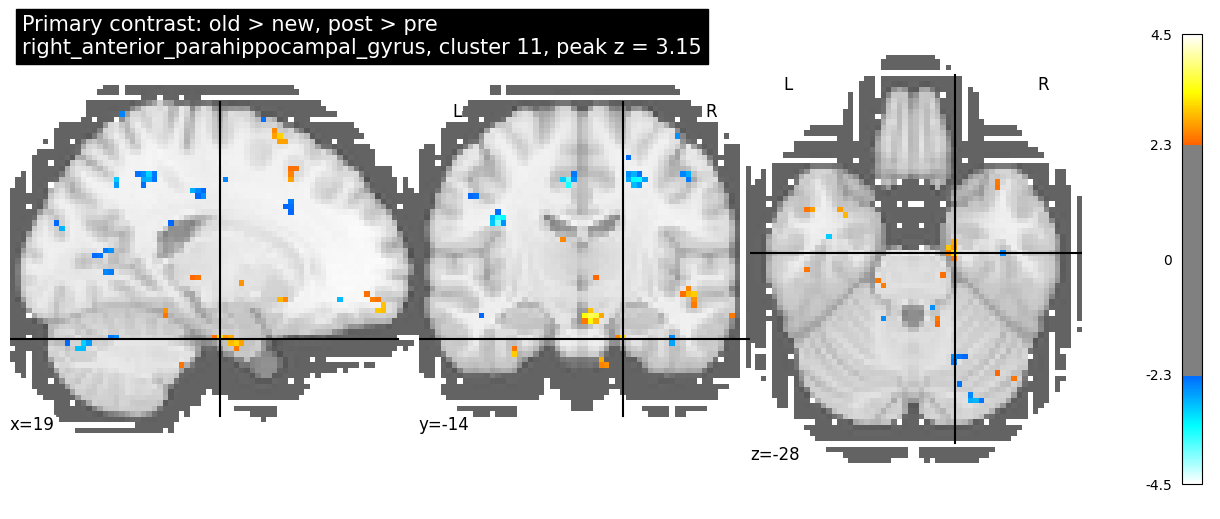

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/primary_selected_interpretable_peaks/primary_old_gt_new_post_gt_pre_right_anterior_parahippocampal_gyrus_smoothed5mm_zgt233.png


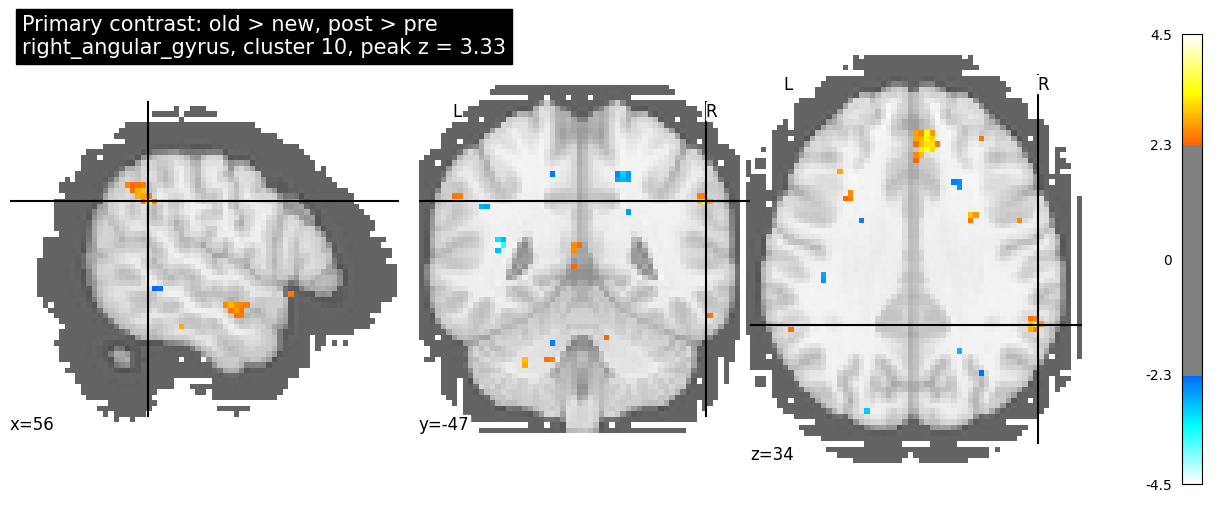

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/primary_selected_interpretable_peaks/primary_old_gt_new_post_gt_pre_right_angular_gyrus_smoothed5mm_zgt233.png


,label,cluster_id,x,y,z,peak_z,cluster_size_mm3,harvard_oxford_cortical_label,harvard_oxford_subcortical_label,reason,figure_path
0,paracingulate_gyrus,5,6.5,33.0,32.0,3.653512,906.0,Paracingulate Gyrus,Right Cerebral Cortex,strongest grey-matter-labeled primary peak,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/primary_selected_interpretable_peaks/primary_old_gt_ne...
1,right_anterior_parahippocampal_gyrus,11,19.0,-14.5,-28.0,3.148191,171.0,"Parahippocampal Gyrus, anterior division",Right Cerebral Cortex,most anatomically relevant medial-temporal primary peak,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/primary_selected_interpretable_peaks/primary_old_gt_ne...
2,right_angular_gyrus,10,56.5,-47.0,34.5,3.333428,1125.0,Angular Gyrus,Right Cerebral Cortex,memory-relevant association cortex peak,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/figures/primary_selected_interpretable_peaks/primary_old_gt_ne...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/tables/primary_old_gt_new_post_gt_pre_selected_interpretable_peak_figures_smoothed5mm.csv


In [27]:
# ============================================================
# 27. Plot selected interpretable primary contrast peaks
# ============================================================

SELECTED_PRIMARY_PEAKS = [
    {
        "label": "paracingulate_gyrus",
        "coord": [6.5, 33.0, 32.0],
        "cluster_id": 5,
        "reason": "strongest grey-matter-labeled primary peak",
    },
    {
        "label": "right_anterior_parahippocampal_gyrus",
        "coord": [19.0, -14.5, -28.0],
        "cluster_id": 11,
        "reason": "most anatomically relevant medial-temporal primary peak",
    },
    {
        "label": "right_angular_gyrus",
        "coord": [56.5, -47.0, 34.5],
        "cluster_id": 10,
        "reason": "memory-relevant association cortex peak",
    },
]

SELECTED_PRIMARY_FIG_DIR = FIG_DIR / "primary_selected_interpretable_peaks"
SELECTED_PRIMARY_FIG_DIR.mkdir(parents=True, exist_ok=True)

primary_z_img = load_img(str(get_group_z_map_path(PRIMARY_CONTRAST)))

mni_template = load_mni152_template(resolution=2)

mni_template_resampled = resample_to_img(
    mni_template,
    primary_z_img,
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

selected_peak_rows = []

for peak in SELECTED_PRIMARY_PEAKS:
    label = peak["label"]
    coord = peak["coord"]
    cluster_id = peak["cluster_id"]
    
    matching = primary_cluster_atlas_labels.loc[
        primary_cluster_atlas_labels["cluster_id"].astype(str) == str(cluster_id)
    ]
    
    if len(matching) > 0:
        peak_z = float(matching.iloc[0]["peak_z"])
        cluster_size = float(matching.iloc[0]["cluster_size_mm3"])
        cortical_label = matching.iloc[0]["harvard_oxford_cortical_label"]
        subcortical_label = matching.iloc[0]["harvard_oxford_subcortical_label"]
    else:
        peak_z = np.nan
        cluster_size = np.nan
        cortical_label = ""
        subcortical_label = ""
    
    fig = plt.figure(figsize=(12, 5))
    
    plot_stat_map(
        primary_z_img,
        bg_img=mni_template_resampled,
        display_mode="ortho",
        cut_coords=coord,
        threshold=2.33,
        vmax=4.5,
        cmap="cold_hot",
        black_bg=False,
        title=(
            "Primary contrast: old > new, post > pre\n"
            f"{label}, cluster {cluster_id}, peak z = {peak_z:.2f}"
        ),
        figure=fig,
    )
    
    fig_path = (
        SELECTED_PRIMARY_FIG_DIR
        / f"primary_old_gt_new_post_gt_pre_{label}_{SMOOTHING_LABEL}_zgt233.png"
    )
    
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved:", fig_path)
    
    selected_peak_rows.append({
        "label": label,
        "cluster_id": cluster_id,
        "x": coord[0],
        "y": coord[1],
        "z": coord[2],
        "peak_z": peak_z,
        "cluster_size_mm3": cluster_size,
        "harvard_oxford_cortical_label": cortical_label,
        "harvard_oxford_subcortical_label": subcortical_label,
        "reason": peak["reason"],
        "figure_path": str(fig_path),
    })

selected_primary_peak_figures = pd.DataFrame(selected_peak_rows)

display(selected_primary_peak_figures)

selected_primary_peak_figures_path = (
    TABLE_DIR
    / f"primary_old_gt_new_post_gt_pre_selected_interpretable_peak_figures_{SMOOTHING_LABEL}.csv"
)

selected_primary_peak_figures.to_csv(selected_primary_peak_figures_path, index=False)

print("Saved:", selected_primary_peak_figures_path)

In [28]:
# ============================================================
# 28. ROI setup and mask availability
# Subject-specific hippoAmyg masks
# ============================================================

from nilearn.masking import apply_mask
from nilearn.image import resample_to_img
from scipy import stats

SUPERVISOR_MASK_ROOT = DATA_DIR / "rois" / "hippoAmyg_02022024"

ROI_DIR = OUT_DIR / "roi"
ROI_TABLE_DIR = ROI_DIR / "tables"
ROI_FIG_DIR = ROI_DIR / "figures"

for path in [
    ROI_DIR,
    ROI_TABLE_DIR,
    ROI_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("Supervisor mask root:")
print(SUPERVISOR_MASK_ROOT)
print("Exists:", SUPERVISOR_MASK_ROOT.exists())

assert SUPERVISOR_MASK_ROOT.exists(), f"Missing ROI mask root: {SUPERVISOR_MASK_ROOT}"


def find_supervisor_hippoamyg_mask(subject, hemi):
    """
    Flexible search for subject-specific hippoAmyg masks.
    
    hemi should be:
    - 'L'
    - 'R'
    """
    subject_root = SUPERVISOR_MASK_ROOT / subject
    
    patterns = [
        f"**/*hemi-{hemi}*hippoAmyg*.nii.gz",
        f"**/*hemi-{hemi}*hippoamyg*.nii.gz",
        f"**/*{hemi}*hippoAmyg*.nii.gz",
        f"**/*{hemi}*hippoamyg*.nii.gz",
    ]
    
    matches = []
    
    for pattern in patterns:
        matches.extend(sorted(subject_root.glob(pattern)))
    
    # Deduplicate while preserving order.
    unique_matches = []
    seen = set()
    
    for path in matches:
        if path not in seen:
            unique_matches.append(path)
            seen.add(path)
    
    if len(unique_matches) == 0:
        return None
    
    if len(unique_matches) > 1:
        print(f"Warning: multiple {hemi} masks found for {subject}. Using first:")
        for path in unique_matches:
            print(" ", path)
    
    return unique_matches[0]


roi_availability_rows = []

for subject in subjects:
    left_mask = find_supervisor_hippoamyg_mask(subject, "L")
    right_mask = find_supervisor_hippoamyg_mask(subject, "R")
    
    row = {
        "subject": subject,
        "left_mask_path": str(left_mask) if left_mask is not None else "",
        "right_mask_path": str(right_mask) if right_mask is not None else "",
        "left_mask_exists": left_mask is not None and left_mask.exists(),
        "right_mask_exists": right_mask is not None and right_mask.exists(),
    }
    
    for contrast_name in OLD_NEW_CONTRASTS.keys():
        row[f"{contrast_name}_effect_exists"] = get_first_level_effect_map_path(
            subject,
            contrast_name,
        ).exists()
    
    roi_availability_rows.append(row)

roi_availability = pd.DataFrame(roi_availability_rows)

display(roi_availability)

missing_roi = roi_availability.loc[
    (~roi_availability["left_mask_exists"])
    | (~roi_availability["right_mask_exists"])
].copy()

print("\nMissing ROI masks:")
display(missing_roi)

assert missing_roi.empty, "Some subjects are missing left/right hippoAmyg masks."

for contrast_name in OLD_NEW_CONTRASTS.keys():
    assert roi_availability[f"{contrast_name}_effect_exists"].all(), (
        f"Some first-level effect maps are missing for {contrast_name}"
    )

roi_availability_path = ROI_TABLE_DIR / f"pre_post_old_new_hippoAmyg_mask_availability_{SMOOTHING_LABEL}.csv"
roi_availability.to_csv(roi_availability_path, index=False)

print("Saved:", roi_availability_path)

Supervisor mask root:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024
Exists: True
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-T1_hemi-L_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-fsnative_hemi-L_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NL

,subject,left_mask_path,right_mask_path,left_mask_exists,right_mask_exists,old_gt_new_post_gt_pre_effect_exists,old_post_gt_pre_effect_exists,new_post_gt_pre_effect_exists,post_old_gt_new_effect_exists,pre_old_gt_new_effect_exists,all_post_gt_pre_effect_exists
0,sub-P10,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...,True,True,True,True,True,True,True,True
1,sub-P12,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P12/ses-01/anat/sub-P12_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P12/ses-01/anat/sub-P12_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...,True,True,True,True,True,True,True,True
2,sub-P13,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P13/ses-01/anat/sub-P13_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P13/ses-01/anat/sub-P13_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...,True,True,True,True,True,True,True,True
3,sub-P14,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P14/ses-01/anat/sub-P14_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P14/ses-01/anat/sub-P14_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...,True,True,True,True,True,True,True,True
4,sub-P15,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P15/ses-01/anat/sub-P15_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P15/ses-01/anat/sub-P15_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...,True,True,True,True,True,True,True,True
5,sub-P16,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P16/ses-01/anat/sub-P16_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P16/ses-01/anat/sub-P16_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...,True,True,True,True,True,True,True,True
6,sub-P17,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P17/ses-01/anat/sub-P17_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P17/ses-01/anat/sub-P17_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...,True,True,True,True,True,True,True,True
7,sub-P18,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P18/ses-01/anat/sub-P18_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P18/ses-01/anat/sub-P18_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...,True,True,True,True,True,True,True,True
8,sub-P19,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P19/ses-01/anat/sub-P19_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P19/ses-01/anat/sub-P19_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...,True,True,True,True,True,True,True,True
9,sub-P21,/media/RCPNAS/Data3/Alison_island/krocz


Missing ROI masks:


,subject,left_mask_path,right_mask_path,left_mask_exists,right_mask_exists,old_gt_new_post_gt_pre_effect_exists,old_post_gt_pre_effect_exists,new_post_gt_pre_effect_exists,post_old_gt_new_effect_exists,pre_old_gt_new_effect_exists,all_post_gt_pre_effect_exists


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/roi/tables/pre_post_old_new_hippoAmyg_mask_availability_smoothed5mm.csv


In [29]:
# ============================================================
# 29. Extract subject-level old/new effects inside hippoAmyg ROI
# ============================================================

def make_binary_resampled_mask(mask_path, reference_img):
    """
    Load a subject-specific ROI mask, binarize it, and resample it
    to the first-level effect-map space.
    """
    mask_img = nib.load(str(mask_path))
    mask_data = mask_img.get_fdata()
    
    binary_mask_img = nib.Nifti1Image(
        (mask_data > 0).astype(np.uint8),
        affine=mask_img.affine,
        header=mask_img.header,
    )
    
    resampled_mask = resample_to_img(
        binary_mask_img,
        reference_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    resampled_data = resampled_mask.get_fdata() > 0
    
    resampled_binary_mask = nib.Nifti1Image(
        resampled_data.astype(np.uint8),
        affine=reference_img.affine,
        header=reference_img.header,
    )
    
    return resampled_binary_mask


def extract_mean_effect_from_mask(effect_img, mask_img):
    """
    Extract the mean first-level effect inside a binary ROI mask.
    """
    values = apply_mask(effect_img, mask_img)
    values = np.asarray(values).ravel()
    values = values[np.isfinite(values)]
    
    if len(values) == 0:
        return np.nan, 0
    
    return float(np.mean(values)), int(len(values))


roi_effect_rows = []

for subject in subjects:
    print("Extracting ROI effects:", subject)
    
    reference_effect_path = get_first_level_effect_map_path(
        subject,
        "old_gt_new_post_gt_pre",
    )
    
    reference_img = nib.load(str(reference_effect_path))
    
    left_mask = make_binary_resampled_mask(
        find_supervisor_hippoamyg_mask(subject, "L"),
        reference_img,
    )
    
    right_mask = make_binary_resampled_mask(
        find_supervisor_hippoamyg_mask(subject, "R"),
        reference_img,
    )
    
    bilateral_data = (
        (left_mask.get_fdata() > 0)
        | (right_mask.get_fdata() > 0)
    )
    
    bilateral_mask = nib.Nifti1Image(
        bilateral_data.astype(np.uint8),
        affine=reference_img.affine,
        header=reference_img.header,
    )
    
    masks = {
        "left_hippoAmyg": left_mask,
        "right_hippoAmyg": right_mask,
        "bilateral_hippoAmyg": bilateral_mask,
    }
    
    for contrast_name in OLD_NEW_CONTRASTS.keys():
        effect_path = get_first_level_effect_map_path(subject, contrast_name)
        effect_img = nib.load(str(effect_path))
        
        for roi_name, mask_img in masks.items():
            mean_effect, n_voxels = extract_mean_effect_from_mask(
                effect_img,
                mask_img,
            )
            
            roi_effect_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "priority": CONTRAST_PRIORITY[contrast_name],
                "formula": CONTRAST_FORMULAS[contrast_name],
                "roi": roi_name,
                "mean_effect": mean_effect,
                "n_voxels": n_voxels,
                "effect_map_path": str(effect_path),
            })

roi_effects = pd.DataFrame(roi_effect_rows)

display(roi_effects.head())

print("\nVoxel-count summary:")
display(
    roi_effects
    .groupby("roi")
    .agg(
        mean_n_voxels=("n_voxels", "mean"),
        min_n_voxels=("n_voxels", "min"),
        max_n_voxels=("n_voxels", "max"),
    )
    .reset_index()
)

roi_effects_path = ROI_TABLE_DIR / f"pre_post_old_new_hippoAmyg_subject_effects_{SMOOTHING_LABEL}.csv"
roi_effects.to_csv(roi_effects_path, index=False)

print("Saved:", roi_effects_path)

Extracting ROI effects: sub-P10
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-T1_hemi-L_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-fsnative_hemi-L_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semes

,subject,contrast,priority,formula,roi,mean_effect,n_voxels,effect_map_path
0,sub-P10,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",left_hippoAmyg,-0.002693,448,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_old_gt_new_post_gt_pre_sm...
1,sub-P10,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",right_hippoAmyg,0.007733,451,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_old_gt_new_post_gt_pre_sm...
2,sub-P10,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",bilateral_hippoAmyg,0.002537,899,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_old_gt_new_post_gt_pre_sm...
3,sub-P10,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",left_hippoAmyg,-0.072223,448,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_old_post_gt_pre_smoothed5...
4,sub-P10,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",right_hippoAmyg,-0.043679,451,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_old_post_gt_pre_smoothed5...



Voxel-count summary:


,roi,mean_n_voxels,min_n_voxels,max_n_voxels
0,bilateral_hippoAmyg,933.592593,859,1020
1,left_hippoAmyg,455.962963,411,494
2,right_hippoAmyg,477.629630,446,526


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/roi/tables/pre_post_old_new_hippoAmyg_subject_effects_smoothed5mm.csv


In [30]:
# ============================================================
# 30. Group-level hippoAmyg ROI statistics
# ============================================================

roi_summary_rows = []

for (contrast_name, roi_name), df in roi_effects.groupby(["contrast", "roi"]):
    values = df["mean_effect"].dropna().values
    n = len(values)
    
    mean_effect = float(np.mean(values))
    sd_effect = float(np.std(values, ddof=1))
    sem_effect = float(sd_effect / np.sqrt(n))
    
    t_stat, p_two_sided = stats.ttest_1samp(values, popmean=0.0)
    
    if t_stat >= 0:
        p_one_sided_positive = p_two_sided / 2
    else:
        p_one_sided_positive = 1 - (p_two_sided / 2)
    
    n_positive = int(np.sum(values > 0))
    
    roi_summary_rows.append({
        "contrast": contrast_name,
        "priority": CONTRAST_PRIORITY[contrast_name],
        "formula": CONTRAST_FORMULAS[contrast_name],
        "roi": roi_name,
        "n_subjects": n,
        "mean_effect": mean_effect,
        "sd_effect": sd_effect,
        "sem_effect": sem_effect,
        "t_stat": float(t_stat),
        "p_two_sided": float(p_two_sided),
        "p_one_sided_positive": float(p_one_sided_positive),
        "n_positive": n_positive,
        "proportion_positive": n_positive / n,
    })

roi_summary = pd.DataFrame(roi_summary_rows)

roi_summary = roi_summary.sort_values(
    ["priority", "contrast", "roi"]
).reset_index(drop=True)

display(roi_summary)

roi_summary_path = ROI_TABLE_DIR / f"pre_post_old_new_hippoAmyg_group_summary_{SMOOTHING_LABEL}.csv"
roi_summary.to_csv(roi_summary_path, index=False)

print("Saved:", roi_summary_path)

,contrast,priority,formula,roi,n_subjects,mean_effect,sd_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,n_positive,proportion_positive
0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",bilateral_hippoAmyg,27,0.001227,0.055586,0.010698,0.114684,0.909577,0.454788,12,0.444444
1,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",left_hippoAmyg,27,-0.000809,0.058792,0.011315,-0.071477,0.943565,0.528218,13,0.481481
2,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",right_hippoAmyg,27,0.002955,0.056304,0.010836,0.272754,0.787197,0.393598,13,0.481481
3,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",bilateral_hippoAmyg,27,0.009080,0.086096,0.016569,0.547988,0.588375,0.294187,14,0.518519
4,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",left_hippoAmyg,27,0.005688,0.085680,0.016489,0.344979,0.732885,0.366443,14,0.518519
5,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",right_hippoAmyg,27,0.012436,0.091108,0.017534,0.709282,0.484462,0.242231,13,0.481481
6,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",bilateral_hippoAmyg,27,0.009141,0.081600,0.015704,0.582104,0.565510,0.282755,15,0.555556
7,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",left_hippoAmyg,27,0.006831,0.082515,0.015880,0.430187,0.670604,0.335302,14,0.518519
8,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",right_hippoAmyg,27,0.011500,0.085308,0.016417,0.700455,0.489864,0.244932,14,0.518519
9,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",bilateral_hippoAmyg,27,0.001473,0.059216,0.011396,0.129284,0.898128,0.449064,13,0.481481


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/roi/tables/pre_post_old_new_hippoAmyg_group_summary_smoothed5mm.csv


In [31]:
# ============================================================
# 31. Compact ROI table for the main old/new contrasts
# ============================================================

roi_contrasts_to_show = [
    "old_gt_new_post_gt_pre",
    "old_post_gt_pre",
    "new_post_gt_pre",
    "post_old_gt_new",
    "pre_old_gt_new",
]

roi_order = [
    "bilateral_hippoAmyg",
    "left_hippoAmyg",
    "right_hippoAmyg",
]

compact_roi_summary = roi_summary.loc[
    roi_summary["contrast"].isin(roi_contrasts_to_show)
    & roi_summary["roi"].isin(roi_order)
].copy()

compact_roi_summary = compact_roi_summary[
    [
        "contrast",
        "priority",
        "roi",
        "n_subjects",
        "mean_effect",
        "sem_effect",
        "t_stat",
        "p_two_sided",
        "p_one_sided_positive",
        "n_positive",
        "proportion_positive",
    ]
].copy()

compact_roi_summary = compact_roi_summary.sort_values(
    ["contrast", "roi"]
).reset_index(drop=True)

display(compact_roi_summary)

compact_roi_summary_path = ROI_TABLE_DIR / f"pre_post_old_new_compact_hippoAmyg_summary_{SMOOTHING_LABEL}.csv"
compact_roi_summary.to_csv(compact_roi_summary_path, index=False)

print("Saved:", compact_roi_summary_path)

,contrast,priority,roi,n_subjects,mean_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,n_positive,proportion_positive
0,new_post_gt_pre,control_new_only,bilateral_hippoAmyg,27,0.009080,0.016569,0.547988,0.588375,0.294187,14,0.518519
1,new_post_gt_pre,control_new_only,left_hippoAmyg,27,0.005688,0.016489,0.344979,0.732885,0.366443,14,0.518519
2,new_post_gt_pre,control_new_only,right_hippoAmyg,27,0.012436,0.017534,0.709282,0.484462,0.242231,13,0.481481
3,old_gt_new_post_gt_pre,primary,bilateral_hippoAmyg,27,0.000123,0.006788,0.018157,0.985652,0.492826,16,0.592593
4,old_gt_new_post_gt_pre,primary,left_hippoAmyg,27,0.002286,0.007349,0.311043,0.758248,0.379124,15,0.555556
5,old_gt_new_post_gt_pre,primary,right_hippoAmyg,27,-0.001873,0.006873,-0.272563,0.787343,0.606329,12,0.444444
6,old_post_gt_pre,secondary_old_only,bilateral_hippoAmyg,27,0.009203,0.015548,0.591917,0.559018,0.279509,14,0.518519
7,old_post_gt_pre,secondary_old_only,left_hippoAmyg,27,0.007974,0.016108,0.495056,0.624718,0.312359,15,0.555556
8,old_post_gt_pre,secondary_old_only,right_hippoAmyg,27,0.010563,0.015977,0.661154,0.514330,0.257165,13,0.481481
9,post_old_gt_new,descriptive_post_only,bilateral_hippoAmyg,27,0.001473,0.011396,0.129284,0.898128,0.449064,13,0.481481


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/roi/tables/pre_post_old_new_compact_hippoAmyg_summary_smoothed5mm.csv


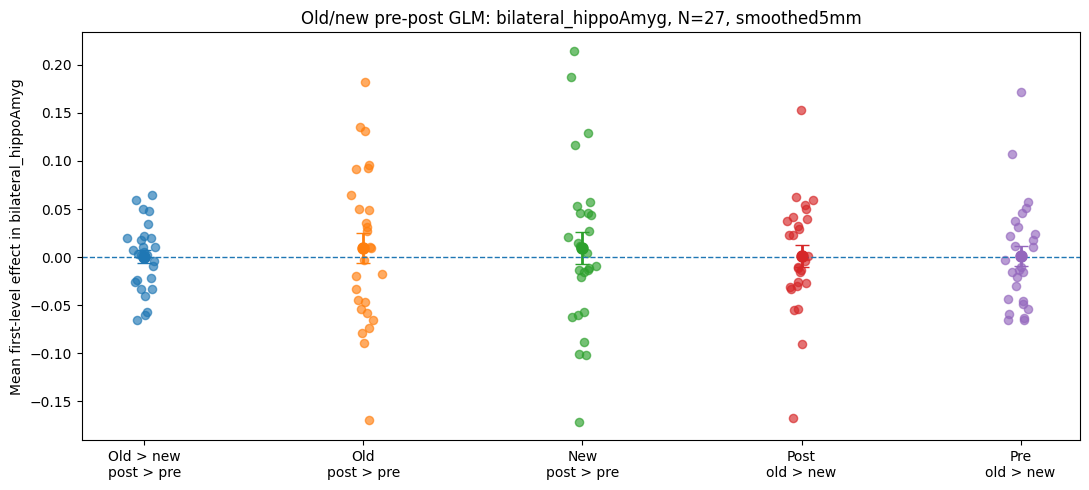

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/roi/figures/pre_post_old_new_bilateral_hippoAmyg_effects_smoothed5mm.png


In [32]:
# ============================================================
# 32. Plot subject-level ROI effects for old/new contrasts
# ============================================================

PLOT_ROI = "bilateral_hippoAmyg"

plot_contrasts = [
    "old_gt_new_post_gt_pre",
    "old_post_gt_pre",
    "new_post_gt_pre",
    "post_old_gt_new",
    "pre_old_gt_new",
]

contrast_labels_short = {
    "old_gt_new_post_gt_pre": "Old > new\npost > pre",
    "old_post_gt_pre": "Old\npost > pre",
    "new_post_gt_pre": "New\npost > pre",
    "post_old_gt_new": "Post\nold > new",
    "pre_old_gt_new": "Pre\nold > new",
}

plot_df = roi_effects.loc[
    (roi_effects["roi"] == PLOT_ROI)
    & (roi_effects["contrast"].isin(plot_contrasts))
].copy()

fig, ax = plt.subplots(figsize=(11, 5))

x_positions = np.arange(len(plot_contrasts))
rng = np.random.default_rng(42)

for i, contrast_name in enumerate(plot_contrasts):
    values = plot_df.loc[
        plot_df["contrast"] == contrast_name,
        "mean_effect",
    ].values
    
    jitter = rng.normal(loc=0, scale=0.04, size=len(values))
    
    ax.scatter(
        np.full(len(values), x_positions[i]) + jitter,
        values,
        alpha=0.65,
        s=35,
    )
    
    ax.errorbar(
        x_positions[i],
        np.mean(values),
        yerr=np.std(values, ddof=1) / np.sqrt(len(values)),
        marker="o",
        markersize=8,
        capsize=5,
        linewidth=2,
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x_positions)
ax.set_xticklabels([contrast_labels_short[c] for c in plot_contrasts])
ax.set_ylabel(f"Mean first-level effect in {PLOT_ROI}")
ax.set_title(
    f"Old/new pre-post GLM: {PLOT_ROI}, N={len(subjects)}, {SMOOTHING_LABEL}"
)

plt.tight_layout()

roi_plot_path = ROI_FIG_DIR / f"pre_post_old_new_{PLOT_ROI}_effects_{SMOOTHING_LABEL}.png"
fig.savefig(roi_plot_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", roi_plot_path)

In [33]:
# ============================================================
# 33. Exploratory sphere ROI around right anterior parahippocampal peak
# Primary contrast peak: old > new, post > pre
# ============================================================

from nilearn.maskers import NiftiSpheresMasker

SPHERE_ROI_DIR = OUT_DIR / "exploratory_sphere_roi"
SPHERE_ROI_TABLE_DIR = SPHERE_ROI_DIR / "tables"
SPHERE_ROI_FIG_DIR = SPHERE_ROI_DIR / "figures"

for path in [
    SPHERE_ROI_DIR,
    SPHERE_ROI_TABLE_DIR,
    SPHERE_ROI_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

# Peak from the primary old/new pre-post contrast,
# labelled by Harvard-Oxford as right anterior parahippocampal gyrus.
RIGHT_ANTERIOR_PHC_PEAK = (19.0, -14.5, -28.0)

# Use a small local sphere.
# 6 mm is a common exploratory local ROI radius.
SPHERE_RADIUS_MM = 6.0

print("Exploratory sphere ROI")
print("Center:", RIGHT_ANTERIOR_PHC_PEAK)
print("Radius:", SPHERE_RADIUS_MM, "mm")
print("Important caveat: this ROI is selected from the same whole-brain contrast, so it is exploratory.")

Exploratory sphere ROI
Center: (19.0, -14.5, -28.0)
Radius: 6.0 mm
Important caveat: this ROI is selected from the same whole-brain contrast, so it is exploratory.


In [35]:
# ============================================================
# 34b. Extract subject-level effects from exploratory PHC sphere ROI
# Robust to 1D / 2D NiftiSpheresMasker output
# ============================================================

sphere_masker = NiftiSpheresMasker(
    seeds=[RIGHT_ANTERIOR_PHC_PEAK],
    radius=SPHERE_RADIUS_MM,
    detrend=False,
    standardize=False,
    memory=None,
)

sphere_roi_rows = []

for subject in subjects:
    print("Extracting sphere ROI:", subject)
    
    for contrast_name in OLD_NEW_CONTRASTS.keys():
        effect_path = get_first_level_effect_map_path(subject, contrast_name)
        assert effect_path.exists(), f"Missing effect map: {effect_path}"
        
        effect_img = load_img(str(effect_path))
        
        values = sphere_masker.fit_transform(effect_img)
        values = np.asarray(values).ravel()
        values = values[np.isfinite(values)]
        
        assert len(values) > 0, (
            f"No finite values extracted for {subject}, {contrast_name}"
        )
        
        mean_effect = float(np.mean(values))
        
        sphere_roi_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "priority": CONTRAST_PRIORITY[contrast_name],
            "formula": CONTRAST_FORMULAS[contrast_name],
            "roi": "right_anterior_phc_sphere_6mm",
            "sphere_x": RIGHT_ANTERIOR_PHC_PEAK[0],
            "sphere_y": RIGHT_ANTERIOR_PHC_PEAK[1],
            "sphere_z": RIGHT_ANTERIOR_PHC_PEAK[2],
            "sphere_radius_mm": SPHERE_RADIUS_MM,
            "n_values_extracted": len(values),
            "mean_effect": mean_effect,
            "effect_map_path": str(effect_path),
        })

sphere_roi_effects = pd.DataFrame(sphere_roi_rows)

display(sphere_roi_effects.head())

print("\nExtraction summary:")
display(
    sphere_roi_effects
    .groupby("contrast")
    .agg(
        n_subjects=("subject", "nunique"),
        mean_n_values=("n_values_extracted", "mean"),
        min_n_values=("n_values_extracted", "min"),
        max_n_values=("n_values_extracted", "max"),
    )
    .reset_index()
)

sphere_roi_effects_path = (
    SPHERE_ROI_TABLE_DIR
    / f"pre_post_old_new_right_anterior_phc_sphere_subject_effects_{SMOOTHING_LABEL}.csv"
)

sphere_roi_effects.to_csv(sphere_roi_effects_path, index=False)

print("Saved:", sphere_roi_effects_path)

Extracting sphere ROI: sub-P10
Extracting sphere ROI: sub-P12
Extracting sphere ROI: sub-P13
Extracting sphere ROI: sub-P14
Extracting sphere ROI: sub-P15
Extracting sphere ROI: sub-P16
Extracting sphere ROI: sub-P17
Extracting sphere ROI: sub-P18
Extracting sphere ROI: sub-P19
Extracting sphere ROI: sub-P21
Extracting sphere ROI: sub-P22
Extracting sphere ROI: sub-P23
Extracting sphere ROI: sub-P25
Extracting sphere ROI: sub-P27
Extracting sphere ROI: sub-P31
Extracting sphere ROI: sub-P34
Extracting sphere ROI: sub-P35
Extracting sphere ROI: sub-P36
Extracting sphere ROI: sub-P41
Extracting sphere ROI: sub-P42
Extracting sphere ROI: sub-P43
Extracting sphere ROI: sub-P44
Extracting sphere ROI: sub-P45
Extracting sphere ROI: sub-P47
Extracting sphere ROI: sub-P48
Extracting sphere ROI: sub-P50
Extracting sphere ROI: sub-P51


,subject,contrast,priority,formula,roi,sphere_x,sphere_y,sphere_z,sphere_radius_mm,n_values_extracted,mean_effect,effect_map_path
0,sub-P10,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",right_anterior_phc_sphere_6mm,19.0,-14.5,-28.0,6.0,1,0.032774,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_old_gt_new_post_gt_pre_sm...
1,sub-P10,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",right_anterior_phc_sphere_6mm,19.0,-14.5,-28.0,6.0,1,0.125570,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_old_post_gt_pre_smoothed5...
2,sub-P10,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",right_anterior_phc_sphere_6mm,19.0,-14.5,-28.0,6.0,1,0.092796,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_new_post_gt_pre_smoothed5...
3,sub-P10,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",right_anterior_phc_sphere_6mm,19.0,-14.5,-28.0,6.0,1,0.093831,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_post_old_gt_new_smoothed5...
4,sub-P10,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",right_anterior_phc_sphere_6mm,19.0,-14.5,-28.0,6.0,1,0.028282,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/first_level_smoothed5mm/maps/sub-P10_pre_old_gt_new_smoothed5m...



Extraction summary:


,contrast,n_subjects,mean_n_values,min_n_values,max_n_values
0,all_post_gt_pre,27,1.0,1,1
1,new_post_gt_pre,27,1.0,1,1
2,old_gt_new_post_gt_pre,27,1.0,1,1
3,old_post_gt_pre,27,1.0,1,1
4,post_old_gt_new,27,1.0,1,1
5,pre_old_gt_new,27,1.0,1,1


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/exploratory_sphere_roi/tables/pre_post_old_new_right_anterior_phc_sphere_subject_effects_smoothed5mm.csv


In [36]:
# ============================================================
# 35. Group-level statistics for exploratory PHC sphere ROI
# ============================================================

sphere_summary_rows = []

for contrast_name, df in sphere_roi_effects.groupby("contrast"):
    values = df["mean_effect"].dropna().values
    n = len(values)
    
    mean_effect = float(np.mean(values))
    sd_effect = float(np.std(values, ddof=1))
    sem_effect = float(sd_effect / np.sqrt(n))
    
    t_stat, p_two_sided = stats.ttest_1samp(values, popmean=0.0)
    
    if t_stat >= 0:
        p_one_sided_positive = p_two_sided / 2
    else:
        p_one_sided_positive = 1 - (p_two_sided / 2)
    
    n_positive = int(np.sum(values > 0))
    
    sphere_summary_rows.append({
        "contrast": contrast_name,
        "priority": CONTRAST_PRIORITY[contrast_name],
        "formula": CONTRAST_FORMULAS[contrast_name],
        "roi": "right_anterior_phc_sphere_6mm",
        "n_subjects": n,
        "mean_effect": mean_effect,
        "sd_effect": sd_effect,
        "sem_effect": sem_effect,
        "t_stat": float(t_stat),
        "p_two_sided": float(p_two_sided),
        "p_one_sided_positive": float(p_one_sided_positive),
        "n_positive": n_positive,
        "proportion_positive": n_positive / n,
        "sphere_x": RIGHT_ANTERIOR_PHC_PEAK[0],
        "sphere_y": RIGHT_ANTERIOR_PHC_PEAK[1],
        "sphere_z": RIGHT_ANTERIOR_PHC_PEAK[2],
        "sphere_radius_mm": SPHERE_RADIUS_MM,
        "exploratory_peak_selected_from_same_contrast": True,
    })

sphere_roi_summary = pd.DataFrame(sphere_summary_rows)

sphere_roi_summary = sphere_roi_summary.sort_values(
    ["priority", "contrast"]
).reset_index(drop=True)

display(sphere_roi_summary)

sphere_roi_summary_path = (
    SPHERE_ROI_TABLE_DIR
    / f"pre_post_old_new_right_anterior_phc_sphere_group_summary_{SMOOTHING_LABEL}.csv"
)

sphere_roi_summary.to_csv(sphere_roi_summary_path, index=False)

print("Saved:", sphere_roi_summary_path)

,contrast,priority,formula,roi,n_subjects,mean_effect,sd_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,n_positive,proportion_positive,sphere_x,sphere_y,sphere_z,sphere_radius_mm,exploratory_peak_selected_from_same_contrast
0,pre_old_gt_new,baseline_pre_only,"$\beta_{\mathrm{pre,old}}-\beta_{\mathrm{pre,new}}$",right_anterior_phc_sphere_6mm,27,-0.018481,0.089835,0.017289,-1.068993,0.294898,0.852551,13,0.481481,19.0,-14.5,-28.0,6.0,True
1,new_post_gt_pre,control_new_only,"$\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}$",right_anterior_phc_sphere_6mm,27,-0.004751,0.124038,0.023871,-0.199008,0.843804,0.578098,12,0.444444,19.0,-14.5,-28.0,6.0,True
2,all_post_gt_pre,descriptive_general_post_pre,"$\frac{1}{2}(\beta_{\mathrm{post,old}}+\beta_{\mathrm{post,new}})-\frac{1}{2}(\beta_{\mathrm{pre,old}}+\beta_{\mathrm{pre,new}})$",right_anterior_phc_sphere_6mm,27,0.010506,0.126256,0.024298,0.432395,0.669020,0.334510,12,0.444444,19.0,-14.5,-28.0,6.0,True
3,post_old_gt_new,descriptive_post_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{post,new}}$",right_anterior_phc_sphere_6mm,27,0.042546,0.082111,0.015802,2.692389,0.012246,0.006123,17,0.629630,19.0,-14.5,-28.0,6.0,True
4,old_gt_new_post_gt_pre,primary,"$(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})-(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})$",right_anterior_phc_sphere_6mm,27,0.030514,0.059476,0.011446,2.665847,0.013027,0.006513,16,0.592593,19.0,-14.5,-28.0,6.0,True
5,old_post_gt_pre,secondary_old_only,"$\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}}$",right_anterior_phc_sphere_6mm,27,0.025763,0.135146,0.026009,0.990553,0.331033,0.165517,12,0.444444,19.0,-14.5,-28.0,6.0,True


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/exploratory_sphere_roi/tables/pre_post_old_new_right_anterior_phc_sphere_group_summary_smoothed5mm.csv


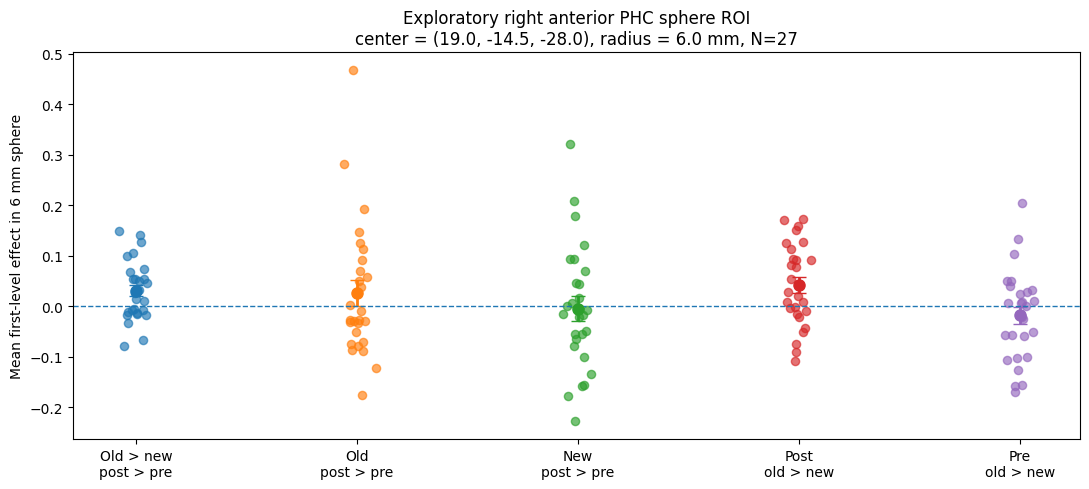

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/exploratory_sphere_roi/figures/pre_post_old_new_right_anterior_phc_sphere_effects_smoothed5mm.png


In [37]:
# ============================================================
# 36. Plot exploratory right anterior PHC sphere effects
# ============================================================

sphere_plot_contrasts = [
    "old_gt_new_post_gt_pre",
    "old_post_gt_pre",
    "new_post_gt_pre",
    "post_old_gt_new",
    "pre_old_gt_new",
]

sphere_contrast_labels_short = {
    "old_gt_new_post_gt_pre": "Old > new\npost > pre",
    "old_post_gt_pre": "Old\npost > pre",
    "new_post_gt_pre": "New\npost > pre",
    "post_old_gt_new": "Post\nold > new",
    "pre_old_gt_new": "Pre\nold > new",
}

plot_df = sphere_roi_effects.loc[
    sphere_roi_effects["contrast"].isin(sphere_plot_contrasts)
].copy()

fig, ax = plt.subplots(figsize=(11, 5))

x_positions = np.arange(len(sphere_plot_contrasts))
rng = np.random.default_rng(42)

for i, contrast_name in enumerate(sphere_plot_contrasts):
    values = plot_df.loc[
        plot_df["contrast"] == contrast_name,
        "mean_effect",
    ].values
    
    jitter = rng.normal(loc=0, scale=0.04, size=len(values))
    
    ax.scatter(
        np.full(len(values), x_positions[i]) + jitter,
        values,
        alpha=0.65,
        s=35,
    )
    
    ax.errorbar(
        x_positions[i],
        np.mean(values),
        yerr=np.std(values, ddof=1) / np.sqrt(len(values)),
        marker="o",
        markersize=8,
        capsize=5,
        linewidth=2,
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x_positions)
ax.set_xticklabels([sphere_contrast_labels_short[c] for c in sphere_plot_contrasts])
ax.set_ylabel("Mean first-level effect in 6 mm sphere")
ax.set_title(
    "Exploratory right anterior PHC sphere ROI\n"
    f"center = {RIGHT_ANTERIOR_PHC_PEAK}, radius = {SPHERE_RADIUS_MM} mm, N={len(subjects)}"
)

plt.tight_layout()

sphere_plot_path = (
    SPHERE_ROI_FIG_DIR
    / f"pre_post_old_new_right_anterior_phc_sphere_effects_{SMOOTHING_LABEL}.png"
)

fig.savefig(sphere_plot_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", sphere_plot_path)

Saved sphere image: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/exploratory_sphere_roi/right_anterior_phc_sphere_6mm_center_19.0_-14.5_-28.0.nii.gz


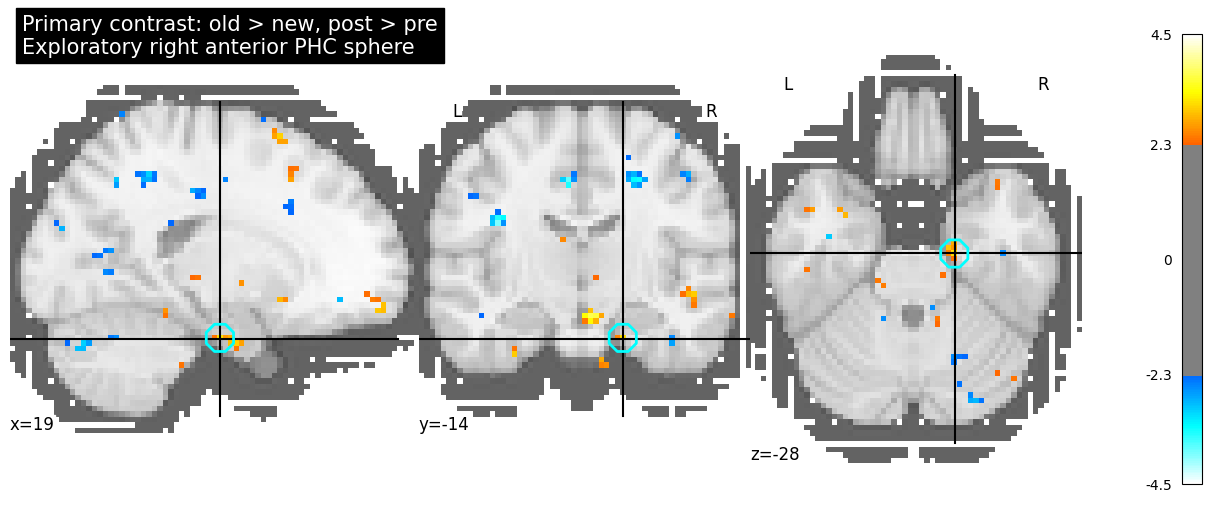

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/exploratory_sphere_roi/figures/primary_old_gt_new_post_gt_pre_right_anterior_phc_sphere_overlay_smoothed5mm.png


In [38]:
# ============================================================
# 37. Visualize exploratory PHC sphere on primary contrast map
# ============================================================

from nilearn.image import new_img_like

PRIMARY_CONTRAST = "old_gt_new_post_gt_pre"

primary_z_img = load_img(str(get_group_z_map_path(PRIMARY_CONTRAST)))

mni_template = load_mni152_template(resolution=2)

mni_template_resampled = resample_to_img(
    mni_template,
    primary_z_img,
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

# Build a binary sphere image in the primary z-map space for contour plotting.
shape = primary_z_img.shape
affine = primary_z_img.affine

ijk_center = nib.affines.apply_affine(
    np.linalg.inv(affine),
    RIGHT_ANTERIOR_PHC_PEAK,
)

voxel_coords = np.indices(shape).reshape(3, -1).T
world_coords = nib.affines.apply_affine(affine, voxel_coords)

distances = np.sqrt(
    np.sum(
        (world_coords - np.array(RIGHT_ANTERIOR_PHC_PEAK)) ** 2,
        axis=1,
    )
)

sphere_data = (distances <= SPHERE_RADIUS_MM).reshape(shape).astype(np.uint8)

sphere_img = nib.Nifti1Image(
    sphere_data,
    affine=affine,
    header=primary_z_img.header,
)

sphere_img_path = (
    SPHERE_ROI_DIR
    / f"right_anterior_phc_sphere_6mm_center_{RIGHT_ANTERIOR_PHC_PEAK[0]}_{RIGHT_ANTERIOR_PHC_PEAK[1]}_{RIGHT_ANTERIOR_PHC_PEAK[2]}.nii.gz"
)

sphere_img.to_filename(str(sphere_img_path))

print("Saved sphere image:", sphere_img_path)

fig = plt.figure(figsize=(12, 5))

display_obj = plot_stat_map(
    primary_z_img,
    bg_img=mni_template_resampled,
    display_mode="ortho",
    cut_coords=RIGHT_ANTERIOR_PHC_PEAK,
    threshold=2.33,
    vmax=4.5,
    cmap="cold_hot",
    black_bg=False,
    title=(
        "Primary contrast: old > new, post > pre\n"
        "Exploratory right anterior PHC sphere"
    ),
    figure=fig,
)

display_obj.add_contours(
    sphere_img,
    levels=[0.5],
    colors=["cyan"],
    linewidths=2.0,
)

sphere_overlay_path = (
    SPHERE_ROI_FIG_DIR
    / f"primary_old_gt_new_post_gt_pre_right_anterior_phc_sphere_overlay_{SMOOTHING_LABEL}.png"
)

fig.savefig(sphere_overlay_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", sphere_overlay_path)

In [39]:
# ============================================================
# FINAL. Save analysis status and restart manifest
# ============================================================

from datetime import datetime
import json

RESTART_DIR = OUT_DIR / "restart"
RESTART_DIR.mkdir(parents=True, exist_ok=True)

analysis_status = {
    "saved_at": datetime.now().isoformat(),
    "notebook": "kroczak_09_pre_post_old_new_viewing_glm.ipynb",
    "analysis_name": ANALYSIS_NAME,
    "project_root": str(PROJECT_ROOT),
    "out_dir": str(OUT_DIR),
    "events_dir": str(EVENTS_DIR),
    "table_dir": str(TABLE_DIR),
    "figure_dir": str(FIG_DIR),
    "roi_dir": str(ROI_DIR) if "ROI_DIR" in globals() else "",
    "sphere_roi_dir": str(SPHERE_ROI_DIR) if "SPHERE_ROI_DIR" in globals() else "",
    "n_subjects": len(subjects),
    "subjects": subjects,
    "smoothing_fwhm": SMOOTHING_FWHM,
    "smoothing_label": SMOOTHING_LABEL,
    "bold_space": BOLD_SPACE,
    "pre_session": PRE_SESSION,
    "post_session": POST_SESSION,
    "main_contrast": "old_gt_new_post_gt_pre",
    "main_contrast_formula": CONTRAST_FORMULAS["old_gt_new_post_gt_pre"],
    "contrasts": OLD_NEW_CONTRASTS,
    "contrast_priority": CONTRAST_PRIORITY,
    "key_outputs": {
        "contrast_definitions": str(TABLE_DIR / "pre_post_old_new_contrast_definitions.csv"),
        "first_level_qc": str(TABLE_DIR / f"pre_post_old_new_first_level_qc_{SMOOTHING_LABEL}.csv"),
        "first_level_contrast_qc": str(TABLE_DIR / f"pre_post_old_new_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"),
        "first_level_map_qc": str(TABLE_DIR / f"pre_post_old_new_first_level_map_qc_{SMOOTHING_LABEL}.csv"),
        "second_level_qc": str(TABLE_DIR / f"pre_post_old_new_second_level_qc_from_{SMOOTHING_LABEL}.csv"),
        "threshold_summary": str(TABLE_DIR / f"pre_post_old_new_whole_brain_threshold_summary_from_{SMOOTHING_LABEL}.csv"),
        "cluster_summary": str(TABLE_DIR / f"pre_post_old_new_cluster_summary_from_{SMOOTHING_LABEL}.csv"),
        "cluster_details": str(TABLE_DIR / f"pre_post_old_new_cluster_details_z233_z300_from_{SMOOTHING_LABEL}.csv"),
        "primary_cluster_labels": str(TABLE_DIR / f"primary_old_gt_new_post_gt_pre_cluster_atlas_labels_{SMOOTHING_LABEL}.csv"),
        "hippoAmyg_roi_summary": str(ROI_TABLE_DIR / f"pre_post_old_new_hippoAmyg_group_summary_{SMOOTHING_LABEL}.csv") if "ROI_TABLE_DIR" in globals() else "",
        "sphere_roi_summary": str(SPHERE_ROI_TABLE_DIR / f"pre_post_old_new_right_anterior_phc_sphere_group_summary_{SMOOTHING_LABEL}.csv") if "SPHERE_ROI_TABLE_DIR" in globals() else "",
    },
    "main_takeaways": {
        "whole_brain_primary": "No FDR/Bonferroni-corrected voxels; exploratory uncorrected clusters present.",
        "primary_peak_followup": "Right anterior parahippocampal gyrus peak at MNI (19, -14.5, -28).",
        "broad_hippoAmyg_roi": "Primary old/new post-pre effect null in broad bilateral hippoAmyg ROI.",
        "exploratory_sphere_roi": "6 mm sphere around right anterior PHC peak positive for primary contrast, but circular/exploratory.",
    }
}

manifest_path = RESTART_DIR / f"{ANALYSIS_NAME}_restart_manifest.json"

with open(manifest_path, "w") as f:
    json.dump(analysis_status, f, indent=4)

print("Saved restart manifest:")
print(manifest_path)

# Save compact text summary too.
summary_txt_path = RESTART_DIR / f"{ANALYSIS_NAME}_restart_summary.txt"

with open(summary_txt_path, "w") as f:
    f.write("Restart summary\n")
    f.write("================\n\n")
    f.write(f"Saved at: {analysis_status['saved_at']}\n")
    f.write(f"Notebook: {analysis_status['notebook']}\n")
    f.write(f"Analysis: {ANALYSIS_NAME}\n")
    f.write(f"N subjects: {len(subjects)}\n")
    f.write(f"Main contrast: old_gt_new_post_gt_pre\n")
    f.write(f"Formula: {CONTRAST_FORMULAS['old_gt_new_post_gt_pre']}\n\n")
    f.write("Main takeaways:\n")
    for key, value in analysis_status["main_takeaways"].items():
        f.write(f"- {key}: {value}\n")
    f.write("\nKey outputs:\n")
    for key, value in analysis_status["key_outputs"].items():
        f.write(f"- {key}: {value}\n")

print("Saved restart summary:")
print(summary_txt_path)

Saved restart manifest:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/restart/pre_post_old_new_viewing_glm_restart_manifest.json
Saved restart summary:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/restart/pre_post_old_new_viewing_glm_restart_summary.txt


In [4]:
# ============================================================
# Restart helper: paths and map getter functions
# Run this after the restart loader before any plotting/SVC cells
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn.image import load_img, resample_to_img
from nilearn.datasets import load_mni152_template
from nilearn.plotting import plot_stat_map
from scipy.stats import norm

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
DATA_DIR = PROJECT_ROOT / "data"

ANALYSIS_NAME = "pre_post_old_new_viewing_glm"
OUT_DIR = DATA_DIR / "processed" / "glm" / ANALYSIS_NAME

TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
RESTART_DIR = OUT_DIR / "restart"

SMOOTHING_LABEL = "smoothed5mm"

SECOND_LEVEL_DIR = OUT_DIR / f"second_level_from_{SMOOTHING_LABEL}"
SECOND_LEVEL_MAPS_DIR = SECOND_LEVEL_DIR / "maps"

PRIMARY_CONTRAST = "old_gt_new_post_gt_pre"

def get_group_z_map_path(contrast_name):
    return (
        SECOND_LEVEL_MAPS_DIR
        / f"group_pre_post_old_new_{contrast_name}_from_{SMOOTHING_LABEL}_zmap.nii.gz"
    )

def get_group_effect_map_path(contrast_name):
    return (
        SECOND_LEVEL_MAPS_DIR
        / f"group_pre_post_old_new_{contrast_name}_from_{SMOOTHING_LABEL}_effect.nii.gz"
    )

primary_z_path = get_group_z_map_path(PRIMARY_CONTRAST)

print("Primary z-map:")
print(primary_z_path)
print("Exists:", primary_z_path.exists())

assert primary_z_path.exists(), "Primary group z-map missing. Check paths."

Primary z-map:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/second_level_from_smoothed5mm/maps/group_pre_post_old_new_old_gt_new_post_gt_pre_from_smoothed5mm_zmap.nii.gz
Exists: True


In [5]:
# ============================================================
# Restart loader for tomorrow
# ============================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
DATA_DIR = PROJECT_ROOT / "data"

ANALYSIS_NAME = "pre_post_old_new_viewing_glm"
OUT_DIR = DATA_DIR / "processed" / "glm" / ANALYSIS_NAME
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
RESTART_DIR = OUT_DIR / "restart"

SMOOTHING_LABEL = "smoothed5mm"

manifest_path = RESTART_DIR / f"{ANALYSIS_NAME}_restart_manifest.json"

with open(manifest_path, "r") as f:
    manifest = json.load(f)

subjects = manifest["subjects"]

print("Loaded manifest:")
print(manifest_path)
print("N subjects:", len(subjects))
print("Main contrast:", manifest["main_contrast"])

threshold_summary = pd.read_csv(manifest["key_outputs"]["threshold_summary"])
cluster_details = pd.read_csv(manifest["key_outputs"]["cluster_details"])
primary_cluster_labels = pd.read_csv(manifest["key_outputs"]["primary_cluster_labels"])

print("Loaded threshold summary:", threshold_summary.shape)
print("Loaded cluster details:", cluster_details.shape)
print("Loaded primary cluster labels:", primary_cluster_labels.shape)

if manifest["key_outputs"]["hippoAmyg_roi_summary"]:
    hippoAmyg_roi_summary = pd.read_csv(manifest["key_outputs"]["hippoAmyg_roi_summary"])
    print("Loaded hippoAmyg ROI summary:", hippoAmyg_roi_summary.shape)

if manifest["key_outputs"]["sphere_roi_summary"]:
    sphere_roi_summary = pd.read_csv(manifest["key_outputs"]["sphere_roi_summary"])
    print("Loaded sphere ROI summary:", sphere_roi_summary.shape)

Loaded manifest:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/restart/pre_post_old_new_viewing_glm_restart_manifest.json
N subjects: 27
Main contrast: old_gt_new_post_gt_pre
Loaded threshold summary: (24, 11)
Loaded cluster details: (169, 12)
Loaded primary cluster labels: (17, 10)
Loaded hippoAmyg ROI summary: (18, 13)
Loaded sphere ROI summary: (6, 18)


## Current primary old/new pre-post contrast

The main old/new interaction tested whether old images showed a stronger post-pre increase than new images:

$$
C_{\mathrm{old>new,\ post>pre}}
=
(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

## Relevance-split model

The next model separates old images by later goal relevance:

$$
\beta_{\mathrm{pre,oldRel}},\quad
\beta_{\mathrm{pre,oldIrrel}},\quad
\beta_{\mathrm{pre,new}},\quad
\beta_{\mathrm{post,oldRel}},\quad
\beta_{\mathrm{post,oldIrrel}},\quad
\beta_{\mathrm{post,new}}.
$$

Relevant old-image memory effect:

$$
C_{\mathrm{rel}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

Irrelevant old-image memory effect:

$$
C_{\mathrm{irrel}}
=
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

Relevant > irrelevant interaction:

$$
C_{\mathrm{rel>irrel}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}}).
$$

## Relevance-specific old-vs-new pre-post effects

The relevance-split model separates old images according to whether they were goal-relevant or goal-irrelevant during the island task, while keeping new images as a neutral control condition.

The six task regressors are:

$$
\beta_{\mathrm{pre,oldRel}},\quad
\beta_{\mathrm{pre,oldIrrel}},\quad
\beta_{\mathrm{pre,new}},\quad
\beta_{\mathrm{post,oldRel}},\quad
\beta_{\mathrm{post,oldIrrel}},\quad
\beta_{\mathrm{post,new}}.
$$

The relevant old-image memory effect is defined as the post-pre increase for relevant old images relative to the post-pre increase for new images:

$$
C_{\mathrm{rel-vs-new}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

The irrelevant old-image memory effect is defined analogously:

$$
C_{\mathrm{irrel-vs-new}}
=
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

These two contrasts are the main relevance-specific old-vs-new effects. They answer:

$$
\text{Do relevant old images increase more than new images from pre to post?}
$$

and

$$
\text{Do irrelevant old images increase more than new images from pre to post?}
$$

To test whether the relevant old-vs-new effect is stronger than the irrelevant old-vs-new effect, we compare the two quantified effects:

$$
C_{\mathrm{rel-vs-new}} - C_{\mathrm{irrel-vs-new}}.
$$

Expanded:

$$
\left[
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})
\right]
-
\left[
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}})
\right].
$$

Because the same new-image baseline is used in both terms, the new-image component cancels algebraically:

$$
C_{\mathrm{rel-vs-new}} - C_{\mathrm{irrel-vs-new}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}}).
$$

Thus, the formal relevant > irrelevant interaction is mathematically identical to comparing the relevant old-vs-new effect against the irrelevant old-vs-new effect. The new condition remains essential because it defines the two interpretable old-vs-new effects, even though it cancels in the final difference-of-differences.

We therefore report three complementary contrasts:

1. Relevant old-vs-new pre-post effect:

$$
C_{\mathrm{rel-vs-new}}
=
(\beta_{\mathrm{post,oldRel}}-\beta_{\mathrm{pre,oldRel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

2. Irrelevant old-vs-new pre-post effect:

$$
C_{\mathrm{irrel-vs-new}}
=
(\beta_{\mathrm{post,oldIrrel}}-\beta_{\mathrm{pre,oldIrrel}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

3. Difference between the two old-vs-new effects:

$$
C_{\mathrm{rel-vs-new}>\mathrm{irrel-vs-new}}
=
C_{\mathrm{rel-vs-new}} - C_{\mathrm{irrel-vs-new}}.
$$

We performed an exploratory small-volume analysis using a 6 mm sphere centered on the right anterior parahippocampal peak identified in the primary whole-brain contrast, $$(x,y,z)=(19,-14.5,-28)$$. Within this small volume, voxelwise significance was corrected for the number of voxels in the sphere. Because the sphere center was selected from the same contrast, this analysis is interpreted as a post-hoc characterization of the peak rather than an independent confirmatory ROI test.

In [6]:
# ============================================================
# 38. Exploratory small-volume correction inside right anterior PHC sphere
# ============================================================

from scipy.stats import norm

PRIMARY_CONTRAST = "old_gt_new_post_gt_pre"

RIGHT_ANTERIOR_PHC_PEAK = (19.0, -14.5, -28.0)
SPHERE_RADIUS_MM = 6.0

SVC_DIR = OUT_DIR / "small_volume_correction"
SVC_TABLE_DIR = SVC_DIR / "tables"
SVC_FIG_DIR = SVC_DIR / "figures"
SVC_MASK_DIR = SVC_DIR / "masks"

for path in [SVC_DIR, SVC_TABLE_DIR, SVC_FIG_DIR, SVC_MASK_DIR]:
    path.mkdir(parents=True, exist_ok=True)

primary_z_img = load_img(str(get_group_z_map_path(PRIMARY_CONTRAST)))

shape = primary_z_img.shape
affine = primary_z_img.affine

# ------------------------------------------------------------
# Build 6 mm sphere in group z-map space
# ------------------------------------------------------------

voxel_coords = np.indices(shape).reshape(3, -1).T
world_coords = nib.affines.apply_affine(affine, voxel_coords)

distances = np.sqrt(
    np.sum(
        (world_coords - np.array(RIGHT_ANTERIOR_PHC_PEAK)) ** 2,
        axis=1,
    )
)

sphere_data = (distances <= SPHERE_RADIUS_MM).reshape(shape).astype(bool)

sphere_img = nib.Nifti1Image(
    sphere_data.astype(np.uint8),
    affine=affine,
    header=primary_z_img.header,
)

sphere_mask_path = (
    SVC_MASK_DIR
    / f"right_anterior_phc_sphere_{SPHERE_RADIUS_MM:.0f}mm_center_19_-14p5_-28.nii.gz"
)

sphere_img.to_filename(str(sphere_mask_path))

print("Saved sphere mask:", sphere_mask_path)
print("Sphere voxels:", int(sphere_data.sum()))

# ------------------------------------------------------------
# Extract z-values inside sphere
# ------------------------------------------------------------

z_data = primary_z_img.get_fdata()
sphere_z_values = z_data[sphere_data]
sphere_world_coords = world_coords[sphere_data.reshape(-1)]

finite_mask = np.isfinite(sphere_z_values)

sphere_z_values = sphere_z_values[finite_mask]
sphere_world_coords = sphere_world_coords[finite_mask]

n_svc_voxels = len(sphere_z_values)

assert n_svc_voxels > 0, "No finite voxels in SVC sphere."

# One-sided positive p-values
sphere_p_unc = norm.sf(sphere_z_values)

# Bonferroni within the small volume
sphere_p_bonf = np.minimum(sphere_p_unc * n_svc_voxels, 1.0)

# Benjamini-Hochberg FDR within the small volume
order = np.argsort(sphere_p_unc)
ranked_p = sphere_p_unc[order]
ranks = np.arange(1, n_svc_voxels + 1)

q_values_ranked = ranked_p * n_svc_voxels / ranks
q_values_ranked = np.minimum.accumulate(q_values_ranked[::-1])[::-1]
q_values_ranked = np.minimum(q_values_ranked, 1.0)

sphere_q_fdr = np.empty_like(q_values_ranked)
sphere_q_fdr[order] = q_values_ranked

# ------------------------------------------------------------
# Peak voxel inside sphere
# ------------------------------------------------------------

peak_idx = int(np.argmax(sphere_z_values))

svc_peak_coord = sphere_world_coords[peak_idx]
svc_peak_z = float(sphere_z_values[peak_idx])
svc_peak_p_unc = float(sphere_p_unc[peak_idx])
svc_peak_p_bonf = float(sphere_p_bonf[peak_idx])
svc_peak_q_fdr = float(sphere_q_fdr[peak_idx])

# Bonferroni z-threshold inside sphere
svc_bonf_z_threshold = float(norm.isf(0.05 / n_svc_voxels))

svc_summary = pd.DataFrame([
    {
        "contrast": PRIMARY_CONTRAST,
        "svc_type": "posthoc_peak_centered_sphere",
        "sphere_center_x": RIGHT_ANTERIOR_PHC_PEAK[0],
        "sphere_center_y": RIGHT_ANTERIOR_PHC_PEAK[1],
        "sphere_center_z": RIGHT_ANTERIOR_PHC_PEAK[2],
        "sphere_radius_mm": SPHERE_RADIUS_MM,
        "n_svc_voxels": n_svc_voxels,
        "peak_x": svc_peak_coord[0],
        "peak_y": svc_peak_coord[1],
        "peak_z_coord": svc_peak_coord[2],
        "peak_stat_z": svc_peak_z,
        "peak_p_uncorrected_one_sided": svc_peak_p_unc,
        "peak_p_bonferroni_svc_one_sided": svc_peak_p_bonf,
        "peak_q_fdr_svc_one_sided": svc_peak_q_fdr,
        "bonferroni_svc_z_threshold_p05": svc_bonf_z_threshold,
        "survives_bonferroni_svc_p05": svc_peak_p_bonf < 0.05,
        "survives_fdr_svc_q05": svc_peak_q_fdr < 0.05,
        "circular_posthoc_roi": True,
        "interpretation": (
            "Exploratory post-hoc SVC. Sphere center was selected from the same contrast."
        ),
    }
])

display(svc_summary)

svc_summary_path = (
    SVC_TABLE_DIR
    / f"svc_right_anterior_phc_sphere_{SPHERE_RADIUS_MM:.0f}mm_{PRIMARY_CONTRAST}_{SMOOTHING_LABEL}.csv"
)

svc_summary.to_csv(svc_summary_path, index=False)

print("Saved:", svc_summary_path)

Saved sphere mask: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/small_volume_correction/masks/right_anterior_phc_sphere_6mm_center_19_-14p5_-28.nii.gz
Sphere voxels: 57


,contrast,svc_type,sphere_center_x,sphere_center_y,sphere_center_z,sphere_radius_mm,n_svc_voxels,peak_x,peak_y,peak_z_coord,peak_stat_z,peak_p_uncorrected_one_sided,peak_p_bonferroni_svc_one_sided,peak_q_fdr_svc_one_sided,bonferroni_svc_z_threshold_p05,survives_bonferroni_svc_p05,survives_fdr_svc_q05,circular_posthoc_roi,interpretation
0,old_gt_new_post_gt_pre,posthoc_peak_centered_sphere,19.0,-14.5,-28.0,6.0,57,19.0,-14.5,-28.0,3.14819,0.000821,0.046821,0.034044,3.128939,True,True,True,Exploratory post-hoc SVC. Sphere center was selected from the same contrast.


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/small_volume_correction/tables/svc_right_anterior_phc_sphere_6mm_old_gt_new_post_gt_pre_smoothed5mm.csv


In [7]:
# ============================================================
# 39. Create SVC-thresholded map inside PHC sphere
# ============================================================

# Bonferroni SVC threshold map
svc_bonf_mask = (
    sphere_data
    & np.isfinite(z_data)
    & (z_data >= svc_bonf_z_threshold)
)

svc_bonf_z_data = np.where(svc_bonf_mask, z_data, 0)

svc_bonf_z_img = nib.Nifti1Image(
    svc_bonf_z_data,
    affine=primary_z_img.affine,
    header=primary_z_img.header,
)

svc_bonf_z_path = (
    SVC_DIR
    / f"svc_bonferroni_p05_right_anterior_phc_sphere_{SPHERE_RADIUS_MM:.0f}mm_{PRIMARY_CONTRAST}_{SMOOTHING_LABEL}.nii.gz"
)

svc_bonf_z_img.to_filename(str(svc_bonf_z_path))

print("Saved SVC-thresholded map:", svc_bonf_z_path)
print("SVC surviving voxels:", int(svc_bonf_mask.sum()))

Saved SVC-thresholded map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/small_volume_correction/svc_bonferroni_p05_right_anterior_phc_sphere_6mm_old_gt_new_post_gt_pre_smoothed5mm.nii.gz
SVC surviving voxels: 1


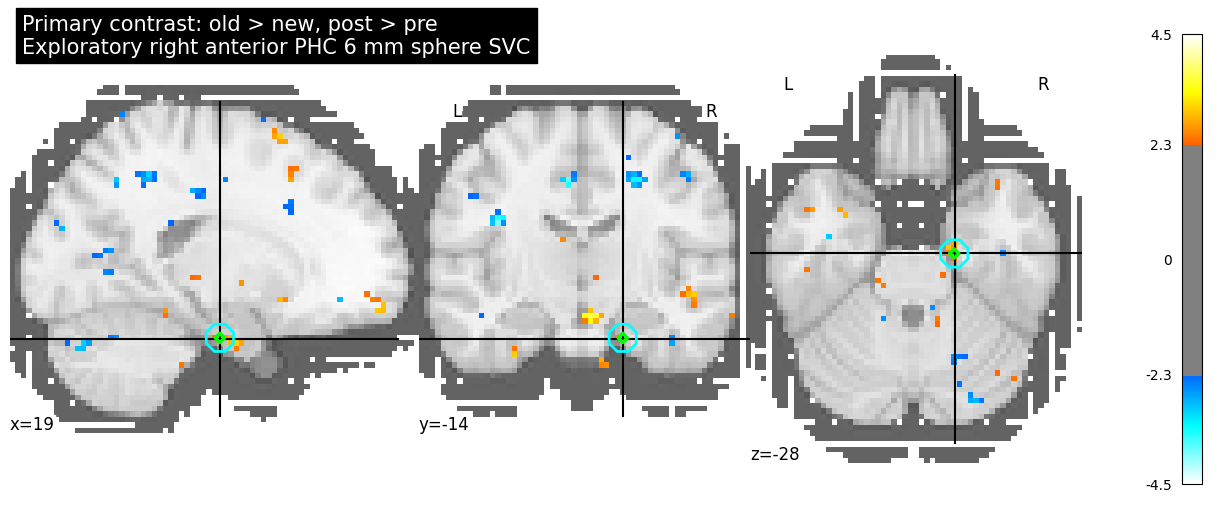

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/small_volume_correction/figures/svc_right_anterior_phc_sphere_6mm_old_gt_new_post_gt_pre_smoothed5mm.png


In [8]:
# ============================================================
# 40. Plot exploratory PHC SVC result
# ============================================================

mni_template = load_mni152_template(resolution=2)

mni_template_resampled = resample_to_img(
    mni_template,
    primary_z_img,
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

fig = plt.figure(figsize=(12, 5))

display_obj = plot_stat_map(
    primary_z_img,
    bg_img=mni_template_resampled,
    display_mode="ortho",
    cut_coords=RIGHT_ANTERIOR_PHC_PEAK,
    threshold=2.33,
    vmax=4.5,
    cmap="cold_hot",
    black_bg=False,
    title=(
        "Primary contrast: old > new, post > pre\n"
        "Exploratory right anterior PHC 6 mm sphere SVC"
    ),
    figure=fig,
)

display_obj.add_contours(
    sphere_img,
    levels=[0.5],
    colors=["cyan"],
    linewidths=2.0,
)

# If there are SVC-surviving voxels, overlay their contour too.
if int(svc_bonf_mask.sum()) > 0:
    display_obj.add_contours(
        svc_bonf_z_img,
        levels=[0.5],
        colors=["lime"],
        linewidths=2.5,
    )

svc_fig_path = (
    SVC_FIG_DIR
    / f"svc_right_anterior_phc_sphere_{SPHERE_RADIUS_MM:.0f}mm_{PRIMARY_CONTRAST}_{SMOOTHING_LABEL}.png"
)

fig.savefig(svc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", svc_fig_path)

### Exploratory small-volume correction around the right anterior parahippocampal peak

The primary old/new pre-post contrast was defined as:

$$
C_{\mathrm{old>new,\ post>pre}}
=
(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

A local exploratory small-volume correction was performed around the right anterior parahippocampal peak identified in the primary whole-brain contrast:

$$
(x,y,z)=(19.0,\ -14.5,\ -28.0).
$$

A spherical small volume of radius:

$$
r=6\ \mathrm{mm}
$$

was created around this coordinate. The sphere contained:

$$
N_{\mathrm{voxels}}=57
$$

voxels.

Within this small volume, the peak voxel was located at the same coordinate:

$$
(x,y,z)=(19.0,\ -14.5,\ -28.0),
$$

with:

$$
z=3.15.
$$

The uncorrected one-sided voxelwise p-value was:

$$
p_{\mathrm{uncorrected}}=0.000821.
$$

After Bonferroni correction across the 57 voxels inside the sphere, the corrected p-value was:

$$
p_{\mathrm{SVC,Bonferroni}}=0.0468.
$$

The FDR-corrected q-value within the sphere was:

$$
q_{\mathrm{SVC,FDR}}=0.0340.
$$

Thus, the local peak survived small-volume correction within the exploratory 6 mm sphere:

$$
p_{\mathrm{SVC,Bonferroni}}<.05.
$$

This suggests that the right anterior parahippocampal peak is a locally robust component of the exploratory whole-brain old/new pre-post effect. However, because the sphere was centered on a peak selected from the same contrast, this analysis is post-hoc and should be interpreted as exploratory rather than as an independent confirmatory ROI test.

**Exploratory right anterior PHC follow-up**

The primary old/new pre-post contrast showed an exploratory peak in right anterior parahippocampal gyrus:

$$
(x,y,z)=(19.0,\ -14.5,\ -28.0),\quad z=3.15.
$$

A 6 mm small-volume sphere around this peak contained 57 voxels. The peak survived correction within this small volume:

$$
p_{\mathrm{SVC,Bonferroni}}=.047,\quad q_{\mathrm{SVC,FDR}}=.034.
$$

This suggests a localized right anterior parahippocampal contribution to the old-specific post-pre increase. Because the sphere was defined from the same contrast, this result is exploratory and post-hoc.

In [9]:
# ============================================================
# 41. Check whether right anterior PHC peak/sphere overlaps
# the provided subject-specific hippoAmyg_02022024 masks
# ============================================================

from nilearn.image import resample_to_img, mean_img, math_img

SUPERVISOR_MASK_ROOT = DATA_DIR / "rois" / "hippoAmyg_02022024"

RIGHT_ANTERIOR_PHC_PEAK = (19.0, -14.5, -28.0)
SPHERE_RADIUS_MM = 6.0

primary_z_img = load_img(str(get_group_z_map_path("old_gt_new_post_gt_pre")))

print("Mask root:", SUPERVISOR_MASK_ROOT)
print("Exists:", SUPERVISOR_MASK_ROOT.exists())
assert SUPERVISOR_MASK_ROOT.exists()


def find_supervisor_hippoamyg_mask(subject, hemi):
    """
    Flexible search for subject-specific hippoAmyg masks.
    hemi: 'L' or 'R'
    """
    subject_root = SUPERVISOR_MASK_ROOT / subject
    
    patterns = [
        f"**/*hemi-{hemi}*hippoAmyg*.nii.gz",
        f"**/*hemi-{hemi}*hippoamyg*.nii.gz",
        f"**/*{hemi}*hippoAmyg*.nii.gz",
        f"**/*{hemi}*hippoamyg*.nii.gz",
    ]
    
    matches = []
    
    for pattern in patterns:
        matches.extend(sorted(subject_root.glob(pattern)))
    
    unique_matches = []
    seen = set()
    
    for path in matches:
        if path not in seen:
            unique_matches.append(path)
            seen.add(path)
    
    if len(unique_matches) == 0:
        return None
    
    return unique_matches[0]


def make_binary_resampled_mask(mask_path, reference_img):
    mask_img = nib.load(str(mask_path))
    mask_data = mask_img.get_fdata()
    
    binary_mask_img = nib.Nifti1Image(
        (mask_data > 0).astype(np.uint8),
        affine=mask_img.affine,
        header=mask_img.header,
    )
    
    resampled_mask = resample_to_img(
        binary_mask_img,
        reference_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    resampled_data = resampled_mask.get_fdata() > 0
    
    return nib.Nifti1Image(
        resampled_data.astype(np.uint8),
        affine=reference_img.affine,
        header=reference_img.header,
    )


# ------------------------------------------------------------
# Build the same 6 mm PHC sphere in group-map space
# ------------------------------------------------------------

shape = primary_z_img.shape
affine = primary_z_img.affine

voxel_coords = np.indices(shape).reshape(3, -1).T
world_coords = nib.affines.apply_affine(affine, voxel_coords)

distances = np.sqrt(
    np.sum(
        (world_coords - np.array(RIGHT_ANTERIOR_PHC_PEAK)) ** 2,
        axis=1,
    )
)

sphere_data = (distances <= SPHERE_RADIUS_MM).reshape(shape).astype(bool)

sphere_img = nib.Nifti1Image(
    sphere_data.astype(np.uint8),
    affine=affine,
    header=primary_z_img.header,
)

print("Sphere voxels:", int(sphere_data.sum()))


# ------------------------------------------------------------
# Check peak voxel and sphere overlap for each subject
# ------------------------------------------------------------

peak_ijk = nib.affines.apply_affine(
    np.linalg.inv(primary_z_img.affine),
    RIGHT_ANTERIOR_PHC_PEAK,
)

peak_ijk = tuple(np.round(peak_ijk).astype(int))

print("Peak MNI:", RIGHT_ANTERIOR_PHC_PEAK)
print("Peak voxel index:", peak_ijk)

overlap_rows = []
right_masks = []
left_masks = []
bilateral_masks = []

for subject in subjects:
    left_path = find_supervisor_hippoamyg_mask(subject, "L")
    right_path = find_supervisor_hippoamyg_mask(subject, "R")
    
    assert left_path is not None, f"Missing left mask for {subject}"
    assert right_path is not None, f"Missing right mask for {subject}"
    
    left_mask = make_binary_resampled_mask(left_path, primary_z_img)
    right_mask = make_binary_resampled_mask(right_path, primary_z_img)
    
    left_data = left_mask.get_fdata() > 0
    right_data = right_mask.get_fdata() > 0
    bilateral_data = left_data | right_data
    
    left_masks.append(left_mask)
    right_masks.append(right_mask)
    
    bilateral_mask = nib.Nifti1Image(
        bilateral_data.astype(np.uint8),
        affine=primary_z_img.affine,
        header=primary_z_img.header,
    )
    bilateral_masks.append(bilateral_mask)
    
    # Is exact peak voxel inside subject mask?
    px, py, pz = peak_ijk
    
    peak_inside_left = bool(left_data[px, py, pz])
    peak_inside_right = bool(right_data[px, py, pz])
    peak_inside_bilateral = bool(bilateral_data[px, py, pz])
    
    # Sphere overlap with masks
    n_sphere_voxels = int(sphere_data.sum())
    
    n_overlap_left = int(np.sum(sphere_data & left_data))
    n_overlap_right = int(np.sum(sphere_data & right_data))
    n_overlap_bilateral = int(np.sum(sphere_data & bilateral_data))
    
    overlap_rows.append({
        "subject": subject,
        "peak_inside_left_hippoAmyg": peak_inside_left,
        "peak_inside_right_hippoAmyg": peak_inside_right,
        "peak_inside_bilateral_hippoAmyg": peak_inside_bilateral,
        "n_sphere_voxels": n_sphere_voxels,
        "n_overlap_left": n_overlap_left,
        "n_overlap_right": n_overlap_right,
        "n_overlap_bilateral": n_overlap_bilateral,
        "percent_sphere_overlap_left": 100 * n_overlap_left / n_sphere_voxels,
        "percent_sphere_overlap_right": 100 * n_overlap_right / n_sphere_voxels,
        "percent_sphere_overlap_bilateral": 100 * n_overlap_bilateral / n_sphere_voxels,
        "left_mask_path": str(left_path),
        "right_mask_path": str(right_path),
    })

peak_mask_overlap = pd.DataFrame(overlap_rows)

display(peak_mask_overlap)

print("\nPeak inside mask summary:")
display(
    peak_mask_overlap[
        [
            "peak_inside_left_hippoAmyg",
            "peak_inside_right_hippoAmyg",
            "peak_inside_bilateral_hippoAmyg",
        ]
    ].mean().reset_index(name="proportion_subjects")
)

print("\nSphere overlap summary:")
display(
    peak_mask_overlap[
        [
            "n_overlap_left",
            "n_overlap_right",
            "n_overlap_bilateral",
            "percent_sphere_overlap_left",
            "percent_sphere_overlap_right",
            "percent_sphere_overlap_bilateral",
        ]
    ].describe()
)

overlap_path = (
    SVC_TABLE_DIR
    / f"right_anterior_phc_peak_overlap_with_subject_hippoAmyg_masks_{SMOOTHING_LABEL}.csv"
)

peak_mask_overlap.to_csv(overlap_path, index=False)

print("Saved:", overlap_path)

Mask root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024
Exists: True
Sphere voxels: 57
Peak MNI: (19.0, -14.5, -28.0)
Peak voxel index: (np.int64(38), np.int64(39), np.int64(19))


,subject,peak_inside_left_hippoAmyg,peak_inside_right_hippoAmyg,peak_inside_bilateral_hippoAmyg,n_sphere_voxels,n_overlap_left,n_overlap_right,n_overlap_bilateral,percent_sphere_overlap_left,percent_sphere_overlap_right,percent_sphere_overlap_bilateral,left_mask_path,right_mask_path
0,sub-P10,False,False,False,57,0,10,10,0.0,17.543860,17.543860,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...
1,sub-P12,False,False,False,57,0,16,16,0.0,28.070175,28.070175,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P12/ses-01/anat/sub-P12_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P12/ses-01/anat/sub-P12_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...
2,sub-P13,False,False,False,57,0,8,8,0.0,14.035088,14.035088,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P13/ses-01/anat/sub-P13_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P13/ses-01/anat/sub-P13_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...
3,sub-P14,False,False,False,57,0,11,11,0.0,19.298246,19.298246,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P14/ses-01/anat/sub-P14_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P14/ses-01/anat/sub-P14_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...
4,sub-P15,False,False,False,57,0,14,14,0.0,24.561404,24.561404,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P15/ses-01/anat/sub-P15_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P15/ses-01/anat/sub-P15_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...
5,sub-P16,False,False,False,57,0,11,11,0.0,19.298246,19.298246,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P16/ses-01/anat/sub-P16_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P16/ses-01/anat/sub-P16_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...
6,sub-P17,False,False,False,57,0,14,14,0.0,24.561404,24.561404,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P17/ses-01/anat/sub-P17_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P17/ses-01/anat/sub-P17_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...
7,sub-P18,False,False,False,57,0,12,12,0.0,21.052632,21.052632,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P18/ses-01/anat/sub-P18_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P18/ses-01/anat/sub-P18_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAm...
8,sub-P19,False,False,False,57,0,11,11,0.0,19.298246,19.298246,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P19/ses-01/anat/sub-P19_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022


Peak inside mask summary:


,index,proportion_subjects
0,peak_inside_left_hippoAmyg,0.0
1,peak_inside_right_hippoAmyg,0.0
2,peak_inside_bilateral_hippoAmyg,0.0



Sphere overlap summary:


,n_overlap_left,n_overlap_right,n_overlap_bilateral,percent_sphere_overlap_left,percent_sphere_overlap_right,percent_sphere_overlap_bilateral
count,27.0,27.000000,27.000000,27.0,27.000000,27.000000
mean,0.0,11.407407,11.407407,0.0,20.012995,20.012995
std,0.0,2.500142,2.500142,0.0,4.386215,4.386215
min,0.0,7.000000,7.000000,0.0,12.280702,12.280702
25%,0.0,10.000000,10.000000,0.0,17.543860,17.543860
50%,0.0,11.000000,11.000000,0.0,19.298246,19.298246
75%,0.0,13.500000,13.500000,0.0,23.684211,23.684211
max,0.0,16.000000,16.000000,0.0,28.070175,28.070175


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/small_volume_correction/tables/right_anterior_phc_peak_overlap_with_subject_hippoAmyg_masks_smoothed5mm.csv


Saved group ROI: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/small_volume_correction/masks/group_bilateral_hippoAmyg_probability_threshold_0.25_smoothed5mm.nii.gz
Peak inside group hippoAmyg ROI: False
Sphere voxels: 57
Sphere/group ROI overlap voxels: 14
Sphere/group ROI overlap percent: 24.56140350877193


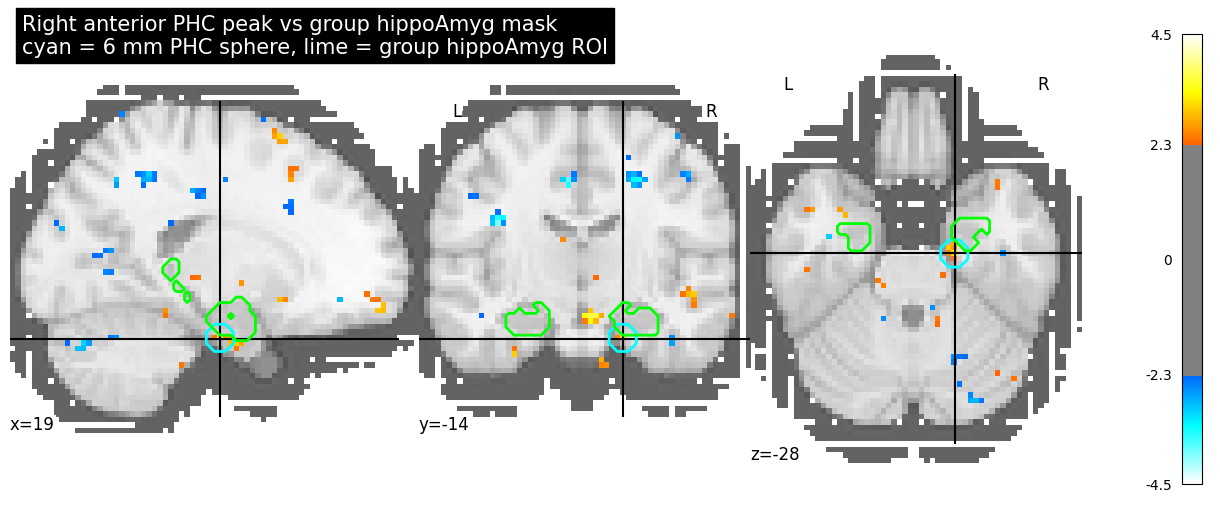

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_old_new_viewing_glm/small_volume_correction/figures/right_anterior_phc_sphere_overlap_group_hippoAmyg_smoothed5mm.png


In [10]:
# ============================================================
# 42. Group-probability hippoAmyg mask and PHC sphere overlap plot
# ============================================================

left_prob_img = mean_img(left_masks)
right_prob_img = mean_img(right_masks)
bilateral_prob_img = mean_img(bilateral_masks)

ROI_PROB_THRESHOLD = 0.25

bilateral_group_roi = math_img(
    f"img > {ROI_PROB_THRESHOLD}",
    img=bilateral_prob_img,
)

bilateral_group_roi_path = (
    SVC_MASK_DIR
    / f"group_bilateral_hippoAmyg_probability_threshold_{ROI_PROB_THRESHOLD}_{SMOOTHING_LABEL}.nii.gz"
)

bilateral_group_roi.to_filename(str(bilateral_group_roi_path))

print("Saved group ROI:", bilateral_group_roi_path)

# Check exact peak and sphere overlap with group ROI
group_roi_data = bilateral_group_roi.get_fdata() > 0

px, py, pz = peak_ijk

peak_inside_group_roi = bool(group_roi_data[px, py, pz])
n_sphere_group_overlap = int(np.sum(sphere_data & group_roi_data))
percent_sphere_group_overlap = 100 * n_sphere_group_overlap / int(sphere_data.sum())

print("Peak inside group hippoAmyg ROI:", peak_inside_group_roi)
print("Sphere voxels:", int(sphere_data.sum()))
print("Sphere/group ROI overlap voxels:", n_sphere_group_overlap)
print("Sphere/group ROI overlap percent:", percent_sphere_group_overlap)

# Plot
mni_template = load_mni152_template(resolution=2)

mni_template_resampled = resample_to_img(
    mni_template,
    primary_z_img,
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

fig = plt.figure(figsize=(12, 5))

display_obj = plot_stat_map(
    primary_z_img,
    bg_img=mni_template_resampled,
    display_mode="ortho",
    cut_coords=RIGHT_ANTERIOR_PHC_PEAK,
    threshold=2.33,
    vmax=4.5,
    cmap="cold_hot",
    black_bg=False,
    title=(
        "Right anterior PHC peak vs group hippoAmyg mask\n"
        "cyan = 6 mm PHC sphere, lime = group hippoAmyg ROI"
    ),
    figure=fig,
)

display_obj.add_contours(
    sphere_img,
    levels=[0.5],
    colors=["cyan"],
    linewidths=2.0,
)

display_obj.add_contours(
    bilateral_group_roi,
    levels=[0.5],
    colors=["lime"],
    linewidths=2.0,
)

overlap_fig_path = (
    SVC_FIG_DIR
    / f"right_anterior_phc_sphere_overlap_group_hippoAmyg_{SMOOTHING_LABEL}.png"
)

fig.savefig(overlap_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", overlap_fig_path)

### Relationship between the right anterior PHC peak and the provided hippoAmyg masks

The exploratory right anterior parahippocampal peak from the primary contrast was located at:

$$
(x,y,z)=(19.0,\ -14.5,\ -28.0).
$$

The primary contrast was:

$$
C_{\mathrm{old>new,\ post>pre}}
=
(\beta_{\mathrm{post,old}}-\beta_{\mathrm{pre,old}})
-
(\beta_{\mathrm{post,new}}-\beta_{\mathrm{pre,new}}).
$$

We checked whether this coordinate fell inside the provided subject-specific `hippoAmyg_02022024` masks. The exact peak voxel was not inside the left, right, or bilateral hippoAmyg mask for any subject:

$$
0/27
$$

subjects contained the peak voxel inside the bilateral hippoAmyg mask.

We then checked the overlap between the 6 mm sphere around the PHC peak and the subject-specific hippoAmyg masks. The sphere contained:

$$
N_{\mathrm{sphere}}=57
$$

voxels. On average, the sphere overlapped the right hippoAmyg mask by:

$$
11.4/57
$$

voxels, corresponding to approximately:

$$
20.0\%
$$

of the sphere volume. At the group-mask level, the 6 mm sphere overlapped the bilateral hippoAmyg ROI by:

$$
14/57 = 24.6\%
$$

of its voxels, but the peak coordinate itself remained outside the group hippoAmyg mask.

Thus, the right anterior parahippocampal peak is adjacent to, but not centered within, the provided hippoAmyg ROI. This explains why the broad hippoAmyg ROI analysis was null, while the local right anterior PHC sphere showed an exploratory effect.